In [1]:
# bootstrap: raiz do projeto
import os, pathlib
_r = pathlib.Path.cwd()
while not (_r / 'CLAUDE.md').exists() and _r != _r.parent:
    _r = _r.parent
os.chdir(_r)

# Experimento - SARIMAX (valor e quantidade)

Modelo de **series temporais classico** (SARIMA / SARIMAX) aplicado as series diarias de
**valor** e **quantidade** de propostas (etapa 16), usando **todo o historico disponivel**.

Cada area (Valor / Quantidade) traz:
1. **Analises classicas**: serie + medias moveis, decomposicao STL, testes de estacionariedade
   (ADF / KPSS), ACF / PACF (nivel e diferencas).
2. **Selecao de ordem** via `pmdarima.auto_arima` (sazonalidade semanal `m=5` dias uteis).
3. **Ajuste SARIMAX** + diagnostico de residuos (Ljung-Box, QQ, ACF dos residuos).
4. **Avaliacao walk-forward 1-passo** sobre o periodo do backup (mesmo recorte da Pipeline
   Antiga) e **replicacao da Secao 5.D**: `comparar_modelo(...)` com todos os graficos e o
   print comparativo contra a Pipeline Antiga.

Sao avaliados **dois modelos por area** -- `SARIMA` (univariado) e `SARIMAX` (com 1 exogena
do dia anterior) -- cada um em versao **crua** e **corrigida** (mesma correcao de vies
walk-forward, janela 10d, dos notebooks `_vies`).

> Dias uteis: exclui **domingos, sabados e feriados** (seg-sex), para uma sazonalidade
> semanal regular (`m=5`). Feriados via `workadays`.

## Introdução

In [2]:
import warnings, hashlib, pickle, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import clickhouse_connect
from workadays import workdays as wd

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import pmdarima as pm

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
try:
    from scipy.stats import gaussian_kde as _gaussian_kde
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False
print('Imports OK | statsmodels', sm.__version__)

Imports OK | statsmodels 0.14.5


## 1 - Configuracao, carga e preparacao dos dados

In [3]:
# ==================== CONFIGURACAO ====================
HOST = '10.101.150.150'; PORT = 8123
USER = 'debora_jesus';  PASS = '3fDsSF1$pe1yDv'

M           = 5     # sazonalidade semanal (dias uteis seg-sex)
MIN_TREINO  = max(2 * M + 10, 25)   # minimo de dias antes de iniciar o walk-forward
NOME_ANTIGO = 'Pipeline Antiga em Producao'
HIST_DIAS   = 540   # "todo o historico": janela ampla (o DB limita o que existir)

os.makedirs('cache', exist_ok=True)

# Garante cobrir todo o periodo dos backups tambem
_mins = []
for _bp, _c in [('resultados/backup_valor.xlsx', 'Dia Referência'),
                ('resultados/backup_qtd.xlsx',   'Data previsao')]:
    try:
        _b = pd.read_excel(_bp); _d = pd.to_datetime(_b[_c], errors='coerce').dropna()
        if len(_d): _mins.append(_d.min())
    except Exception as _e:
        print('aviso ao ler backup', _bp, '->', _e)
if _mins:
    HIST_DIAS = max(HIST_DIAS, (datetime.today() - min(_mins)).days + 90)
print(f'HIST_DIAS={HIST_DIAS} | M={M} | MIN_TREINO={MIN_TREINO}')

# ==================== DIAS ESPECIAIS (somente flag, NAO remove da base) ====================
def _bdays_from(_start, _n):
    """Primeiros _n dias UTEIS (seg-sex, exclui feriado BR) a partir de _start (inclusive)."""
    _out, _d = [], pd.Timestamp(_start).normalize()
    while len(_out) < _n:
        if _d.weekday() < 5 and not wd.is_holiday(_d.date(), country='BR'):
            _out.append(_d)
        _d += pd.Timedelta(days=1)
    return _out

LOG_ERRO_PATH = r'logs\Log_Erro.xlsx'
_mapa_erro = {}   # dia (Timestamp normalizado) -> sistema(s) em erro (dias de impacto, em dias UTEIS)
try:
    _log_erro = pd.read_excel(LOG_ERRO_PATH)
    _log_erro['Data'] = pd.to_datetime(_log_erro['Data'], errors='coerce').dt.normalize()
    _log_erro['Impacto/dias'] = pd.to_numeric(_log_erro['Impacto/dias'], errors='coerce').fillna(1).astype(int)
    for _, _r in _log_erro.dropna(subset=['Data']).iterrows():
        _nome = str(_r['Sistema Erro']).strip()
        for _d in _bdays_from(_r['Data'], max(int(_r['Impacto/dias']), 1)):
            _mapa_erro[_d] = _nome if _d not in _mapa_erro else f'{_mapa_erro[_d]} + {_nome}'
    print(f'Log_Erro: {len(_log_erro)} eventos | dias de impacto (uteis): {len(_mapa_erro)}')
except Exception as _e:
    print(f'[Log_Erro indisponivel] {_e}')
DIAS_ERRO = set(_mapa_erro)

def sistema_erro(d):
    if d is None or pd.isna(d):
        return 'Sem Erro'
    return _mapa_erro.get(pd.Timestamp(d).normalize(), 'Sem Erro')

def eh_vespera_feriado(d):
    """True se o proximo dia UTIL apos d for feriado (d = vespera de feriado)."""
    _d = pd.Timestamp(d).normalize() + pd.Timedelta(days=1)
    while _d.weekday() >= 5:          # pula sabado/domingo
        _d += pd.Timedelta(days=1)
    return bool(wd.is_holiday(_d.date(), country='BR'))


def _bday_anterior(d):
    """Dia UTIL (seg-sex, exclui feriado BR) imediatamente ANTERIOR a d."""
    _d = pd.Timestamp(d).normalize() - pd.Timedelta(days=1)
    while _d.weekday() >= 5 or wd.is_holiday(_d.date(), country='BR'):
        _d -= pd.Timedelta(days=1)
    return _d.normalize()


# ---- Vespera de Carnaval + escopo de vespera "relevante" (alinhado aos _vies) ----
# Removemos das metricas/series (e modelamos como intervencao) apenas as vesperas de
# Natal (24/dez), Ano Novo (31/dez) e Carnaval -- NAO toda vespera de feriado.
def _pascoa(_ano):
    a = _ano % 19; b = _ano // 100; c = _ano % 100; d = b // 4; e = b % 4
    f = (b + 8) // 25; g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30; i = c // 4; k = c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7; m = (a + 11 * h + 22 * l) // 451
    _mes = (h + l - 7 * m + 114) // 31; _dia = ((h + l - 7 * m + 114) % 31) + 1
    return pd.Timestamp(_ano, _mes, _dia)

def _vespera_carnaval(_ano):
    """Ultimo dia UTIL antes da segunda-feira de Carnaval (Pascoa - 48 dias)."""
    _d = _pascoa(_ano) - pd.Timedelta(days=48) - pd.Timedelta(days=1)
    while _d.weekday() >= 5 or wd.is_holiday(_d.date(), country='BR'):
        _d -= pd.Timedelta(days=1)
    return _d.normalize()

DIAS_VESPERA_CARNAVAL = {_vespera_carnaval(_y) for _y in range(2020, 2036)}

def _tipo_vespera(d):
    """'natal'/'ano_novo'/'carnaval' se d for vespera relevante (mesmo escopo dos _vies);
    None senao. Substitui o antigo booleano unico -- os 3 tipos tem magnitude/sinal bem
    diferentes (ex.: Ano Novo cai ~2x mais que Natal), por isso passam a ter dummy proprio
    em vez de 1 unico coeficiente pooled."""
    _dn = pd.Timestamp(d).normalize()
    if _dn.month == 12 and _dn.day == 24:
        return 'natal'
    if _dn.month == 12 and _dn.day == 31:
        return 'ano_novo'
    if _dn in DIAS_VESPERA_CARNAVAL:
        return 'carnaval'
    return None


def _eh_vespera_relevante(d):
    """Vespera de Natal (24/dez), Ano Novo (31/dez) ou Carnaval -- mesmo criterio dos _vies."""
    return _tipo_vespera(d) is not None


def eh_dia_atipico(d):
    """True se d e dia de Log_Erro OU vespera relevante (Natal/Ano Novo/Carnaval)."""
    _dn = pd.Timestamp(d).normalize()
    return bool(_dn in DIAS_ERRO or _eh_vespera_relevante(_dn))

def mask_atipicos(index):
    """Mascara booleana (Log_Erro + vespera 24/31/Carnaval) para um DatetimeIndex/serie de datas."""
    _idx = pd.DatetimeIndex(pd.to_datetime(index)).normalize()
    return pd.Series([(_d in DIAS_ERRO) or _eh_vespera_relevante(_d) for _d in _idx], index=_idx)


def matriz_dummies_atipicos(index):
    """Matriz de dummies 0/1 p/ ajuste tipo outlier aditivo -- 1 COLUNA POR CATEGORIA
    (log_erro, vespera_natal, vespera_ano_novo, vespera_carnaval, pre_vespera_natal,
    pre_vespera_ano_novo, pre_vespera_carnaval) em vez do antigo dummy unico pooled.
    Necessario porque as categorias tem magnitude/sinal bem diferentes (ex.: Ano Novo cai
    ~2x mais que Natal; o dia UTIL anterior a vespera pode ter efeito de sinal OPOSTO --
    rush pre-feriado, ex.: 23/dez sobe enquanto 24/dez cai); 1 coeficiente medio unico
    sub/sobre-corrige cada categoria. So inclui colunas com >=1 dia dentro de `index`
    (evita coluna de zeros / matriz singular)."""
    _idx = pd.DatetimeIndex(pd.to_datetime(index)).normalize()
    _idx_set = set(_idx)
    cols = {'log_erro': [(_d in DIAS_ERRO) for _d in _idx]}
    for _tipo in ('natal', 'ano_novo', 'carnaval'):
        _ves = set(d for d in _idx if _tipo_vespera(d) == _tipo)
        cols[f'vespera_{_tipo}'] = [(_d in _ves) for _d in _idx]
        _pre = {_bday_anterior(d) for d in _ves} & _idx_set
        cols[f'pre_vespera_{_tipo}'] = [(_d in _pre) for _d in _idx]
    df = pd.DataFrame(cols, index=_idx).astype(float)
    return df.loc[:, df.sum() > 0]


# ==================== CACHE DE FUNCOES CARAS (analise_intervencao / avaliar_area) ====================
# Resultado salvo em cache/<nome>_<hash>.pkl. A chave inclui um hash do CODIGO-FONTE das
# funcoes (auto-invalida ao editar) + fingerprint dos dados/parametros. Desligue com
# USAR_CACHE_FUNCS = False, ou apague os .pkl, para forcar recalculo.
USAR_CACHE_FUNCS = True

def _fn_src_hash(fn):
    try:
        import inspect
        return hashlib.md5(inspect.getsource(fn).encode('utf-8')).hexdigest()[:10]
    except Exception:
        return 'nosrc'

def _hash_obj(*parts):
    h = hashlib.md5()
    for p in parts:
        if isinstance(p, (pd.Series, pd.DataFrame)):
            try:
                h.update(pd.util.hash_pandas_object(p, index=True).values.tobytes())
            except Exception:
                h.update(repr(p).encode('utf-8'))
            h.update(repr(list(getattr(p, 'columns', [getattr(p, 'name', '')]))).encode('utf-8'))
        elif p is None:
            h.update(b'__none__')
        else:
            h.update(repr(p).encode('utf-8'))
    return h.hexdigest()[:16]

def _cache_call(nome, key, producer):
    """Le/grava cache/<nome>_<key>.pkl. Se USAR_CACHE_FUNCS=False, sempre recalcula."""
    if not globals().get('USAR_CACHE_FUNCS', True):
        return producer()
    _path = os.path.join('cache', f'{nome}_{key}.pkl')
    if os.path.exists(_path):
        try:
            with open(_path, 'rb') as _f:
                _out = pickle.load(_f)
            print(f'[cache hit] {nome} <- {os.path.basename(_path)}')
            return _out
        except Exception as _e:
            print(f'[cache invalido] {nome}: {_e}')
    _out = producer()
    try:
        with open(_path, 'wb') as _f:
            pickle.dump(_out, _f)
        print(f'[cache saved] {nome} -> {os.path.basename(_path)}')
    except Exception as _e:
        print(f'[cache erro] {nome}: {_e}')
    return _out


HIST_DIAS=607 | M=5 | MIN_TREINO=25
Log_Erro: 17 eventos | dias de impacto (uteis): 31


In [4]:
# ==================== DADOS (cache 1x/dia; se o ClickHouse estiver
# inacessivel -- ex.: de casa sem VPN -- reaproveita o cache existente mais
# recente em vez de travar) ====================
import sys
sys.path.insert(0, 'scripts')
from cache_utils import carregar_com_cache

query = f"""
SELECT
    toStartOfFifteenMinutes(ultimaalteracao) AS Intervalo,
    SUM(valor) AS valor,
    COUNT(propostaid) AS qntd
FROM crefaz.ft_proposta fp
WHERE
    propostaetapaid = 16
    AND propostadecisaoid IS NULL
    AND toDate(ultimaalteracao) BETWEEN toDate(today() - INTERVAL {HIST_DIAS} DAY) AND toDate(today() - INTERVAL 1 DAY)
GROUP BY Intervalo
"""

query_fila = f"""
WITH cte_total AS (
    SELECT
        prop.propostaid,
        argMax(prop.propostaetapaid, prop.data) AS etapa,
        MAX(toDate(prop.data)) AS Data
    FROM crefazon15m.dbo_propostastatushistorico AS prop
    WHERE prop.data >= today() - INTERVAL {HIST_DIAS} DAY AND prop.data < today()
    GROUP BY prop.propostaid, toDate(prop.data)
)
SELECT tot.Data, COUNT(tot.propostaid) AS QUANTIDADE
FROM cte_total AS tot
WHERE tot.etapa = 15
GROUP BY tot.Data
"""

def _consultar_sarimax():
    _cli = clickhouse_connect.get_client(host=HOST, port=PORT, username=USER, password=PASS)
    return _cli.query_df(query), _cli.query_df(query_fila)

df, df_fila = carregar_com_cache(
    'query_sarimax',
    [pd.Timestamp.today().date(), HIST_DIAS, query, query_fila],
    _consultar_sarimax,
)

df['Intervalo'] = df['Intervalo'].astype(str)
df['data'] = pd.to_datetime(pd.to_datetime(df['Intervalo'].str.split('+').str[0]).dt.date)
df_fila['data'] = pd.to_datetime(df_fila['Data'], yearfirst=True).dt.normalize()
print(f'Propostas: {len(df)} registros | Fila: {len(df_fila)} dias')


[cache hit] query_sarimax <- query_sarimax_57fb0a7e651f.pkl
Propostas: 20403 registros | Fila: 606 dias


### 1.1 - Frame diario util + funcoes de serie temporal

Series **seg-sex sem feriado**. Exogena natural de **D-1**: para *valor* a **fila** (etapa 15);
para *quantidade* o **valor** do dia anterior.

In [5]:
# Frame diario agregado (1 linha por dia) -> df_diario
_dd = df.groupby('data').agg(qntd=('qntd', 'sum'), valor=('valor', 'sum')).reset_index()
# ClickHouse devolve SUM(valor) como decimal.Decimal -> coage tudo p/ float (evita
# TypeError 'float - Decimal' ao padronizar exogenas / ajustar SARIMAX)
_dd['qntd']  = pd.to_numeric(_dd['qntd'],  errors='coerce').astype(float)
_dd['valor'] = pd.to_numeric(_dd['valor'], errors='coerce').astype(float)
_dd = _dd.merge(df_fila.rename(columns={'QUANTIDADE': 'fila'})[['data', 'fila']], on='data', how='left')
_dd['fila'] = pd.to_numeric(_dd['fila'], errors='coerce').astype(float)
df_diario = _dd.sort_values('data').reset_index(drop=True)
print(f'df_diario: {len(df_diario)} dias | {df_diario["data"].min().date()} -> {df_diario["data"].max().date()}')


def montar_serie(target):
    """Serie diaria util (seg-sex, sem feriado) + exogena de D-1 + dummies de dia da
    semana (padrao semanal pelo dia real) + frame util completo."""
    d = df_diario.copy()
    _hol = d['data'].apply(lambda x: bool(wd.is_holiday(x.date(), country='BR')))
    d = d[(d['data'].dt.dayofweek < 5) & (~_hol)].sort_values('data').reset_index(drop=True)
    s = d.set_index('data')[target].astype(float)
    if target == 'valor':
        ex = d.set_index('data')[['fila']].shift(1).rename(columns={'fila': 'fila_d1'})
    else:
        ex = d.set_index('data')[['valor']].shift(1).rename(columns={'valor': 'valor_d1'})
    ex = ex.apply(pd.to_numeric, errors='coerce').astype(float)   # garante float (sem Decimal)
    # Dummies de dia da semana (seg = referencia, drop_first) -- captura o padrao semanal
    # pelo DIA real, robusto aos feriados removidos da grade (que desalinhariam o lag m=5).
    _dow = ex.index.dayofweek
    for _k, _nome in [(1, 'dow_ter'), (2, 'dow_qua'), (3, 'dow_qui'), (4, 'dow_sex')]:
        ex[_nome] = (_dow == _k).astype(float)
    idx = ex.dropna().index
    return s.loc[idx], ex.loc[idx], d


def selecionar_ordem(serie, exog=None, m=M):
    """auto_arima sazonal -> (order, seasonal_order, aic). d=None: auto_arima decide livre
    (via KPSS na serie bruta)."""
    mod = pm.auto_arima(serie, X=exog, seasonal=True, m=m, d=None, stepwise=True,
                        suppress_warnings=True, error_action='ignore',
                        max_p=3, max_q=3, max_P=2, max_Q=2, information_criterion='aic')
    return mod.order, mod.seasonal_order, float(mod.aic())


def ajustar_sarimax(serie, order, seas, exog=None):
    return SARIMAX(serie, exog=exog, order=order, seasonal_order=seas,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)


def walk_forward(serie, order, seas, exog, datas_eval, exog_int=None):
    """Previsao 1-passo refit a cada dia em datas_eval (treino = tudo antes do dia).
    Exogena padronizada com estatisticas do treino (z-score) para estabilizar o ajuste.
    exog_int: regressores de intervencao (0/1, NAO padronizados) alinhados ao index da
    serie; colunas constantes no treino sao descartadas (evita matriz singular)."""
    rows, _err = [], None
    for dt in datas_eval:
        loc = serie.index.get_loc(dt)
        if loc < MIN_TREINO:
            continue
        y_tr = serie.iloc[:loc]
        _ptr, _pfc = [], []
        if exog is not None:
            x_tr = exog.iloc[:loc]
            _mu, _sd = x_tr.mean(), x_tr.std(ddof=0).replace(0, 1.0)
            _ptr.append((x_tr - _mu) / _sd)
            _pfc.append((exog.iloc[[loc]] - _mu) / _sd)
        if exog_int is not None and getattr(exog_int, 'shape', (0, 0))[1]:
            xi_tr = exog_int.iloc[:loc]
            _keep = xi_tr.columns[(xi_tr.std(ddof=0) > 0).values]   # so regressores com variacao no treino
            if len(_keep):
                _ptr.append(xi_tr[_keep].astype(float))
                _pfc.append(exog_int.iloc[[loc]][_keep].astype(float))
        x_tr = pd.concat(_ptr, axis=1) if _ptr else None
        x_fc = pd.concat(_pfc, axis=1) if _pfc else None
        try:
            r = SARIMAX(y_tr, exog=x_tr, order=order, seasonal_order=seas,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            yhat = float(np.asarray(r.forecast(1, exog=x_fc))[0])
        except Exception as e:
            _err = e
            continue
        rows.append({'Dia Prevista': dt, 'Valor Previsto': yhat,
                     'Valor Realizado': float(serie.iloc[loc])})
    # mantem as colunas mesmo vazio (evita KeyError a jusante)
    out = pd.DataFrame(rows, columns=['Dia Prevista', 'Valor Previsto', 'Valor Realizado'])
    if out.empty:
        print(f'  [walk_forward] 0 previsoes (exog={None if exog is None else list(exog.columns)}, '
              f'int={None if exog_int is None else list(getattr(exog_int, "columns", []))}) '
              f'-- ultimo erro: {type(_err).__name__ if _err else None}: {_err}')
    out['Valor Previsto']  = pd.to_numeric(out['Valor Previsto'],  errors='coerce')
    out['Valor Realizado'] = pd.to_numeric(out['Valor Realizado'], errors='coerce')
    out['Erro'] = out['Valor Previsto'] - out['Valor Realizado']
    out['MAPE (%)'] = ((out['Erro'].abs() /
                        out['Valor Realizado'].abs().replace(0, np.nan)) * 100).round(2)
    return out


def _linha_rank(g):
    g = g.dropna(subset=['Valor Previsto', 'Valor Realizado'])
    r = pd.to_numeric(g['Valor Realizado'], errors='coerce').astype(float)
    p = pd.to_numeric(g['Valor Previsto'],  errors='coerce').astype(float)
    dif = r - p
    ape = (p - r).abs() / r.abs().replace(0, np.nan) * 100
    ssr = float(((r - p) ** 2).sum()); sst = float(((r - r.mean()) ** 2).sum())
    return {
        'MAPE Medio (%)':   round(float(ape.mean()), 2),
        'RMSPE (%)':        round(float(np.sqrt(np.mean(np.square(ape.dropna())))), 2),
        'R2':               round(1 - ssr / sst, 3) if sst else np.nan,
        'Vies (real-prev)': round(float(dif.mean()), 1),
        '|Vies|':           round(abs(float(dif.mean())), 1),
        'MAE':              round(float(dif.abs().mean()), 1),
        'DP Erro':          round(float(dif.std(ddof=0)), 1),
        'Mediana (%)':      round(float(ape.median()), 2),
        'N':                int(len(g)),
    }


def _avaliar_area_impl(target, serie, exog, order, seas, backup_path, date_col, d_full,
                 exog_int_u=None, exog_int_x=None, eventos=None, interv_lr=None):
    """Monta _df_db (SARIMA/SARIMAX cru+corrigido + Pipeline Antiga) e o ranking."""
    realizados = d_full.set_index('data')[target].astype(float).to_dict()
    bkp = pd.read_excel(backup_path)
    bkp[date_col] = pd.to_datetime(bkp[date_col], errors='coerce').dt.normalize()
    _vp = 'Valor Previsto' if 'Valor Previsto' in bkp.columns else 'Valor previsto'
    bkp['_vp'] = pd.to_numeric(bkp[_vp], errors='coerce')
    bkp = bkp.dropna(subset=[date_col, '_vp'])
    bkp = bkp[bkp[date_col].dt.dayofweek < 5]
    ant = pd.DataFrame({
        'Modelo':          NOME_ANTIGO,
        'Dia Prevista':    bkp[date_col].values,
        'Valor Previsto':  bkp['_vp'].round(1).values,
        'Valor Realizado': [realizados.get(pd.Timestamp(x), np.nan) for x in bkp[date_col]],
    }).dropna(subset=['Valor Realizado'])
    ant = ant.drop_duplicates('Dia Prevista', keep='last')   # backup pode ter datas repetidas
    ant['Erro'] = ant['Valor Previsto'] - ant['Valor Realizado']
    ant['MAPE (%)'] = ((ant['Valor Previsto'] - ant['Valor Realizado']).abs() /
                       ant['Valor Realizado'].abs().replace(0, np.nan) * 100).round(2)

    datas_eval = sorted(set(serie.index) & set(pd.to_datetime(ant['Dia Prevista'])))
    _n_overlap = len(datas_eval)
    # Remove dias atipicos (Log_Erro + vespera) da AVALIACAO: permanecem na serie de
    # treino (modelados pelos regressores de intervencao), mas saem das metricas/plots.
    datas_eval = [d for d in datas_eval if not eh_dia_atipico(d)]
    print(f'[{target}] datas de avaliacao: overlap={_n_overlap} | '
          f'apos remover atipicos (Log_Erro+vespera)={len(datas_eval)}')

    # --- Alinhamento maca-com-maca: restringe as datas EXATAMENTE as avaliadas nos _vies ---
    # (base comum dos ~94 modelos, pos-atipicos), lidas do .pkl exportado por aquele notebook.
    _arq_vies = {'valor': r'resultados\datas_avaliadas_valor.pkl',
                 'qntd':  r'resultados\datas_avaliadas_qtd.pkl'}.get(target)
    if _arq_vies and os.path.exists(_arq_vies):
        _dv = set(pd.DatetimeIndex(pd.to_datetime(pd.read_pickle(_arq_vies))).normalize())
        _n_pre = len(datas_eval)
        datas_eval = [d for d in datas_eval if pd.Timestamp(d).normalize() in _dv]
        print(f'[{target}] restrito as datas dos _vies ({os.path.basename(_arq_vies)}): '
              f'{_n_pre} -> {len(datas_eval)}')
    else:
        print(f'[{target}] SEM restricao _vies (arquivo ausente: {_arq_vies}) -- rode o '
              f'notebook _vies correspondente p/ gerar as datas')
    if datas_eval:
        print(f'[{target}] PERIODO avaliado: {pd.Timestamp(min(datas_eval)).date()} -> '
              f'{pd.Timestamp(max(datas_eval)).date()} | N={len(datas_eval)}')
    det_u = walk_forward(serie, order, seas, None, datas_eval, exog_int=exog_int_u); det_u['Modelo'] = 'SARIMA'
    det_x = walk_forward(serie, order, seas, exog, datas_eval, exog_int=exog_int_x); det_x['Modelo'] = 'SARIMAX'
    # LOG-RETORNO (mesma janela): modela r_t=ln(y_t/y_{t-1}) + dummies de intervencao e
    # inverte p/ nivel. Ordem propria por auto_arima; classes da classificacao SARIMA.
    _extra_lr = []
    if eventos is not None and interv_lr is not None:
        _olr, _slr, _ = selecionar_ordem(serie_logret(serie))
        _cls_lr = dict(zip(interv_lr['Evento'], interv_lr['Classe']))
        det_lr = walk_forward_logret(serie, _olr, _slr, eventos, _cls_lr, datas_eval)
        det_lr['Modelo'] = 'LOG-RETORNO'
        if det_lr.empty:
            print(f'[{target}] AVISO: LOG-RETORNO sem previsoes -- excluido do ranking')
        else:
            _extra_lr = [det_lr]

    _vazios = [k for k, v in {'SARIMA': det_u, 'SARIMAX': det_x}.items() if v.empty]
    if _vazios:
        print(f'[{target}] AVISO: sem previsoes (excluidos do ranking): {_vazios}')

    _df_db = pd.concat([det_u, det_x] + _extra_lr + [ant], ignore_index=True, sort=False)
    _df_db['Dia Prevista'] = pd.to_datetime(_df_db['Dia Prevista'])
    # Remove dias atipicos tambem da Pipeline Antiga / linhas remanescentes (metricas e plots)
    _m_at = _df_db['Dia Prevista'].map(eh_dia_atipico).astype(bool)
    if int(_m_at.sum()):
        print(f'[{target}] linhas em dias atipicos removidas do _df_db: {int(_m_at.sum())}')
    _df_db = _df_db[~_m_at].copy()
    # restringe as datas comuns a TODOS os modelos (comparacao justa)
    _cnt = (_df_db.dropna(subset=['Valor Previsto', 'Valor Realizado'])
            .groupby('Dia Prevista')['Modelo'].nunique())
    _ok = _cnt[_cnt == _df_db['Modelo'].nunique()].index
    _df_db = _df_db[_df_db['Dia Prevista'].isin(_ok)].copy()
    print(f'[{target}] datas comuns a todos os modelos: {len(_ok)}')

    ranking = pd.DataFrame({m: _linha_rank(g) for m, g in _df_db.groupby('Modelo')}).T
    ranking = ranking.sort_values('RMSPE (%)')
    return _df_db, ranking

def avaliar_area(target, serie, exog, order, seas, backup_path, date_col, d_full,
                 exog_int_u=None, exog_int_x=None, eventos=None, interv_lr=None):
    """Wrapper com cache em disco (cache/avaliar_area_<target>_*.pkl) de _avaliar_area_impl.
       O walk-forward (N refits/dia) e caro; reusa enquanto dados/ordem/exog/backup/codigo
       nao mudarem. Forcar recalculo: USAR_CACHE_FUNCS=False ou apague o .pkl."""
    try:
        _bkp_fp = (os.path.getmtime(backup_path), os.path.getsize(backup_path))
    except OSError:
        _bkp_fp = None
    _arq_vies = {'valor': r'resultados\datas_avaliadas_valor.pkl',
                 'qntd':  r'resultados\datas_avaliadas_qtd.pkl'}.get(target)
    try:
        _vies_fp = (os.path.getmtime(_arq_vies), os.path.getsize(_arq_vies)) if _arq_vies and os.path.exists(_arq_vies) else None
    except OSError:
        _vies_fp = None
    _gl = (MIN_TREINO, NOME_ANTIGO,
           tuple(sorted(str(_d) for _d in DIAS_ERRO)))
    _diag = {
        'codigo':     _hash_obj(_fn_src_hash(_avaliar_area_impl), _fn_src_hash(walk_forward),
                                 _fn_src_hash(_linha_rank)),
        'serie':      _hash_obj(serie),
        'exog':       _hash_obj(exog),
        'exog_int_u': _hash_obj(exog_int_u),
        'exog_int_x': _hash_obj(exog_int_x),
        'order_seas': _hash_obj(order, seas),
        'd_full':     _hash_obj(d_full),
        'backup_fp':  _hash_obj(str(backup_path), date_col, _bkp_fp),
        'vies_fp':    _hash_obj(_vies_fp),
        'globals':    _hash_obj(_gl),
    }
    print(f'[avaliar_area_{target}] hash por componente (compare com a execucao anterior p/ achar o que mudou): '
          + ' | '.join(f'{k}={v}' for k, v in _diag.items()))
    _evk = (tuple((e['tipo'], e['rotulo'], str(e['inicio']),
                   tuple(str(x) for x in e['datas'])) for e in eventos) if eventos else None)
    _ivk = (tuple(zip(interv_lr['Evento'], interv_lr['Classe'])) if interv_lr is not None else None)
    _key = _hash_obj(_fn_src_hash(_avaliar_area_impl), _fn_src_hash(walk_forward),
                     _fn_src_hash(_linha_rank),
                     _fn_src_hash(walk_forward_logret), _fn_src_hash(serie_logret),
                     target, serie, exog, exog_int_u, exog_int_x, order, seas,
                     str(backup_path), date_col, d_full, _bkp_fp, _vies_fp, _gl, _evk, _ivk)
    return _cache_call(f'avaliar_area_{target}', _key,
                       lambda: _avaliar_area_impl(target, serie, exog, order, seas,
                                                  backup_path, date_col, d_full,
                                                  exog_int_u, exog_int_x, eventos, interv_lr))


def analise_cointegracao(serie_v, serie_q, nomes=('valor', 'qntd'), maxlags=12, ajustar_intervencao=True):
    """Testa cointegracao entre valor e quantidade nos NIVEIS.
    Cointegracao pressupoe series I(1) (nao-estacionarias em nivel, estacionarias na 1a
    diferenca). A diferenciacao destroi a relacao de longo prazo -> o teste e nos niveis;
    a estacionariedade das diferencas e apenas o pre-requisito I(1).
    Interpretacao: se valor e qtd sao cointegrados com vetor (1, -beta), entao o
    'ticket medio' (~valor/qtd) e estacionario -> proporcionalidade estavel no longo prazo.

    IMPORTANTE: o teste de Johansen e sensivel ao lag order do VAR. Esta versao seleciona
    o lag via criterio de informacao (AIC/BIC/HQ) antes de rodar o Johansen, e testa
    autocorrelacao residual (whiteness) para validar a escolha -- lag insuficiente infla
    a estatistica de traco e gera rejeicoes espurias de H0.

    ajustar_intervencao: se True (padrao), antes de qualquer teste remove de cada serie o
    efeito de PULSO dos dias atipicos (Log_Erro + vespera Natal/Ano Novo/Carnaval + dia
    anterior a cada vespera, via matriz_dummies_atipicos): regride o nivel em
    [const, dummy_1, dummy_2, ...] -- 1 COLUNA POR CATEGORIA, nao mais 1 unico dummy pooled
    -- e subtrai a contribuicao de cada dummy (ajuste tipo outlier aditivo -- preserva nivel
    e tendencia, so remove o choque pontual do dia). O pooled antigo sub/sobre-corrigia
    categorias com magnitude/sinal bem diferentes (ex.: Ano Novo cai ~2x mais que Natal).
    coint_johansen/select_coint_rank desta versao do statsmodels nao aceitam exogena, entao
    o ajuste e feito nos niveis ANTES de ADF/KPSS, Engle-Granger, selecao de lag do VAR e
    Johansen -- sem isso esses choques pontuais (nao fazem parte do equilibrio de longo
    prazo) podem inflar ou mascarar os testes. Passe False para reproduzir o comportamento
    antigo (testes nos niveis brutos).
    """
    from statsmodels.tsa.stattools import coint
    from statsmodels.tsa.vector_ar.vecm import coint_johansen
    from statsmodels.tsa.api import VAR

    d = pd.concat([serie_v.rename(nomes[0]), serie_q.rename(nomes[1])], axis=1).dropna()
    print(f'=== Cointegracao {nomes[0]} x {nomes[1]} | n={len(d)} ===')

    n_atip = 0
    dm_any = None
    if ajustar_intervencao:
        X_dm = matriz_dummies_atipicos(d.index)
        if X_dm.shape[1]:
            dm_any = X_dm.sum(axis=1) > 0
            n_atip = int(dm_any.sum())
            for col in d.columns:
                _r = sm.OLS(d[col], sm.add_constant(X_dm)).fit()
                d[col] = d[col] - X_dm.dot(_r.params[X_dm.columns])
            _cats = ', '.join(f'{c}={int(X_dm[c].sum())}' for c in X_dm.columns)
            print(f'[ajuste intervencao] {n_atip} dias atipicos tiveram o efeito de pulso removido '
                  f'dos niveis antes dos testes de cointegracao -- 1 coeficiente PROPRIO por '
                  f'categoria, nao mais 1 unico pooled ({_cats}; nivel/tendencia preservados).')
        else:
            print('[ajuste intervencao] nenhum dia atipico no periodo -- niveis inalterados.')
    else:
        print('[ajuste intervencao] DESLIGADO (ajustar_intervencao=False) -- testes nos niveis brutos.')

    yv, yq = d[nomes[0]], d[nomes[1]]

    def _ordem(x):
        x = pd.Series(x).dropna()
        try:    pl = adfuller(x, autolag='AIC')[1]
        except Exception: pl = np.nan
        try:    pd_ = adfuller(x.diff().dropna(), autolag='AIC')[1]
        except Exception: pd_ = np.nan
        dd = 'I(0) estac. em nivel' if pl < 0.05 else ('I(1)' if pd_ < 0.05 else 'I(2)+ ?')
        return pl, pd_, dd
    for _n, _s in [(nomes[0], yv), (nomes[1], yq)]:
        pl, pd_, dd = _ordem(_s)
        print(f'  {_n:8s} ADF nivel p={pl:.4f} | ADF 1a diff p={pd_:.4f} -> {dd}')
    print('  (cointegracao classica pressupoe AMBAS as series I(1))')

    # Engle-Granger
    t_eg, p_eg, crit = coint(yv, yq)
    print(f'\n[Engle-Granger] estat={t_eg:.3f} | p={p_eg:.4f} | criticos 1/5/10%={np.round(crit, 3)}')
    print('  H0 = SEM cointegracao  ->',
          'REJEITA: ha cointegracao' if p_eg < 0.05 else 'NAO rejeita: sem cointegracao')
    _ols = sm.OLS(yv, sm.add_constant(yq)).fit()
    beta = float(_ols.params[nomes[1]]); resid = _ols.resid
    print(f'  Relacao de longo prazo: {nomes[0]} = {_ols.params["const"]:.1f} + {beta:.3f}*{nomes[1]}  (beta ~ ticket medio)')

    # --- Selecao de lag order (VAR nos niveis) ---
    print('\n[Selecao de lag] VAR.select_order nos niveis:')
    _var = VAR(d.values)
    try:
        _maxlags_ok = min(maxlags, len(d) // 10)  # evita estourar graus de liberdade em amostras pequenas
        _sel = _var.select_order(maxlags=max(_maxlags_ok, 1))
        print(_sel.summary())
        k_var_aic = _sel.aic
        k_var_bic = _sel.bic
        # k_ar_diff do Johansen = ordem do VAR em niveis - 1 (VECM tem k-1 termos diferenciados)
        k_ar_diff = max(k_var_aic - 1, 0)
        print(f'  -> lag VAR (AIC)={k_var_aic} | lag VAR (BIC)={k_var_bic} | k_ar_diff usado no Johansen={k_ar_diff}')
    except Exception as e:
        print(f'  Falha na selecao automatica ({e}); usando k_ar_diff=1 como fallback')
        k_ar_diff = 1

    # --- Teste de whiteness dos residuos do VAR ajustado ---
    try:
        _var_fit = _var.fit(k_ar_diff + 1)
        _wt = _var_fit.test_whiteness(nlags=min(10, len(d) // 5))
        print(f'\n[Whiteness residuos VAR] estat={_wt.test_statistic:.2f} | p={_wt.pvalue:.4f} ->',
              'OK: sem autocorrelacao residual' if _wt.pvalue > 0.05 else
              'ATENCAO: autocorrelacao residual ainda presente (considere aumentar lag)')
    except Exception as e:
        print(f'  Whiteness test falhou: {e}')

    # Johansen (trace) -- det_order=0: constante restrita ao espaco de cointegracao,
    # consistente com o intercepto usado no OLS do Engle-Granger acima
    try:
        jo = coint_johansen(d.values, det_order=0, k_ar_diff=k_ar_diff)
        print('\n[Johansen] teste do traco:')
        for r in range(2):
            print(f'  H0 r<={r}: traco={jo.lr1[r]:.2f} vs crit5%={jo.cvt[r, 1]:.2f} ->',
                  'rejeita' if jo.lr1[r] > jo.cvt[r, 1] else 'nao rejeita')
        _nrel = int(sum(jo.lr1[r] > jo.cvt[r, 1] for r in range(2)))
        print(f'  -> nº de relacoes de cointegracao estimadas: {_nrel}')
        if _nrel == 2:
            print('  ATENCAO: rank completo (=2) num sistema bivariado implica VAR em niveis ja estacionario,')
            print('  o que contradiz os ADFs individuais I(1). Verifique whiteness acima e/ou lag order.')
    except Exception as e:
        print('Johansen falhou:', e)

    # --- Johansen com tendencia deterministica ---
    # det_order=0: so constante (assume series sem tendencia, so nivel medio deslocado)
    # det_order=1: tendencia linear deterministica incluida na relacao de cointegracao
    #   (equivale ao caso "H1*" de Johansen: intercepto + tendencia restritos ao espaco de cointegracao)
    try:
        jo_trend = coint_johansen(d.values, det_order=1, k_ar_diff=k_ar_diff)
        print('\n[Johansen com tendencia deterministica] teste do traco:')
        for r in range(2):
            print(f'  H0 r<={r}: traco={jo_trend.lr1[r]:.2f} vs crit5%={jo_trend.cvt[r, 1]:.2f} ->',
                  'rejeita' if jo_trend.lr1[r] > jo_trend.cvt[r, 1] else 'nao rejeita')
        _nrel_trend = int(sum(jo_trend.lr1[r] > jo_trend.cvt[r, 1] for r in range(2)))
        print(f'  -> nº de relacoes de cointegracao estimadas (com tendencia): {_nrel_trend}')
    except Exception as e:
        print('Johansen (com tendencia) falhou:', e)

    # --- ADF nos niveis com tendencia (regression='ct') ---
    # Se a serie tem trend deterministico, o ADF default (regression='c', so constante)
    # tende a nao rejeitar H0 quando na verdade a serie e trend-estacionaria (I(0) em torno de tendencia)
    print('\n[ADF com tendencia deterministica -- regression="ct"]')
    for _n, _s in [(nomes[0], yv), (nomes[1], yq)]:
        try:
            p_ct = adfuller(_s.dropna(), autolag='AIC', regression='ct')[1]
            print(f'  {_n:8s} ADF (const+trend) nivel p={p_ct:.4f} ->',
                  'estacionario em torno de tendencia' if p_ct < 0.05 else 'ainda nao-estacionario (trend nao resolve sozinho)')
        except Exception as e:
            print(f'  {_n:8s} falhou: {e}')

    # --- Ticket medio (valor/qntd): estacionario? tambem com tendencia ---
    ticket = (yv / yq.replace(0, np.nan)).dropna()
    try:    p_t = adfuller(ticket, autolag='AIC')[1]
    except Exception: p_t = np.nan
    print(f'\n[Ticket medio = {nomes[0]}/{nomes[1]}] ADF p={p_t:.4f} ->',
          'estacionario (proporcionalidade estavel)' if p_t < 0.05 else 'nao-estacionario')
    try:
        p_t_ct = adfuller(ticket, autolag='AIC', regression='ct')[1]
        print(f'[Ticket medio com tendencia] ADF (const+trend) p={p_t_ct:.4f} ->',
              'estacionario em torno de tendencia' if p_t_ct < 0.05 else 'nao-estacionario mesmo com trend')
    except Exception as e:
        print(f'  Ticket medio (trend) falhou: {e}')

    # Graficos: niveis padronizados (com marcacao dos dias atipicos ajustados) + residuo de cointegracao
    fig, axes = plt.subplots(2, 1, figsize=(16, 8))
    axes[0].plot(d.index, (yv - yv.mean()) / yv.std(), color='#1f77b4', lw=1.2, label=f'{nomes[0]} (z)')
    axes[0].plot(d.index, (yq - yq.mean()) / yq.std(), color='#2ca02c', lw=1.2, label=f'{nomes[1]} (z)')
    if ajustar_intervencao and n_atip:
        _lbl = 'dia atipico (ajustado)'
        for _dt in d.index[dm_any]:
            axes[0].axvline(_dt, color='#d62728', lw=0.8, alpha=0.3, label=_lbl); _lbl = None
    axes[0].set_title('Niveis padronizados (z-score)' + (' -- ajustado p/ intervencao' if ajustar_intervencao and n_atip else ''),
                      fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(d.index, resid, color='#9467bd', lw=1.1)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'Residuo de cointegracao (Engle-Granger): {nomes[0]} - ({_ols.params["const"]:.1f} + {beta:.3f}*{nomes[1]})',
                      fontweight='bold')
    axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    return {'p_eg': p_eg, 'beta': beta, 'resid': resid, 'ticket': ticket,
           'n_dias_atipicos_ajustados': n_atip}

df_diario: 524 dias | 2024-11-07 -> 2026-07-06


### 1.2 - Funcoes de visualizacao da 5.D (reaproveitadas dos notebooks `_vies`)

In [6]:
# ============================================================
# FUNCOES DE VISUALIZACAO (reutilizadas em 5.A, 5.B e 5.C)
# ============================================================
try:
    from scipy.stats import gaussian_kde as _gaussian_kde
    _HAS_SCIPY = True
except ImportError:
    _HAS_SCIPY = False

# ============================================================
# PALETA DE CORES (alto contraste) -- usada por todos os _plot_*
# ------------------------------------------------------------
# Pipeline Antiga sempre em vermelho; candidatos puxam de uma paleta
# qualitativa bem separada (sem os pares claro/escuro do tab20, sem
# vermelho e sem preto -- reservados a Antiga e ao Realizado).
# ============================================================
_COR_ANTIGA = '#d62728'   # vermelho forte (sempre a Pipeline Antiga)
_PALETA_MODELOS = [
    '#1f77b4',  # azul
    '#2ca02c',  # verde
    '#9467bd',  # roxo
    '#ff7f0e',  # laranja
    '#17becf',  # ciano
    '#8c564b',  # marrom
    '#e377c2',  # rosa
    '#bcbd22',  # oliva
]
def _cor_modelos(modelos):
    """Mapa nome->cor estavel: Antiga em vermelho; demais na paleta, na ordem."""
    cores, k = {}, 0
    for m in modelos:
        if m == NOME_ANTIGO:
            cores[m] = _COR_ANTIGA
        else:
            cores[m] = _PALETA_MODELOS[k % len(_PALETA_MODELOS)]
            k += 1
    return cores

def _plot_serie_temporal(df_det, modelos, title='Serie Temporal', figsize=(18, 6)):
    _sub_all = df_det[df_det['Modelo'].isin(modelos)].copy()
    fig, ax = plt.subplots(figsize=figsize)
    _real = _sub_all.drop_duplicates('Dia Prevista').sort_values('Dia Prevista')
    ax.plot(_real['Dia Prevista'], _real['Valor Realizado'].astype(float),
            color='black', lw=2.5, marker='o', ms=4, zorder=5, label='Realizado')
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = _sub_all[_sub_all['Modelo'] == nome].sort_values('Dia Prevista')
        if sub.empty: continue
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], sub['Valor Previsto'].astype(float),
                lw=2.0 if _is_ref else 1.2,
                linestyle='-.' if _is_ref else '--', marker='o', ms=4 if _is_ref else 3,
                alpha=0.95 if _is_ref else 0.65,
                color=_cores[nome], label=nome)
    ax.set_xlabel('Data'); ax.set_ylabel(globals().get('_UNID', ''))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_mape_temporal(df_det, modelos, title='MAPE ao Longo do Tempo', figsize=(18, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista').dropna(subset=['MAPE (%)'])
        if sub.empty: continue
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], sub['MAPE (%)'],
                lw=2.0 if _is_ref else 1.2,
                marker='o', ms=4 if _is_ref else 3,
                alpha=1.0 if _is_ref else 0.65,
                color=_cores[nome], label=nome)
    ax.axhline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axhline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('Data'); ax.set_ylabel('MAPE (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_dist_erro(df_det, modelos, title='Distribuicao do Erro (Previsto - Realizado)', figsize=(14, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        erros = df_det[df_det['Modelo'] == nome]['Erro'].dropna()
        if len(erros) < 3: continue
        color = _cores[nome]
        ax.hist(erros, bins=20, alpha=0.18, color=color, density=True)
        if _HAS_SCIPY:
            try:
                _xs  = np.linspace(erros.min(), erros.max(), 250)
                _kde = _gaussian_kde(erros)
                ax.plot(_xs, _kde(_xs), lw=1.8, color=color, label=nome)
            except Exception:
                ax.axvline(erros.mean(), lw=1.2, color=color, linestyle='--', label=nome)
        else:
            _cnts, _edges = np.histogram(erros, bins=20, density=True)
            _mids = (_edges[:-1] + _edges[1:]) / 2
            ax.plot(_mids, _cnts, lw=1.5, color=color, label=nome)
    ax.axvline(0, color='black', linestyle='-', lw=1.8, label='Erro = 0')
    ax.set_xlabel('Erro (Previsto - Realizado)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_dist_ape(df_det, modelos, title='Distribuicao do APE (|erro %| por dia)', figsize=(14, 6)):
    """Histograma + densidade do APE diario (coluna 'MAPE (%)') por modelo. APE >= 0;
    referencias em 5% (meta) e 10% (limite). Mesmo estilo do _plot_dist_erro."""
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for nome in modelos:
        ape = df_det[df_det['Modelo'] == nome]['MAPE (%)'].dropna().astype(float)
        if len(ape) < 3:
            continue
        color = _cores[nome]
        ax.hist(ape, bins=20, alpha=0.18, color=color, density=True)
        if _HAS_SCIPY:
            try:
                _xs  = np.linspace(0, float(ape.max()), 250)
                _kde = _gaussian_kde(ape)
                ax.plot(_xs, _kde(_xs), lw=1.8, color=color, label=nome)
            except Exception:
                ax.axvline(ape.mean(), lw=1.2, color=color, linestyle='--', label=nome)
        else:
            _cnts, _edges = np.histogram(ape, bins=20, density=True)
            _mids = (_edges[:-1] + _edges[1:]) / 2
            ax.plot(_mids, _cnts, lw=1.5, color=color, label=nome)
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlim(left=0)
    ax.set_xlabel('APE diario (%)'); ax.set_ylabel('Densidade')
    ax.legend(fontsize=7, ncol=2, loc='upper right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_outliers(df_det, modelos, title='Outliers - Distribuicao do MAPE por Modelo', figsize=(14, 7)):
    _pares = [(df_det[df_det['Modelo'] == n]['MAPE (%)'].dropna().values, n) for n in modelos]
    _pares = [(d, l) for d, l in _pares if len(d) > 0]
    if not _pares: return
    _pares.sort(key=lambda x: np.median(x[0]))
    _data, _labels = zip(*_pares)
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(_data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#aed6f1', alpha=0.7),
                    medianprops=dict(color='#1a5276', lw=2.0),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='o', ms=4, alpha=0.5,
                                    markerfacecolor='#e74c3c', markeredgewidth=0))
    if NOME_ANTIGO in _labels:
        _idx = list(_labels).index(NOME_ANTIGO)
        bp['boxes'][_idx].set_facecolor('#f9d5a7')
        bp['medians'][_idx].set_color('#7d3c00')
    ax.set_yticklabels(_labels, fontsize=8)
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('MAPE (%)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


def _plot_vies_boxplot(df_det, modelos, title='Boxplot do Vies por Modelo', figsize=(14, 7)):
    """Boxplot do vies diario (Realizado - Previsto) por modelo -- mesmo estilo do
    _plot_outliers (boxplot do APE). >0 subestima, <0 superestima; ideal = 0.
    Ordenado pela mediana do |vies| (menos enviesado por ultimo)."""
    _unid = globals().get('_UNID', '')
    _pares = []
    for n in modelos:
        sub = df_det[df_det['Modelo'] == n].dropna(subset=['Valor Realizado', 'Valor Previsto'])
        v = (pd.to_numeric(sub['Valor Realizado'], errors='coerce').astype(float) -
             pd.to_numeric(sub['Valor Previsto'],  errors='coerce').astype(float)).dropna().values
        if len(v) > 0:
            _pares.append((v, n))
    if not _pares:
        return
    _pares.sort(key=lambda x: abs(np.median(x[0])))
    _data, _labels = zip(*_pares)
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(_data, vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#aed6f1', alpha=0.7),
                    medianprops=dict(color='#1a5276', lw=2.0),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker='o', ms=4, alpha=0.5,
                                    markerfacecolor='#e74c3c', markeredgewidth=0))
    if NOME_ANTIGO in _labels:
        _idx = list(_labels).index(NOME_ANTIGO)
        bp['boxes'][_idx].set_facecolor('#f9d5a7')
        bp['medians'][_idx].set_color('#7d3c00')
    ax.set_yticklabels(_labels, fontsize=8)
    ax.axvline(0, color='black', linestyle='-', lw=1.8, label='Vies = 0 (ideal)')
    ax.set_xlabel('Vies (Realizado - Previsto)' + (f' -- {_unid}' if _unid else ''))
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


# ============================================================
# NOVAS FUNCOES DE VISUALIZACAO (usadas em 5.C e 5.D)
# ------------------------------------------------------------
# _recorte_mes      : filtra a base para um unico mes (default marco)
# _plot_rmspe_temporal : RMSPE rolling ao longo do tempo
# _plot_vies_temporal  : vies diario (Realizado - Previsto) ao longo do tempo
# _plot_rmspe_bar      : RMSPE por modelo (substitui o boxplot de MAPE na 5.C)
# ============================================================
def _recorte_mes(df_det, mes=3, ano=None):
    """Filtra df_det para um unico mes. Se ano=None, usa o ano mais recente
    presente para aquele mes (evita misturar marco de anos diferentes)."""
    d  = df_det.copy()
    dp = pd.to_datetime(d['Dia Prevista'])
    if ano is None:
        _anos = sorted(dp[dp.dt.month == mes].dt.year.unique())
        if not len(_anos):
            return d.iloc[0:0]
        ano = int(_anos[-1])
    return d[(dp.dt.month == mes) & (dp.dt.year == ano)].copy()

def _plot_rmspe_temporal(df_det, modelos, title='RMSPE (rolling) ao Longo do Tempo',
                         figsize=(18, 6), win=None):
    """RMSPE em janela movel: sqrt(media movel do APE^2). Penaliza erros grandes
    mais do que o MAPE. Uma linha por modelo (janela = 10 dias se win=None)."""
    win = int(win or 10)
    _minp = max(2, win // 3)
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista').dropna(subset=['MAPE (%)'])
        if sub.empty: continue
        _ape2  = sub['MAPE (%)'].astype(float) ** 2
        _rmspe = np.sqrt(_ape2.rolling(win, min_periods=_minp).mean())
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], _rmspe,
                lw=2.0 if _is_ref else 1.2, marker='o', ms=4 if _is_ref else 3,
                alpha=1.0 if _is_ref else 0.65, color=_cores[nome], label=nome)
    ax.axhline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axhline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('Data'); ax.set_ylabel(f'RMSPE (%) -- janela {win}d')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_vies_temporal(df_det, modelos, title='Vies ao Longo do Tempo', figsize=(18, 6)):
    """Vies diario (Realizado - Previsto) ao longo do tempo. >0 subestima, <0 superestima.
    Uma linha por modelo + linha de referencia em 0."""
    _unid = globals().get('_UNID', '')
    fig, ax = plt.subplots(figsize=figsize)
    _cores = _cor_modelos(modelos)
    for j, nome in enumerate(modelos):
        sub = (df_det[df_det['Modelo'] == nome].sort_values('Dia Prevista')
               .dropna(subset=['Valor Previsto', 'Valor Realizado']))
        if sub.empty: continue
        _vies = (pd.to_numeric(sub['Valor Realizado'], errors='coerce').astype(float) -
                 pd.to_numeric(sub['Valor Previsto'],  errors='coerce').astype(float))
        _is_ref = (nome == NOME_ANTIGO)
        ax.plot(sub['Dia Prevista'], _vies,
                lw=2.0 if _is_ref else 1.2, marker='o', ms=4 if _is_ref else 3,
                alpha=1.0 if _is_ref else 0.65, color=_cores[nome], label=nome)
    ax.axhline(0, color='black', linestyle='-', lw=1.8, label='Vies = 0 (ideal)')
    ax.set_xlabel('Data')
    ax.set_ylabel('Vies (Realizado - Previsto)' + (f' -- {_unid}' if _unid else ''))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, ncol=3, loc='upper left')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_rmspe_bar(df_det, modelos, title='RMSPE por Modelo', figsize=(14, 7)):
    """Barras horizontais do RMSPE por modelo (menor = melhor, ordenado).
    Substitui o boxplot de MAPE na 5.C porque o RMSPE e um escalar por modelo."""
    _vals = {}
    for nome in modelos:
        _ape = df_det[df_det['Modelo'] == nome]['MAPE (%)'].dropna().astype(float)
        if len(_ape) == 0: continue
        _vals[nome] = float(np.sqrt(np.mean(_ape ** 2)))
    if not _vals: return
    _items  = sorted(_vals.items(), key=lambda kv: kv[1])
    _labels = [k for k, _ in _items]
    _data   = [v for _, v in _items]
    fig, ax = plt.subplots(figsize=figsize)
    _cores_bar = _cor_modelos(_labels)
    _colors = [_cores_bar[l] for l in _labels]
    ax.barh(range(len(_labels)), _data, color=_colors, alpha=0.85)
    for i, v in enumerate(_data):
        ax.text(v, i, f' {v:.2f}%', va='center', fontsize=8)
    ax.set_yticks(range(len(_labels))); ax.set_yticklabels(_labels, fontsize=8)
    ax.invert_yaxis()   # melhor (menor RMSPE) no topo
    ax.axvline(5,  color='#27ae60', linestyle='--', lw=1.5, label='Meta 5%')
    ax.axvline(10, color='#e74c3c', linestyle='--', lw=1.5, label='Limite 10%')
    ax.set_xlabel('RMSPE (%)')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

# ============================================================

def _plot_tradeoff_vies_var(ranking, modelos, title='Trade-off Vies x Variancia',
                            figsize=(10, 9), col_vies='|Vies|', col_disp='DP Erro',
                            ranking_orig=None, equal_aspect=True, iso=None,
                            anchor_origin=None, xmax=None):
    """Trade-off vies x variancia por modelo (um ponto = um modelo).
    Decomposicao do erro quadratico medio: MSE = Vies^2 + Var(erro), logo
    RMSE = sqrt(|Vies|^2 + DP^2) = distancia euclidiana do ponto a origem.
      eixo x = |Vies| medio   (componente sistematica / vies)
      eixo y = DP do erro      (raiz da variancia / dispersao)
    ranking_orig  : se fornecido, plota tambem os modelos SEM correcao (vazados)
                    ligados por seta ao ponto corrigido.
    equal_aspect  : True  -> eixos na mesma escala, ancorados em 0, iso-linhas de RMSE.
                    False -> eixos independentes escalados pela dispersao (zoom).
    iso           : desenha as iso-linhas de RMSE (default = equal_aspect).
    anchor_origin : ancora os eixos no zero (default = equal_aspect)."""
    if iso is None:            iso = equal_aspect
    if anchor_origin is None:  anchor_origin = equal_aspect
    _faltam = [c for c in (col_vies, col_disp) if c not in ranking.columns]
    if _faltam:
        print(f'[tradeoff] colunas ausentes no ranking: {_faltam} -- grafico omitido')
        return
    _mods = [m for m in modelos if m in ranking.index]

    def _xy(rk, m):
        if rk is None or m not in rk.index:
            return None
        try:
            x = abs(float(rk.loc[m, col_vies])); y = float(rk.loc[m, col_disp])
        except (TypeError, ValueError):
            return None
        return (x, y) if (np.isfinite(x) and np.isfinite(y)) else None

    _corr = [(m, *p) for m in _mods for p in [_xy(ranking, m)] if p is not None]
    if not _corr:
        print('[tradeoff] sem dados validos -- grafico omitido'); return
    _has_orig = ranking_orig is not None and all(c in ranking_orig.columns for c in (col_vies, col_disp))
    _orig = [(m, *p) for m in _mods for p in [_xy(ranking_orig, m)] if (_has_orig and p is not None)]

    _cmap  = plt.cm.tab20
    _color = _cor_modelos(_mods)
    _allx  = [p[1] for p in _corr] + [p[1] for p in _orig]
    _ally  = [p[2] for p in _corr] + [p[2] for p in _orig]
    _rmse  = [np.hypot(p[1], p[2]) for p in _corr]
    _rmax  = max(_rmse) if _rmse else max(_allx + _ally + [1.0])

    fig, ax = plt.subplots(figsize=figsize)

    # iso-linhas de RMSE constante (so fazem sentido com eixos na mesma escala)
    if iso:
        _theta = np.linspace(0, np.pi / 2, 80)
        for _r in np.linspace(_rmax * 0.25, _rmax * 1.05, 4):
            ax.plot(_r * np.cos(_theta), _r * np.sin(_theta), color='#cccccc', lw=0.8, ls='--', zorder=1)
            ax.text(_r * np.cos(np.pi / 4), _r * np.sin(np.pi / 4), f' RMSE {_r:,.0f}',
                    color='#999999', fontsize=7, ha='left', va='bottom', zorder=1)

    # setas mostrando o efeito da correcao (sem correcao -> corrigido)
    _pos_corr = {m: (x, y) for m, x, y in _corr}
    for m, ox, oy in _orig:
        if m in _pos_corr:
            cx, cy = _pos_corr[m]
            ax.annotate('', xy=(cx, cy), xytext=(ox, oy),
                        arrowprops=dict(arrowstyle='->', color=_color[m], lw=1.0, alpha=0.5), zorder=2)

    # pontos SEM correcao (marcador vazado)
    for m, x, y in _orig:
        _is_ref = (m == NOME_ANTIGO)
        ax.scatter(x, y, s=170 if _is_ref else 110, facecolors='none', edgecolors=_color[m],
                   lw=1.4, marker='D' if _is_ref else 'o', zorder=3)

    # pontos COM correcao (preenchido) + rotulo
    for m, x, y in _corr:
        _is_ref = (m == NOME_ANTIGO)
        ax.scatter(x, y, s=200 if _is_ref else 120, color=_color[m],
                   edgecolor='black', lw=1.3 if _is_ref else 0.6,
                   marker='D' if _is_ref else 'o', zorder=4,
                   label=f'{m}  (RMSE {np.hypot(x, y):,.0f} | vies {x:,.0f} | dp {y:,.0f})')
        ax.annotate(m, (x, y), textcoords='offset points', xytext=(7, 4), fontsize=7, zorder=5)

    # limites / escala
    def _rng(vals, pad=0.12):
        lo, hi = float(min(vals)), float(max(vals))
        if hi <= lo:
            _d = (abs(hi) * 0.1) or 1.0; lo, hi = lo - _d, hi + _d
        _m = (hi - lo) * pad
        return lo - _m, hi + _m

    if equal_aspect:
        _lim = max(_allx + _ally + [_rmax]) * 1.15
        ax.set_xlim(0, _lim); ax.set_ylim(0, _lim)
        ax.set_aspect('equal', adjustable='box')
    elif anchor_origin:
        ax.set_xlim(0, (xmax if xmax is not None else max(_allx) * 1.15) or 1.0)
        ax.set_ylim(0, (max(_ally) * 1.15) or 1.0)
    else:
        # eixos independentes, cada um escalado pela dispersao real dos seus dados
        if xmax is not None:
            ax.set_xlim(0, xmax)
        else:
            ax.set_xlim(*_rng(_allx))
        ax.set_ylim(*_rng(_ally))

    # indicador de direcao de melhora (origem = ideal)
    if iso:
        ax.annotate('melhor', xy=(0, 0), xytext=(_rmax * 0.16, _rmax * 0.16),
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8),
                    color='#27ae60', fontsize=10, fontweight='bold', zorder=5)
    else:
        ax.annotate('melhor', xy=(0.03, 0.03), xytext=(0.17, 0.17), xycoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.8),
                    color='#27ae60', fontsize=10, fontweight='bold', zorder=5)

    # legenda auxiliar de estilo (preenchido = com correcao ; vazado = sem)
    if _orig:
        from matplotlib.lines import Line2D as _L2D
        _aux = [_L2D([0], [0], marker='o', color='gray', markerfacecolor='gray', ls='', label='com correcao'),
                _L2D([0], [0], marker='o', color='gray', markerfacecolor='none', ls='', label='sem correcao')]
        ax.add_artist(ax.legend(handles=_aux, fontsize=7, loc='lower right', title='estilo'))

    ax.set_xlabel('|Vies| medio  (componente sistematica)')
    ax.set_ylabel('DP do erro = raiz da variancia  (dispersao)')
    ax.set_title(title, fontweight='bold')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc='upper right')
    plt.tight_layout(); plt.show()

In [7]:
def _com_modelo(df, nome='Modelo'):
    """Move o indice (nome do modelo) para uma coluna -- exibicao das tabelas."""
    out = df.copy()
    out.index.name = nome
    return out.reset_index()


# ============================================================
# HELPERS DAS 4 PARTES (comparar_modelo / comparar_todos_modelos)
# ------------------------------------------------------------
# _recorte_desde_mes    : filtra a base de <mes>/<ano> em diante (default: janeiro
#                         do ano mais recente presente -> "janeiro em diante").
# _quadro_metricas_periodo : tabela de metricas (uma linha por modelo, nome numa
#                         COLUNA 'Modelo') sobre o recorte informado; imprime/exibe.
# ============================================================
def _recorte_desde_mes(df_det, mes=1, ano=None):
    """Filtra df_det de <mes>/<ano> em diante. ano=None usa o ano mais recente
    presente na base (recorte 'de janeiro em diante')."""
    d  = df_det.copy()
    dp = pd.to_datetime(d['Dia Prevista'])
    if not len(dp):
        return d.iloc[0:0]
    if ano is None:
        ano = int(dp.dt.year.max())
    _corte = pd.Timestamp(year=ano, month=mes, day=1)
    return d[dp >= _corte].copy()


def _quadro_metricas_periodo(df_det, modelos, periodo_label):
    """Quadro de metricas do periodo: uma linha por modelo (nome na COLUNA 'Modelo',
    nunca no indice) usando o mesmo bloco de metricas dos rankings. Exibe e retorna."""
    _linhas = {}
    for _nome in modelos:
        _b = _metricas_bloco(df_det[df_det['Modelo'] == _nome])
        if _b is not None:
            _linhas[_nome] = _b
    if not _linhas:
        print(f'   (sem dados de metricas no periodo: {periodo_label})')
        return None
    _df = pd.DataFrame(_linhas).T
    _df.index.name = 'Modelo'
    _df = _df.reset_index()
    print(f'\n-- Metricas do periodo -- {periodo_label}:')
    display(_df)
    return _df


# ============================================================
# 5.D - COMPARACAO INDIVIDUAL DE UM MODELO (automatizada)
# ------------------------------------------------------------
# comparar_modelo(nome): reproduz toda a sequencia de graficos da 5.C para
# UM unico modelo (vs Realizado vs Pipeline Antiga) e imprime as metricas
# comparativas contra a Pipeline Antiga.
# ============================================================
def comparar_modelo(nome, mes_recorte=3, df_det=None, ranking=None, ranking_orig=None):
    """5.D individual estruturada em 4 partes (modelo vs Realizado vs Pipeline Antiga):
      Parte 1 - historico completo   : serie/MAPE/vies ao longo do tempo + quadro de metricas
      Parte 2 - janeiro em diante     : mesmos graficos + quadro do periodo
      Parte 3 - recorte de <mes_recorte> (default marco): mesmos graficos + quadro do periodo
      Parte 4 - distribuicoes, RMSPE, trade-off, evolucao mensal e comparativo (base completa)."""
    df_det  = _df_db          if df_det  is None else df_det
    ranking = df_ranking_int  if ranking is None else ranking
    if ranking_orig is None:
        ranking_orig = globals().get('df_ranking_orig')
    _disp = sorted(df_det['Modelo'].unique())
    if nome not in _disp:
        print(f'Modelo "{nome}" nao encontrado. Disponiveis:')
        for _m in _disp:
            print(f'  - {_m}')
        return
    _sel = [nome] + ([NOME_ANTIGO] if nome != NOME_ANTIGO and NOME_ANTIGO in _disp else [])

    # ---- Partes 1-3: mesma sequencia de graficos temporais em recortes distintos ----
    def _parte(_dsub, _lab):
        if not _dsub['Dia Prevista'].nunique():
            print(f'\n### 5.D - {nome} | {_lab}: sem dias no periodo -- omitido')
            return
        print(f'\n{"=" * 84}\n### 5.D - {nome} | {_lab}\n{"=" * 84}')
        _plot_serie_temporal(_dsub, _sel,
                             title=f'5.D - {nome} ({_lab}): Serie - Previsto vs Realizado vs Pipeline Antiga')
        _plot_mape_temporal(_dsub, _sel, title=f'5.D - {nome} ({_lab}): MAPE ao Longo do Tempo')
        _plot_vies_temporal(_dsub, _sel, title=f'5.D - {nome} ({_lab}): Vies ao Longo do Tempo')
        _quadro_metricas_periodo(_dsub, _sel, _lab)

    _mes_lab = 'marco' if mes_recorte == 3 else f'mes {mes_recorte}'
    _parte(df_det,                                'Parte 1 - Historico completo')
    _parte(_recorte_desde_mes(df_det, mes=1),     'Parte 2 - Janeiro em diante')
    _parte(_recorte_mes(df_det, mes=mes_recorte), f'Parte 3 - Recorte de {_mes_lab}')

    # ---- Parte 4: distribuicoes / RMSPE / trade-off (base completa) ----
    print(f'\n{"=" * 84}\n### 5.D - {nome} | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)\n{"=" * 84}')
    _plot_dist_erro(df_det, _sel,      title=f'5.D - {nome}: Distribuicao do Erro')
    _plot_outliers(df_det, _sel,       title=f'5.D - {nome}: Boxplot do APE - {nome} vs Pipeline Antiga')
    _plot_rmspe_bar(df_det, _sel,      title=f'5.D - {nome}: RMSPE - Modelo vs Pipeline Antiga')
    _plot_tradeoff_vies_var(ranking, _sel,
                            title=f'5.D - {nome}: Trade-off Vies x Variancia (escala completa)')
    if ranking_orig is not None:
        _plot_tradeoff_vies_var(ranking, _sel, ranking_orig=ranking_orig, equal_aspect=False,
                                title=f'5.D - {nome}: Trade-off Vies x Variancia (eixo X reescalado, com/sem correcao)')

    # ---- Evolucao mensal das metricas (mes a mes) -- modelo vs Pipeline Antiga ----
    try:
        print(f'\n-- Metricas por mes -- {nome}:')
        display(metricas_por_mes(nome, df_det=df_det))
        plot_metricas_mes(nome, ['MAPE Medio (%)', 'RMSPE (%)', 'Vies (real-prev)', 'R2'],
                          df_det=df_det, comparar_antiga=True, subplots=True)
    except Exception as _e:
        print(f'[metricas por mes] falhou: {_e}')

    # ---- Metricas comparativas (modelo vs Pipeline Antiga) ----
    if NOME_ANTIGO not in ranking.index or nome not in ranking.index:
        print('[metricas] modelo ou Pipeline Antiga ausente no ranking -- comparativo omitido')
        return
    _met   = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)', '|Vies|',
              'MAE', 'DP Erro', 'Mediana (%)', 'N']
    _menor = {'MAPE Medio (%)', 'RMSPE (%)', '|Vies|', 'MAE', 'DP Erro', 'Mediana (%)'}  # menor = melhor
    _maior = {'R2'}                                                                       # maior = melhor
    _rm, _ra = ranking.loc[nome], ranking.loc[NOME_ANTIGO]
    print('=' * 84)
    print(f'COMPARATIVO  |  {nome}   vs   {NOME_ANTIGO}')
    print('=' * 84)
    print(f'{"Metrica":<18}{"Modelo":>16}{"Pipeline Antiga":>18}{"Delta":>14}   Resultado')
    print('-' * 84)
    for _c in _met:
        if _c not in ranking.columns:
            continue
        _vm, _va = _rm[_c], _ra[_c]
        try:
            _d = float(_vm) - float(_va)
            if _c in _menor:
                _res = 'melhor' if _d < 0 else ('igual' if _d == 0 else 'pior')
            elif _c in _maior:
                _res = 'melhor' if _d > 0 else ('igual' if _d == 0 else 'pior')
            else:
                _res = ''
            _ds = f'{_d:+.2f}'
        except (TypeError, ValueError):
            _ds, _res = '-', ''
        print(f'{_c:<18}{str(_vm):>16}{str(_va):>18}{_ds:>14}   {_res}')
    print('=' * 84)


def comparar_todos_modelos(_df_db, ranking, unidade, titulo='5.C', ranking_orig=None):
    """Comparacao estilo 5.C de TODOS os modelos, estruturada em 4 partes:
      Parte 1 - historico completo   : serie/MAPE/vies ao longo do tempo + quadro de metricas
      Parte 2 - janeiro em diante     : mesmos graficos + quadro do periodo
      Parte 3 - recorte de marco      : mesmos graficos + quadro do periodo
      Parte 4 - distribuicoes, RMSPE e trade-off vies x variancia (base completa)."""
    global _UNID
    _UNID = unidade
    modelos = list(ranking.index)
    print(f'{titulo} - comparacao de todos os modelos:')
    display(_com_modelo(ranking))

    # ---- Partes 1-3: serie/MAPE/vies ao longo do tempo em recortes distintos ----
    def _parte(_dsub, _lab):
        if not _dsub['Dia Prevista'].nunique():
            print(f'\n### {titulo} | {_lab}: sem dias no periodo -- omitido')
            return
        print(f'\n{"=" * 84}\n### {titulo} | {_lab}\n{"=" * 84}')
        _plot_serie_temporal(_dsub, modelos, title=f'{titulo} - Serie: todos vs Realizado ({_lab})')
        _plot_mape_temporal(_dsub, modelos, title=f'{titulo} - MAPE ao longo do tempo ({_lab})')
        _plot_vies_temporal(_dsub, modelos, title=f'{titulo} - Vies ao longo do tempo ({_lab})')
        _quadro_metricas_periodo(_dsub, modelos, _lab)

    _parte(_df_db,                            'Parte 1 - Historico completo')
    _parte(_recorte_desde_mes(_df_db, mes=1), 'Parte 2 - Janeiro em diante')
    _parte(_recorte_mes(_df_db, mes=3),       'Parte 3 - Recorte de marco')

    # ---- Parte 4: distribuicoes / RMSPE / trade-off (base completa) ----
    print(f'\n{"=" * 84}\n### {titulo} | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)\n{"=" * 84}')
    _plot_dist_erro(_df_db, modelos, title=f'{titulo} - Distribuicao do erro')
    _plot_dist_ape(_df_db, modelos, title=f'{titulo} - Distribuicao do APE (|erro %| por dia)')
    _plot_outliers(_df_db, modelos, title=f'{titulo} - Boxplot do APE por modelo (ordenado pela mediana)')
    _plot_vies_boxplot(_df_db, modelos, title=f'{titulo} - Boxplot do Vies por modelo (ordenado pela mediana)')
    _plot_rmspe_bar(_df_db, modelos, title=f'{titulo} - RMSPE por modelo')
    _plot_tradeoff_vies_var(ranking, modelos, ranking_orig=ranking_orig, equal_aspect=False,
                            title=f'{titulo} - Trade-off Vies x Variancia (eixo X reescalado)')
    _plot_evolucao_metricas_todos(_df_db, modelos,
                                  title=f'{titulo} - Evolucao mensal das metricas (uma linha por modelo)')


# ============================================================
# METRICAS DE RANKING POR MES (um modelo, mes a mes) -- importado dos _vies
# ------------------------------------------------------------
# Quebra o mesmo bloco de metricas por mes-calendario da base ('Dia Prevista').
# Usado nas avaliacoes individuais (comparar_modelo): evolucao mensal do modelo
# vs Pipeline Antiga.
# ============================================================
def _metricas_bloco(_g):
    """Bloco de metricas (MAPE/RMSPE/R2/Vies/MAE/DP...) sobre um subconjunto de linhas."""
    _g  = _g.dropna(subset=['Valor Previsto', 'Valor Realizado'])
    _mp = pd.to_numeric(_g['MAPE (%)'], errors='coerce').dropna().tolist()
    if not _mp:
        return None
    _r   = pd.to_numeric(_g['Valor Realizado'], errors='coerce').astype(float)
    _p   = pd.to_numeric(_g['Valor Previsto'],  errors='coerce').astype(float)
    _dif = _r - _p
    _ssr = float(((_r - _p) ** 2).sum()); _sst = float(((_r - _r.mean()) ** 2).sum())
    _n   = len(_mp)
    return {
        'MAPE Medio (%)':   round(float(np.mean(_mp)), 2),
        'RMSPE (%)':        round(float(np.sqrt(np.mean(np.square(_mp)))), 2),
        'R2':               round(1 - _ssr / _sst, 3) if _sst != 0 else np.nan,
        'Vies (real-prev)': round(float(_dif.mean()), 1),
        '|Vies|':           round(abs(float(_dif.mean())), 1),
        'Vies % (MPE)':     round(float(((_r - _p) / _r.replace(0, np.nan)).mean() * 100), 2),
        'MAE':              round(float(_dif.abs().mean()), 1),
        'DP Erro':          round(float(_dif.std(ddof=0)), 1),
        'CV Erro (%)':      round(float(_dif.std(ddof=0) / _r.mean() * 100), 2) if float(_r.mean()) != 0 else np.nan,
        'Mediana (%)':      round(float(np.median(_mp)), 2),
        'Min (%)':          round(float(np.min(_mp)), 2),
        'Max (%)':          round(float(np.max(_mp)), 2),
        '< 5%':             f"{sum(m <  5 for m in _mp)}/{_n}",
        '< 10%':            f"{sum(m < 10 for m in _mp)}/{_n}",
        'N':                _n,
    }


def metricas_por_mes(modelo, df_det=None, incluir_total=True):
    """Metricas de ranking mes a mes para UM modelo (nome numa COLUNA 'Modelo', nunca no
    indice). df_det default = _df_db da area corrente; a linha 'TOTAL' agrega todos os meses."""
    if df_det is None:
        df_det = _df_db
    _s = df_det[df_det['Modelo'] == modelo].copy()
    if _s.empty:
        raise ValueError(f"Modelo '{modelo}' nao encontrado. Disponiveis: {sorted(df_det['Modelo'].unique())}")
    _s['Dia Prevista'] = pd.to_datetime(_s['Dia Prevista'])
    _s['Mes'] = _s['Dia Prevista'].dt.to_period('M').astype(str)
    _linhas = {}
    for _mes, _g in _s.groupby('Mes'):
        _b = _metricas_bloco(_g)
        if _b is not None:
            _linhas[_mes] = _b
    if incluir_total:
        _b = _metricas_bloco(_s)
        if _b is not None:
            _linhas['TOTAL'] = _b
    _df = pd.DataFrame(_linhas).T
    _df.index.name = 'Mes'; _df = _df.reset_index()
    _df.insert(0, 'Modelo', modelo)
    return _df


_METRICAS_PLOT = ['MAPE Medio (%)', 'RMSPE (%)', 'R2', 'Vies (real-prev)',
                  '|Vies|', 'Vies % (MPE)', 'MAE', 'DP Erro', 'CV Erro (%)',
                  'Mediana (%)', 'Min (%)', 'Max (%)', 'N']


def plot_metricas_mes(modelo, metricas=('MAPE Medio (%)',), df_det=None,
                      comparar_antiga=True, subplots=True, figsize=None):
    """Evolucao mensal das metricas de UM modelo (eixo X = meses). Se comparar_antiga,
    sobrepoe a Pipeline Antiga (tracejada) na mesma metrica. A linha 'TOTAL' fica de fora."""
    if isinstance(metricas, str):
        metricas = [metricas]
    metricas = list(metricas)
    _inv = [m for m in metricas if m not in _METRICAS_PLOT]
    if _inv:
        raise ValueError(f'Metrica(s) invalida(s): {_inv}. Disponiveis: {_METRICAS_PLOT}')
    _src = _df_db if df_det is None else df_det
    _fontes = [(modelo, '-')]
    if comparar_antiga and modelo != NOME_ANTIGO and NOME_ANTIGO in _src['Modelo'].unique():
        _fontes.append((NOME_ANTIGO, '--'))
    _dados = {}
    for _nome, _ls in _fontes:
        _d = metricas_por_mes(_nome, df_det=_src, incluir_total=False)
        for _m in metricas:
            _d[_m] = pd.to_numeric(_d[_m], errors='coerce')
        _dados[_nome] = _d.set_index('Mes')
    _x = sorted(set().union(*[set(_d.index) for _d in _dados.values()]))
    _ls_de = {_nome: _ls for _nome, _ls in _fontes}
    _zero  = ('Vies (real-prev)', 'Vies % (MPE)')
    _multi = len(_fontes) > 1
    _ser   = lambda _nome, _m: _dados[_nome].reindex(_x)[_m]
    if subplots:
        _n = len(metricas)
        fig, axes = plt.subplots(_n, 1, sharex=True,
                                 figsize=figsize or (max(7, len(_x) * 0.9), 2.6 * _n))
        axes = np.atleast_1d(axes)
        for _ax, _m in zip(axes, metricas):
            for _nome in _dados:
                _ax.plot(_x, _ser(_nome, _m), marker='o', ls=_ls_de[_nome], label=_nome)
            _ax.set_ylabel(_m); _ax.grid(True, alpha=0.3)
            if _m in _zero:
                _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
            _ax.legend(fontsize=8)
        axes[0].set_title(f'5.D - Evolucao mensal das metricas -- {modelo}')
        axes[-1].set_xlabel('Mes')
    else:
        _cores = plt.rcParams['axes.prop_cycle'].by_key()['color']
        fig, _ax = plt.subplots(figsize=figsize or (max(7, len(_x) * 0.9), 5))
        for _i, _m in enumerate(metricas):
            for _nome in _dados:
                _ax.plot(_x, _ser(_nome, _m), marker='o', color=_cores[_i % len(_cores)],
                         ls=_ls_de[_nome], label=f'{_m} ({_nome})' if _multi else _m)
        if any(_m in _zero for _m in metricas):
            _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
        _ax.set_xlabel('Mes'); _ax.set_ylabel('Valor')
        _ax.set_title(f'5.D - Evolucao mensal das metricas -- {modelo}')
        _ax.grid(True, alpha=0.3); _ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    _out = []
    for _nome in _dados:
        _t = _dados[_nome].reindex(_x)[metricas].copy()
        _t.insert(0, 'Fonte', _nome)
        _out.append(_t)
    return pd.concat(_out).reset_index()


def _plot_evolucao_metricas_todos(df_det, modelos,
                                  metricas=('MAPE Medio (%)', 'RMSPE (%)', 'Vies (real-prev)', 'R2'),
                                  title='Evolucao mensal das metricas -- todos os modelos', figsize=None):
    """Evolucao mensal das metricas com UMA LINHA POR MODELO (inclui a Pipeline Antiga).
    Um subplot por metrica; eixo X = meses-calendario. Cores estaveis via _cor_modelos
    (Antiga em vermelho, mais grossa). Substitui o trade-off de escala completa na 5.C."""
    metricas = list(metricas)
    _inv = [m for m in metricas if m not in _METRICAS_PLOT]
    if _inv:
        raise ValueError(f'Metrica(s) invalida(s): {_inv}. Disponiveis: {_METRICAS_PLOT}')
    _cores = _cor_modelos(modelos)
    _dados = {}
    for _nome in modelos:
        try:
            _d = metricas_por_mes(_nome, df_det=df_det, incluir_total=False)
        except ValueError:
            continue
        for _m in metricas:
            _d[_m] = pd.to_numeric(_d[_m], errors='coerce')
        _dados[_nome] = _d.set_index('Mes')
    if not _dados:
        print('   (sem dados mensais -- evolucao omitida)')
        return
    _x = sorted(set().union(*[set(_d.index) for _d in _dados.values()]))
    _zero = ('Vies (real-prev)', 'Vies % (MPE)')
    _n = len(metricas)
    fig, axes = plt.subplots(_n, 1, sharex=True,
                             figsize=figsize or (max(8, len(_x) * 0.9), 2.8 * _n))
    axes = np.atleast_1d(axes)
    for _ax, _m in zip(axes, metricas):
        for _nome, _d in _dados.items():
            _is_ref = (_nome == NOME_ANTIGO)
            _ax.plot(_x, _d.reindex(_x)[_m], marker='o', ms=4 if _is_ref else 3,
                     lw=2.2 if _is_ref else 1.3, alpha=1.0 if _is_ref else 0.7,
                     color=_cores[_nome], label=_nome)
        _ax.set_ylabel(_m); _ax.grid(True, alpha=0.3)
        if _m in _zero:
            _ax.axhline(0, color='red', lw=0.8, ls=':', alpha=0.6)
    axes[0].set_title(title, fontweight='bold')
    axes[0].legend(fontsize=7, ncol=3, loc='best')
    axes[-1].set_xlabel('Mes')
    plt.tight_layout(); plt.show()


print("comparar_modelo / comparar_todos_modelos / metricas_por_mes / plot_metricas_mes OK")

comparar_modelo / comparar_todos_modelos / metricas_por_mes / plot_metricas_mes OK


In [8]:
# ============================================================
# FUNCOES DE INTERVENCAO (movidas para ca: usadas ja nas Secoes 3/4,
# ANTES da avaliacao e da correcao de vies)
# ------------------------------------------------------------
# Intervencoes sao perturbacoes TEMPORARIAS (erro operacional / vespera de feriado):
# nao ha degrau (mudanca permanente de nivel). Cada evento dura "Impacto/dias" dias
# UTEIS e e modelado como impulso ABRUPTO ou GRADUAL nessa janela.
# ============================================================
def montar_eventos(serie):
    """Eventos de intervencao restritos ao periodo da serie:
       - Log_Erro: 1 evento por linha (datas = janela de dias UTEIS de impacto, ordenada);
       - Vesperas relevantes (Natal/Ano Novo/Carnaval): 1 evento POR TIPO -- nao mais
         agregadas num unico dummy, porque os 3 tipos tem magnitude/sinal bem diferentes
         (ex.: Ano Novo cai ~2x mais que Natal) e um coeficiente pooled sub/sobre-corrige
         cada um -- + 1 evento (sempre incluido, nao opcional) para o dia UTIL imediatamente
         ANTERIOR a cada vespera: o rush pre-feriado pode ter efeito de sinal OPOSTO ao da
         vespera em si (ex.: 23/dez sobe enquanto 24/dez cai), entao entra como dummy
         proprio em vez de ser ignorado ou misturado no mesmo coeficiente."""
    idx = pd.DatetimeIndex(serie.index)
    eventos = []
    try:
        _le = pd.read_excel(LOG_ERRO_PATH)
        _le['Data'] = pd.to_datetime(_le['Data'], errors='coerce').dt.normalize()
        _le['Impacto/dias'] = pd.to_numeric(_le['Impacto/dias'], errors='coerce').fillna(1).astype(int)
        for _, r in _le.dropna(subset=['Data']).iterrows():
            _n = max(int(r['Impacto/dias']), 1)
            dias = [d for d in _bdays_from(r['Data'], _n) if d in idx]
            if dias:
                eventos.append({'tipo': 'log_erro',
                                'rotulo': f"{str(r['Sistema Erro']).strip()} ({r['Data'].date()})",
                                'datas': pd.DatetimeIndex(dias), 'inicio': min(dias),
                                'impacto_dias': _n})
    except Exception as e:
        print('[eventos] Log_Erro indisponivel:', e)
    _nomes_vespera = {'natal': 'Natal', 'ano_novo': 'Ano Novo', 'carnaval': 'Carnaval'}
    for _tipo, _nome in _nomes_vespera.items():
        _ves = sorted(d for d in idx if _tipo_vespera(d) == _tipo)
        if _ves:
            eventos.append({'tipo': 'vespera', 'rotulo': f'vespera {_nome} (n={len(_ves)})',
                            'datas': pd.DatetimeIndex(_ves), 'inicio': min(_ves),
                            'impacto_dias': 1})
        _pre = sorted({_bday_anterior(d) for d in _ves} & set(idx))
        if _pre:
            eventos.append({'tipo': 'vespera',
                            'rotulo': f'dia anterior a vespera de {_nome} (n={len(_pre)})',
                            'datas': pd.DatetimeIndex(_pre), 'inicio': min(_pre),
                            'impacto_dias': 1})
    eventos.sort(key=lambda e: e['inicio'])
    return eventos


def _reg_abrupto(index, ev):
    """Impulso ABRUPTO: efeito constante (1.0) em todos os dias de impacto; retorno abrupto a 0."""
    s = pd.Series(0.0, index=pd.DatetimeIndex(index))
    s.loc[s.index.isin(ev['datas'])] = 1.0
    return s


def _reg_gradual(index, ev):
    """Impulso GRADUAL: efeito maximo no 1o dia decaindo linearmente ao longo da janela de
    impacto (Impacto/dias). Peso w_k = (n - k)/n no k-esimo dia util de impacto (dia 1 -> 1.0,
    ultimo -> 1/n). Para janelas de 1 dia coincide com o abrupto."""
    index = pd.DatetimeIndex(index)
    datas = list(pd.DatetimeIndex(ev['datas']).sort_values())
    n = len(datas)
    s = pd.Series(0.0, index=index)
    if n == 0:
        return s
    for k, d in enumerate(datas):
        if d in s.index:
            s.loc[d] = (n - k) / n
    return s


def _reg_rebote(index, ev):
    """Impulso BIFASICO (dip + rebote): 2 regressores livres -- 1o dia util de impacto
    ('rebote_dia1') e os dias seguintes da janela ('rebote_pos'), com coeficientes estimados
    independentemente (permite sinais opostos: queda no dia 1, rebote acima do nivel medio no(s)
    dia(s) seguinte(s)). So faz sentido para eventos de janela contigua com >=2 dias (log_erro)."""
    index = pd.DatetimeIndex(index)
    datas = list(pd.DatetimeIndex(ev['datas']).sort_values())
    dia1 = pd.Series(0.0, index=index)
    pos = pd.Series(0.0, index=index)
    if datas and datas[0] in dia1.index:
        dia1.loc[datas[0]] = 1.0
    for d in datas[1:]:
        if d in pos.index:
            pos.loc[d] = 1.0
    return pd.DataFrame({'rebote_dia1': dia1, 'rebote_pos': pos})


def _fit_intervencao(serie, order, seas, reg, nome_reg, base_exog=None):
    """Ajusta SARIMAX(serie, exog=[base_exog, reg]) -> coef/p/aic do(s) regressor(es) de
    intervencao. `reg`/`nome_reg`: Series+str (1 regressor, ex.: abrupto/gradual) ou
    DataFrame+lista de nomes (>=2 regressores, ex.: rebote_dia1/rebote_pos)."""
    multi = isinstance(reg, pd.DataFrame)
    nomes = list(nome_reg) if multi else [nome_reg]
    X = reg.copy() if multi else reg.to_frame(nome_reg)
    if base_exog is not None:
        X = pd.concat([base_exog, X], axis=1)
    try:
        m = SARIMAX(serie, exog=X.astype(float), order=order, seasonal_order=seas,
                    enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        coefs = {n: float(m.params[n]) for n in nomes}
        ps = {n: float(m.pvalues[n]) for n in nomes}
        return {'coef': coefs if multi else coefs[nomes[0]],
                'p': ps if multi else ps[nomes[0]], 'aic': float(m.aic)}
    except Exception as e:
        _nan = {n: np.nan for n in nomes} if multi else np.nan
        return {'coef': _nan, 'p': _nan, 'aic': np.inf, 'erro': str(e)}


def _analise_intervencao_impl(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Para cada evento ajusta um modelo com IMPULSO ABRUPTO, outro com IMPULSO GRADUAL e,
       se aplicavel, outro BIFASICO (dip + rebote), e classifica o efeito (sem degrau -- as
       intervencoes sao temporarias):
         abrupto = efeito constante nos dias de impacto (retorno abrupto a 0);
         gradual = efeito decaindo linearmente ao longo da janela de impacto (Impacto/dias);
         rebote  = 1o dia de impacto com efeito de sinal oposto ao(s) dia(s) seguinte(s) da
                   janela (ex.: erro joga a serie pra baixo no dia 1 e o backlog processado no(s)
                   dia(s) seguinte(s) joga acima do nivel medio) -- so testado p/ log_erro com
                   janela contigua de >=2 dias.
       Eventos de 1 dia e o evento agregado de vesperas so admitem 'abrupto'
       (gradual/rebote seriam identicos/sem sentido). Entre os candidatos significativos
       (p<alpha) vence o de menor AIC; empate -> abrupto (modelo mais simples)."""
    base_exog = None if exog is None else exog.astype(float).copy()
    rows = []
    for k, ev in enumerate(eventos, 1):
        datas, inicio = ev['datas'], ev['inicio']
        n_dias = len(datas)
        ra = _fit_intervencao(serie, order, seas, _reg_abrupto(serie.index, ev), 'abrupto', base_exog)
        _tem_gradual = (n_dias > 1) and (ev['tipo'] != 'vespera')
        if _tem_gradual:
            rg = _fit_intervencao(serie, order, seas, _reg_gradual(serie.index, ev), 'gradual', base_exog)
        else:
            rg = {'coef': np.nan, 'p': np.nan, 'aic': np.inf}
        _tem_rebote = (n_dias > 1) and (ev['tipo'] == 'log_erro')
        if _tem_rebote:
            rr = _fit_intervencao(serie, order, seas, _reg_rebote(serie.index, ev),
                                  ['rebote_dia1', 'rebote_pos'], base_exog)
        else:
            rr = {'coef': {'rebote_dia1': np.nan, 'rebote_pos': np.nan},
                  'p': {'rebote_dia1': np.nan, 'rebote_pos': np.nan}, 'aic': np.inf}
        sig_a = bool(np.isfinite(ra['p']) and ra['p'] < alpha)
        sig_g = bool(np.isfinite(rg['p']) and rg['p'] < alpha)
        _p_r1, _p_r2 = rr['p']['rebote_dia1'], rr['p']['rebote_pos']
        _c_r1, _c_r2 = rr['coef']['rebote_dia1'], rr['coef']['rebote_pos']
        sig_r = bool(_tem_rebote and np.isfinite(_p_r1) and np.isfinite(_p_r2)
                     and (_p_r1 < alpha) and (_p_r2 < alpha)
                     and np.sign(_c_r1) != np.sign(_c_r2))
        candidatos = []
        if sig_a: candidatos.append(('abrupto', ra['aic']))
        if sig_g: candidatos.append(('gradual', rg['aic']))
        if sig_r: candidatos.append(('rebote', rr['aic']))
        classe = min(candidatos, key=lambda t: t[1])[0] if candidatos else 'nao signif.'
        rows.append({'Evento': ev['rotulo'], 'Tipo': ev['tipo'], 'Inicio': inicio.date(),
                     'n_dias': n_dias, 'Impacto/dias': ev.get('impacto_dias', n_dias),
                     'coef_abrupto': round(ra['coef'], 1), 'p_abrupto': round(ra['p'], 4), 'AIC_abrupto': round(ra['aic'], 1),
                     'coef_gradual': (round(rg['coef'], 1) if np.isfinite(rg['coef']) else np.nan),
                     'p_gradual':    (round(rg['p'], 4)    if np.isfinite(rg['p'])    else np.nan),
                     'AIC_gradual':  (round(rg['aic'], 1)  if np.isfinite(rg['aic'])  else np.nan),
                     'coef_rebote_dia1': (round(_c_r1, 1) if np.isfinite(_c_r1) else np.nan),
                     'coef_rebote_pos':  (round(_c_r2, 1) if np.isfinite(_c_r2) else np.nan),
                     'p_rebote_dia1':    (round(_p_r1, 4) if np.isfinite(_p_r1) else np.nan),
                     'p_rebote_pos':     (round(_p_r2, 4) if np.isfinite(_p_r2) else np.nan),
                     'AIC_rebote':       (round(rr['aic'], 1) if np.isfinite(rr['aic']) else np.nan),
                     'Classe': classe})
        if verbose:
            print(f'  [{k}/{len(eventos)}] {ev["rotulo"]:<34} -> {classe}')
    return pd.DataFrame(rows)


def analise_intervencao(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Wrapper com cache em disco (cache/analise_intervencao_*.pkl) de _analise_intervencao_impl.
       Cada evento custa 1-2 ajustes SARIMAX; reusa enquanto serie/exog/ordem/eventos/codigo
       nao mudarem. Forcar recalculo: USAR_CACHE_FUNCS=False ou apague o .pkl."""
    _evk = tuple((e['tipo'], e['rotulo'], str(e['inicio']),
                  tuple(str(x) for x in e['datas'])) for e in eventos)
    _key = _hash_obj(_fn_src_hash(_analise_intervencao_impl), _fn_src_hash(_fit_intervencao),
                     _fn_src_hash(_reg_abrupto), _fn_src_hash(_reg_gradual), _fn_src_hash(_reg_rebote),
                     serie, exog, order, seas, _evk, alpha)
    return _cache_call('analise_intervencao', _key,
                       lambda: _analise_intervencao_impl(serie, order, seas, eventos, exog, alpha, verbose))


def _plot_intervencao(df_int, title='Intervencao: efeito por evento', figsize=(14, 7)):
    """Barra horizontal do efeito (coef da classe vencedora) por evento, colorido por classe."""
    if df_int is None or df_int.empty:
        print('[intervencao] sem eventos'); return
    _cor = {'abrupto': '#1f77b4', 'gradual': '#d62728', 'rebote': '#8c564b', 'nao signif.': '#bbbbbb'}
    d = df_int.copy()
    d['efeito'] = np.select(
        [d['Classe'] == 'gradual', d['Classe'] == 'abrupto', d['Classe'] == 'rebote'],
        [d['coef_gradual'], d['coef_abrupto'], d.get('coef_rebote_dia1', 0.0)], default=0.0)
    d = d.sort_values('Inicio')
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(range(len(d)), d['efeito'], color=[_cor.get(c, '#bbbbbb') for c in d['Classe']], alpha=0.85)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Evento'], fontsize=7)
    ax.invert_yaxis(); ax.axvline(0, color='black', lw=1.0)
    from matplotlib.patches import Patch as _P
    ax.legend(handles=[_P(color=v, label=k) for k, v in _cor.items()], fontsize=8, loc='lower right')
    ax.set_xlabel('Efeito estimado (coef. da classe vencedora; p/ rebote = efeito do dia 1)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


def _normaliza_spec(v):
    """Aceita uma CLASSE classica em string ('abrupto'/'gradual'/'rebote'/'nao signif.') ou um
    SPEC dict {'func': ..., 'delta': ...} e devolve sempre um spec dict. Assim matriz_intervencao
    aceita tanto a classificacao classica (compatibilidade) quanto a UNIFICADA (classica +
    transferencia Box-Tiao) produzida por analise_classifica_intervencao."""
    if isinstance(v, dict):
        return {'func': v.get('func', 'abrupto'), 'delta': v.get('delta')}
    return {'func': v, 'delta': None}


def matriz_intervencao(index, eventos, classes):
    """Matriz exogena de intervencoes para um dado index temporal.
       classes: dict rotulo -> classe/spec vencedor por evento. Aceita as classes classicas
       ('abrupto'/'gradual'/'rebote') E as funcoes de transferencia Box-Tiao
       (spec {'func': 'b'/'c'/'d'/'e'/'f', 'delta': ...}) escolhidas em
       analise_classifica_intervencao -- assim a funcao VENCEDORA (classica ou transferencia)
       e a que entra no fit final / walk-forward / correcao de vies.
       Em um index FUTURO os impulsos TEMPORARIOS (abrupto/gradual/rebote/b/e) ficam zerados;
       as funcoes com componente PERMANENTE (c/d/f, via soma acumulada) mantem o nivel deslocado."""
    index = pd.DatetimeIndex(index)
    cols = {}
    for ev in eventos:
        spec = _normaliza_spec(classes.get(ev['rotulo'], 'abrupto'))
        if spec['func'] in ('nao signif.', None):
            continue
        reg = _reg_por_spec(index, ev, spec)
        if reg is None:
            continue
        _d = spec.get('delta')
        _tag = spec['func'] if _d is None else f"{spec['func']}{int(round(_d * 100)):02d}"
        if isinstance(reg, pd.DataFrame):
            for _c in reg.columns:
                cols[f"{ev['tipo']}_{_tag}_{_c}_{ev['inicio']}"] = reg[_c]
        else:
            cols[f"{ev['tipo']}_{_tag}_{ev['inicio']}"] = reg
    return pd.DataFrame(cols, index=index) if cols else pd.DataFrame(index=index)


def ajustar_com_intervencao(serie, order, seas, eventos, classes, exog=None):
    """Ajuste univariado (SARIMA/SARIMAX) que INCORPORA as intervencoes como exogenas.
       classes: dict rotulo -> 'abrupto'/'gradual' (saida de analise_intervencao)."""
    X = matriz_intervencao(serie.index, eventos, classes)
    if exog is not None:
        X = pd.concat([exog.astype(float), X], axis=1) if X.shape[1] else exog.astype(float)
    X = None if X.shape[1] == 0 else X.astype(float)
    return ajustar_sarimax(serie, order, seas, X)

print('Funcoes de intervencao OK (impulso abrupto/gradual/rebote | montar_eventos / analise_intervencao / matriz_intervencao / ajustar_com_intervencao)')


# ----- residuo PRE vs POS intervencao (diagnostico reutilizavel; usado em 3.A/4.A e 7.A) -----
# ============================================================
# 6 - RESIDUO PRE vs POS INTERVENCAO (diagnostico reutilizavel)
# ============================================================
def _resid_stats(res, nome):
    r = pd.Series(res.resid).dropna()
    out = {'Modelo': nome, 'n': int(len(r)),
           'AIC': round(float(res.aic), 1), 'BIC': round(float(res.bic), 1),
           'DP residuo': round(float(r.std(ddof=0)), 2),
           'MAE residuo': round(float(r.abs().mean()), 2)}
    try:
        _lb = acorr_ljungbox(r, lags=[10, 20], return_df=True)
        out['LB p(10)'] = round(float(_lb['lb_pvalue'].iloc[0]), 4)
        out['LB p(20)'] = round(float(_lb['lb_pvalue'].iloc[1]), 4)
    except Exception:
        out['LB p(10)'] = out['LB p(20)'] = np.nan
    try:
        from scipy.stats import jarque_bera as _jb
        out['JB p (normal.)'] = round(float(_jb(r)[1]), 4)
    except Exception:
        out['JB p (normal.)'] = np.nan
    return out


def analise_residuo_pre_pos(nome, res_pre, res_pos, eventos, lags=(10, 20)):
    """Compara o residuo do ajuste SEM intervencao (pre) vs COM intervencao (pos).
       No painel 'pre' marca os pontos de intervencao (Log_Erro vs vespera de feriado)."""
    print('=' * 84)
    print(f'RESIDUO PRE x POS INTERVENCAO -- {nome}')
    print('=' * 84)
    r_pre = pd.Series(res_pre.resid).dropna()
    r_pos = pd.Series(res_pos.resid).dropna()
    _d_erro = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'log_erro' for d in ev['datas']}))
    _d_vesp = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'vespera'  for d in ev['datas']}))

    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
    axes[0].plot(r_pre.index, r_pre.values, color='#9467bd', lw=1.0, label='residuo (pre)')
    axes[0].axhline(0, color='black', lw=0.8)
    _le = 'Log_Erro'
    for _d in _d_erro:
        if _d in r_pre.index:
            axes[0].axvline(_d, color='#d62728', lw=1.0, alpha=0.45, label=_le); _le = None
    _lv = 'vespera feriado'
    for _d in _d_vesp:
        if _d in r_pre.index:
            axes[0].axvline(_d, color='#ff7f0e', lw=1.0, ls='--', alpha=0.45, label=_lv); _lv = None
    axes[0].set_title(f'{nome}: residuo PRE intervencao (pontos de intervencao marcados)', fontweight='bold')
    axes[0].legend(fontsize=8, ncol=3); axes[0].grid(alpha=0.3)
    axes[1].plot(r_pos.index, r_pos.values, color='#2ca02c', lw=1.0, label='residuo (pos)')
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'{nome}: residuo POS intervencao', fontweight='bold')
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    _lg = int(min(30, max(5, min(len(r_pre), len(r_pos)) // 2 - 1)))
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    plot_acf(r_pre, lags=_lg, ax=axes[0]); axes[0].set_title(f'ACF residuo PRE -- {nome}')
    plot_acf(r_pos, lags=_lg, ax=axes[1]); axes[1].set_title(f'ACF residuo POS -- {nome}')
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.hist(r_pre, bins=25, density=True, color='#9467bd', alpha=0.45, label='pre')
    ax.hist(r_pos, bins=25, density=True, color='#2ca02c', alpha=0.45, label='pos')
    ax.axvline(0, color='black', lw=1.0)
    ax.set_title(f'{nome}: distribuicao do residuo (pre vs pos)', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

    _tab = pd.DataFrame([_resid_stats(res_pre, 'PRE (sem intervencao)'),
                         _resid_stats(res_pos, 'POS (com intervencao)')])
    print('Resumo do residuo (pre vs pos):')
    display(_tab)
    return _tab


def analise_classifica_intervencao(serie, order, seas, eventos, nome='', exog=None, m=M, alpha=0.05, res_pre=None):
    """Analise classica (medias moveis, STL, ADF/KPSS, ACF/PACF) + analise de intervencao:
    classifica cada evento (SARIMA e, se `exog` for passado, tambem SARIMAX) escolhendo, entre as
    formas CLASSICAS (abrupto/gradual/rebote via analise_intervencao) e as de TRANSFERENCIA
    Box-Tiao (b/c/d/e/f via analise_transferencia, Secoes 3.E/4.D), a de menor AIC entre as
    significativas (_combinar_intervencao_transferencia). Mostra o efeito por evento e onde
    cada intervencao cai no historico, e compara o residuo do ajuste SEM intervencao (pre) x
    COM intervencao (pos) via analise_residuo_pre_pos.

    order/seas: saida de selecionar_ordem(serie) -- a classificacao da intervencao ajusta um
    SARIMAX por evento, entao precisa da ordem ja escolhida (chame depois da Estimacao).
    res_pre: ajuste SARIMA baseline (sem intervencao) ja calculado na Estimacao (ex.: res_v/
    res_q); se None, ajusta aqui (ajustar_sarimax(serie, order, seas, None)).

    Retorna dict com tudo reaproveitado nas secoes seguintes: res_pre, res_pos_sarima,
    interv_sarima/classes_sarima/X_int_sarima, interv_sarimax/classes_sarimax/X_int_sarimax
    (None se exog nao for passado), resid_pre_pos.
    """
    # ---------- 1) Analise classica: serie + medias moveis, diferencas, STL, ADF/KPSS, ACF/PACF ----------
    print(f'=== Analise classica: {nome} | n={len(serie)} | '
          f'{serie.index.min().date()} -> {serie.index.max().date()} ===')
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(serie.index, serie.values, color='#1f77b4', lw=1.1, label='Serie')
    ax.plot(serie.index, serie.rolling(m).mean(),     color='#d62728', lw=2.0, label=f'MM {m}d')
    ax.plot(serie.index, serie.rolling(4 * m).mean(), color='#2ca02c', lw=2.0, label=f'MM {4*m}d')
    ax.set_title(f'{nome}: serie e medias moveis', fontweight='bold')
    if eventos:   # marca os pontos onde houve intervencao (visao "pre")
        _de = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'log_erro' for d in ev['datas']}))
        _dv = pd.DatetimeIndex(sorted({d for ev in eventos if ev['tipo'] == 'vespera'  for d in ev['datas']}))
        _le = 'Log_Erro (intervencao)'
        for _d in _de:
            if _d in serie.index:
                ax.axvline(_d, color='#d62728', lw=0.9, alpha=0.35, label=_le); _le = None
        _lv = 'vespera feriado (intervencao)'
        for _d in _dv:
            if _d in serie.index:
                ax.axvline(_d, color='#ff7f0e', lw=0.9, ls='--', alpha=0.35, label=_lv); _lv = None
    ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
    # serie diferenciada: 1a diferenca (d=1) e diferenca sazonal (D=1, s=m)
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
    axes[0].plot(serie.index, serie.diff(), color='#9467bd', lw=1.0)
    axes[0].axhline(0, color='black', lw=0.8)
    axes[0].set_title(f'{nome}: 1a diferenca (d=1)', fontweight='bold'); axes[0].grid(alpha=0.3)
    axes[1].plot(serie.index, serie.diff(m), color='#ff7f0e', lw=1.0)
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title(f'{nome}: diferenca sazonal (D=1, s={m})', fontweight='bold'); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    try:
        _f = STL(serie, period=m, robust=True).fit().plot()
        _f.set_size_inches(14, 9); plt.suptitle(f'{nome}: decomposicao STL (periodo={m})', y=1.01, fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print('STL falhou:', e)

    # Ajuste de intervencao (outlier aditivo, igual ao usado em analise_cointegracao/Secao 2):
    # regride o nivel em [const, dummies_atipicos] -- 1 coluna por categoria (Log_Erro,
    # vespera Natal/Ano Novo/Carnaval e dia anterior a cada vespera), nao mais 1 unico dummy
    # pooled -- e tira o efeito de cada dummy; so para comparar o ADF antes/depois, nao
    # substitui `serie` nos demais graficos/testes desta funcao.
    _X_dm = matriz_dummies_atipicos(serie.index)
    _n_atip = int((_X_dm.sum(axis=1) > 0).sum()) if _X_dm.shape[1] else 0
    if _n_atip:
        _r_adj = sm.OLS(serie.astype(float), sm.add_constant(_X_dm)).fit()
        serie_adj = serie - _X_dm.dot(_r_adj.params[_X_dm.columns])
    else:
        serie_adj = serie.copy()

    def _stat(x, x_adj, lbl):
        x = pd.Series(x).dropna()
        try:    _adf = adfuller(x, autolag='AIC')[1]
        except Exception: _adf = np.nan
        try:    _kp = kpss(x, nlags='auto')[1]
        except Exception: _kp = np.nan
        x_adj = pd.Series(x_adj).dropna()
        try:    _adf_adj = adfuller(x_adj, autolag='AIC')[1]
        except Exception: _adf_adj = np.nan
        _a  = 'estacionaria' if _adf     < 0.05 else 'NAO estac.'
        _a2 = 'estacionaria' if _adf_adj < 0.05 else 'NAO estac.'
        _k  = 'NAO estac.'   if _kp      < 0.05 else 'estacionaria'
        print(f'  {lbl:18s} ADF bruto p={_adf:.4f} ({_a})  |  ADF ajustado p={_adf_adj:.4f} ({_a2})  |  KPSS (bruto) p={_kp:.4f} ({_k})')

    print(f'Estacionariedade (ADF H0=raiz unitaria | KPSS H0=estacionaria) -- ADF bruto x ajustado p/ '
          f'intervencao ({_n_atip} dias atipicos: Log_Erro + vespera Natal/AnoNovo/Carnaval):')
    _stat(serie, serie_adj, 'nivel')
    _stat(serie.diff(), serie_adj.diff(), '1a diferenca')
    _stat(serie.diff(m), serie_adj.diff(m), f'diff sazonal({m})')

    _lags = min(40, len(serie) // 2 - 1)
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    plot_acf(serie.dropna(),          lags=_lags, ax=axes[0, 0]); axes[0, 0].set_title('ACF nivel')
    plot_pacf(serie.dropna(),         lags=_lags, method='ywm', ax=axes[0, 1]); axes[0, 1].set_title('PACF nivel')
    plot_acf(serie.diff().dropna(),   lags=_lags, ax=axes[1, 0]); axes[1, 0].set_title('ACF 1a diferenca')
    plot_pacf(serie.diff().dropna(),  lags=_lags, method='ywm', ax=axes[1, 1]); axes[1, 1].set_title('PACF 1a diferenca')
    plt.tight_layout(); plt.show()

    # ---------- 2) Classificacao da intervencao por evento ----------
    # Duas familias de formas de resposta sao ajustadas e COMPARADAS por evento:
    #   (i)  classicas          -> analise_intervencao   (abrupto / gradual / rebote)
    #   (ii) transferencia B-T  -> analise_transferencia (a/b/c/d/e/f de Box & Tiao; Secoes 3.E/4.D)
    # _combinar_intervencao_transferencia escolhe, por evento, a de MENOR AIC entre as
    # significativas (com penalidade opcional pelo delta estimado por grid) -> spec vencedor
    # {'func','delta'}. A matriz X_int e montada com o VENCEDOR, entao a forma de transferencia
    # entra no fit final / walk-forward SEMPRE que bater as classicas (in-sample, por AIC).
    interv_sarima = analise_intervencao(serie, order, seas, eventos, exog=None, alpha=alpha)
    trf_sarima    = analise_transferencia(serie, order, seas, eventos, exog=None, alpha=alpha)
    specs_sarima, comp_sarima = _combinar_intervencao_transferencia(interv_sarima, trf_sarima, alpha=alpha)
    classes_sarima = specs_sarima                      # dict rotulo -> spec {'func','delta'}
    X_int_sarima = matriz_intervencao(serie.index, eventos, classes_sarima)

    interv_sarimax = trf_sarimax = classes_sarimax = X_int_sarimax = specs_sarimax = comp_sarimax = None
    if exog is not None:
        interv_sarimax = analise_intervencao(serie, order, seas, eventos, exog=exog, alpha=alpha)
        trf_sarimax    = analise_transferencia(serie, order, seas, eventos, exog=exog, alpha=alpha)
        specs_sarimax, comp_sarimax = _combinar_intervencao_transferencia(interv_sarimax, trf_sarimax, alpha=alpha)
        classes_sarimax = specs_sarimax
        X_int_sarimax = matriz_intervencao(serie.index, eventos, classes_sarimax)
        print(f'\n{nome} | SARIMA {comp_sarima["Vencedor"].value_counts().to_dict()} '
              f'-> {X_int_sarima.shape[1]} regressores | '
              f'SARIMAX {comp_sarimax["Vencedor"].value_counts().to_dict()} '
              f'-> {X_int_sarimax.shape[1]} regressores')
        _classicas = ['abrupto', 'gradual', 'rebote', 'nao signif.']
        _n_trf = int((~comp_sarimax['Vencedor'].isin(_classicas)).sum())
        if _n_trf:
            print(f'  -> {_n_trf} evento(s) usam funcao de TRANSFERENCIA (b/c/d/e/f) no fit final (SARIMAX)')
    else:
        print(f'\n{nome} | SARIMA {comp_sarima["Vencedor"].value_counts().to_dict()} '
              f'-> {X_int_sarima.shape[1]} regressores')

    _tab_efeito = interv_sarimax if interv_sarimax is not None else interv_sarima
    _trf_efeito = trf_sarimax if interv_sarimax is not None else trf_sarima
    _tag_efeito = 'SARIMAX' if interv_sarimax is not None else 'SARIMA'
    print(f'\nTabela de intervencao classica -- {nome} / {_tag_efeito}:'); display(_tab_efeito)
    _comp_efeito = comp_sarimax if comp_sarimax is not None else comp_sarima
    print(f'\nDecisao COMBINADA (classica x transferencia Box-Tiao) por evento -- {nome} / {_tag_efeito}:')
    display(_comp_efeito)
    # Efeito plotado pela funcao VENCEDORA (classica OU transferencia) -- a mesma que entra no fit final
    _plot_efeito_combinado(_comp_efeito, _tab_efeito, _trf_efeito,
                           title=f'{nome}: efeito da intervencao (funcao vencedora) por evento ({_tag_efeito})')

    # ---------- 3) Onde cada intervencao (funcao VENCEDORA) cai no historico ----------
    # Colore cada evento pela funcao vencedora combinada -- classica (abrupto/gradual/rebote) OU
    # transferencia Box-Tiao (b/c/d/e/f) -- a MESMA que e levada adiante no fit / walk-forward.
    _cor_int = {'abrupto': '#1f77b4', 'gradual': '#d62728', 'rebote': '#8c564b',
                'b': '#9467bd', 'c': '#2ca02c', 'd': '#ff7f0e', 'e': '#e377c2',
                'f': '#17becf', 'g': '#bcbd22', 'nao signif.': '#bbbbbb'}
    _rot_int = {'abrupto': 'abrupto', 'gradual': 'gradual', 'rebote': 'rebote',
                'b': 'b) atrasado+decai', 'c': 'c) degrau', 'd': 'd) decai+degrau',
                'e': 'e) pico+decai', 'f': 'f) convergencia', 'g': 'g) pulso multi-dia+decai',
                'nao signif.': 'nao signif.'}
    _ordem_plot = ['nao signif.', 'c', 'f', 'g', 'd', 'b', 'e', 'gradual', 'rebote', 'abrupto']

    def _plot_intervencao_tempo(ax, df_comp, title, col='Vencedor'):
        cls_por_rotulo = dict(zip(df_comp['Evento'], df_comp[col]))
        cont = df_comp[col].value_counts().to_dict()
        ax.plot(serie.index, serie.values, color='#444444', lw=0.9, alpha=0.7, zorder=1)
        pts = {c: [] for c in _cor_int}
        for ev in eventos:
            cl = cls_por_rotulo.get(ev['rotulo'], 'nao signif.')
            if cl not in pts:
                cl = 'nao signif.'
            for d in pd.DatetimeIndex(ev['datas']):
                if d in serie.index:
                    pts[cl].append(d)
        for cl in _ordem_plot:   # significativos plotados por cima
            dias = pd.DatetimeIndex(sorted(set(pts[cl])))
            if len(dias):
                ax.scatter(dias, serie.reindex(dias).values, s=55, color=_cor_int[cl],
                          edgecolor='white', linewidth=0.6, zorder=3,
                          label=f'{_rot_int[cl]} ({cont.get(cl, 0)} eventos, {len(dias)} dias)')
        ax.set_title(title, fontweight='bold', fontsize=10)
        ax.grid(alpha=0.25)
        ax.legend(loc='upper left', fontsize=8, framealpha=0.9, ncol=2)

    if comp_sarimax is not None:
        fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
        _plot_intervencao_tempo(axes[0], comp_sarima,  f'{nome} | vencedor combinado com base SARIMA (sem exogena)')
        _plot_intervencao_tempo(axes[1], comp_sarimax, f'{nome} | vencedor combinado com base SARIMAX (com exogena)')
        axes[1].set_xlabel('Data')
        _eixos = axes
    else:
        fig, ax_unico = plt.subplots(1, 1, figsize=(15, 4.5))
        _plot_intervencao_tempo(ax_unico, comp_sarima, f'{nome} | vencedor combinado com base SARIMA (sem exogena)')
        ax_unico.set_xlabel('Data')
        _eixos = [ax_unico]
    for _ax in _eixos:
        _ax.set_ylabel(nome)
    fig.suptitle(f'Intervencoes (funcao vencedora) ao longo do historico ({nome})', fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

    # ---------- 4) Residuo PRE (sem intervencao) x POS (com intervencao) ----------
    if res_pre is None:
        res_pre = ajustar_sarimax(serie, order, seas, None)
    res_pos_sarima = ajustar_com_intervencao(serie, order, seas, eventos, classes_sarima, exog=None)
    resid_pre_pos = analise_residuo_pre_pos(f'{nome} -- SARIMA', res_pre, res_pos_sarima, eventos)
    try:
        res_pre.plot_diagnostics(figsize=(14, 9))
        plt.suptitle(f'{nome}: plot_diagnostics (PRE intervencao)', y=1.02, fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print('plot_diagnostics (pre intervencao):', e)
    try:
        res_pos_sarima.plot_diagnostics(figsize=(14, 9))
        plt.suptitle(f'{nome}: plot_diagnostics (POS intervencao)', y=1.02, fontweight='bold')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print('plot_diagnostics (pos intervencao):', e)
    print(f'\nLjung-Box (POS intervencao) -- {nome} (H0 = residuos sem autocorrelacao):')
    print(acorr_ljungbox(res_pos_sarima.resid, lags=[10, 20], return_df=True))

    return {'res_pre': res_pre, 'res_pos_sarima': res_pos_sarima,
           'interv_sarima': interv_sarima, 'classes_sarima': classes_sarima, 'X_int_sarima': X_int_sarima,
           'interv_sarimax': interv_sarimax, 'classes_sarimax': classes_sarimax, 'X_int_sarimax': X_int_sarimax,
           'trf_sarima': trf_sarima, 'trf_sarimax': trf_sarimax,
           'specs_sarima': specs_sarima, 'specs_sarimax': specs_sarimax,
           'comp_sarima': comp_sarima, 'comp_sarimax': comp_sarimax,
           'resid_pre_pos': resid_pre_pos}


# ----- LOG-RETORNO: r_t=ln(y_t/y_{t-1}) + intervencao; modelo testado em avaliar_area -----
def serie_logret(s):
    """Log-retorno r_t = ln(y_t/y_{t-1}). Requer y>0; zeros/invalidos viram NaN e caem."""
    lr = np.log(s.astype(float).replace(0, np.nan)).diff()
    return lr.replace([np.inf, -np.inf], np.nan).dropna()


def _det_metrics(out):
    out['Valor Previsto']  = pd.to_numeric(out['Valor Previsto'],  errors='coerce')
    out['Valor Realizado'] = pd.to_numeric(out['Valor Realizado'], errors='coerce')
    out['Erro'] = out['Valor Previsto'] - out['Valor Realizado']
    out['MAPE (%)'] = ((out['Erro'].abs() /
                        out['Valor Realizado'].abs().replace(0, np.nan)) * 100).round(2)
    return out


def walk_forward_logret(serie, order, seas, eventos, classes, datas_eval):
    """Walk-forward 1-passo em LOG-RETORNO + dummies de intervencao (exog); inverte p/ nivel
       yhat_t = y_{t-1}*exp(rhat_t). Sem vazamento (retorno e dummies conhecidos em D-1)."""
    lr = serie_logret(serie)
    Xint = matriz_intervencao(lr.index, eventos, classes)
    Xint = Xint.loc[:, Xint.sum() != 0] if not Xint.empty else Xint
    has_x = (Xint is not None) and (Xint.shape[1] > 0)
    X = Xint.astype(float) if has_x else None
    rows, _err = [], None
    for dt in pd.to_datetime(datas_eval):
        if dt not in lr.index:
            continue
        loc = lr.index.get_loc(dt)
        if loc < MIN_TREINO:
            continue
        try:
            r = SARIMAX(lr.iloc[:loc], exog=(X.iloc[:loc] if has_x else None),
                        order=order, seasonal_order=seas,
                        enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            rhat = float(np.asarray(r.forecast(1, exog=(X.iloc[[loc]] if has_x else None)))[0])
        except Exception as e:
            _err = e; continue
        y_prev = float(serie.iloc[serie.index.get_loc(dt) - 1])   # nivel do dia util anterior
        rows.append({'Dia Prevista': dt, 'Valor Previsto': y_prev * np.exp(rhat),
                     'Valor Realizado': float(serie.loc[dt])})
    out = pd.DataFrame(rows, columns=['Dia Prevista', 'Valor Previsto', 'Valor Realizado'])
    if out.empty:
        print(f'  [walk_forward_logret] 0 previsoes -- ultimo erro: '
              f'{type(_err).__name__ if _err else None}: {_err}')
    return _det_metrics(out)

Funcoes de intervencao OK (impulso abrupto/gradual/rebote | montar_eventos / analise_intervencao / matriz_intervencao / ajustar_com_intervencao)


In [9]:
# ============================================================
# OUTRAS FUNCOES DE TRANSFERENCIA (Box-Tiao) -- alternativas ao par abrupto/gradual/rebote
# ------------------------------------------------------------
# As classicas funcoes de transferencia de intervencao (Box & Tiao) descrevem a resposta da
# serie a um indicador I_t (o mesmo indicador do "abrupto": 1 nos dias de impacto do evento, 0
# fora) filtrado por um operador racional em B (lag). Testamos aqui as formas QUE NAO estao
# cobertas pelo par abrupto/gradual/rebote acima -- (b) pulso atrasado com decaimento
# geometrico, (c) degrau permanente, (d) decaimento + degrau, (e) pico + decaimento e (f)
# convergencia gradual para um novo nivel e, para eventos MULTI-DIA (impacto_dias>1), (g)
# pulso multi-dia com decaimento geometrico (1 UNICO coef p/ a janela inteira) -- e
# reaproveitamos (a) abrupto (ja calculado em
# analise_intervencao) so para comparacao no mesmo quadro. Os coeficientes omega sao estimados
# por SARIMAX; o parametro livre delta (decaimento geometrico, 0<delta<1) e escolhido por
# grid-search (menor AIC), nao fixado a priori.
# ============================================================
_DELTAS_GRID = np.round(np.arange(0.1, 0.95, 0.1), 2)


def _filtro_ar1(ind, delta):
    """v_t = delta*v_(t-1) + ind_t -- pulso que decai geometricamente a partir do proprio dia
    do evento (usado nas funcoes d, e, f)."""
    x = ind.to_numpy(dtype=float)
    v = np.zeros(len(x))
    acc = 0.0
    for i in range(len(x)):
        acc = delta * acc + x[i]
        v[i] = acc
    return pd.Series(v, index=ind.index)


def _filtro_delay_ar1(ind, delta):
    """d_t = delta*d_(t-1) + ind_(t-1) -- pulso atrasado 1 dia que decai geometricamente
    (funcao b)."""
    x = ind.to_numpy(dtype=float)
    d = np.zeros(len(x))
    acc = 0.0
    for i in range(len(x)):
        acc = delta * acc + (x[i - 1] if i > 0 else 0.0)
        d[i] = acc
    return pd.Series(d, index=ind.index)


def _filtro_degrau(ind):
    """s_t = s_(t-1) + ind_t -- soma acumulada: degrau permanente a partir do 1o dia do evento
    (funcao c; tambem 2o termo da funcao d)."""
    return ind.cumsum()


def _filtro_dupla(ind, delta):
    """Soma acumulada de _filtro_ar1 -- convergencia gradual e suave para um novo nivel
    permanente, sem salto abrupto (funcao f)."""
    return _filtro_ar1(ind, delta).cumsum()


def _reg_b(index, ev, delta):
    return _filtro_delay_ar1(_reg_abrupto(index, ev), delta)


def _reg_c(index, ev):
    return _filtro_degrau(_reg_abrupto(index, ev))


def _reg_d(index, ev, delta):
    ind = _reg_abrupto(index, ev)
    return pd.DataFrame({'d_decai': _filtro_ar1(ind, delta), 'd_degrau': _filtro_degrau(ind)})


def _reg_e(index, ev, delta):
    ind = _reg_abrupto(index, ev)
    return pd.DataFrame({'e_pulso': ind, 'e_decai': _filtro_ar1(ind, delta)})


def _reg_f(index, ev, delta):
    return _filtro_dupla(_reg_abrupto(index, ev), delta)


def _reg_g(index, ev, delta):
    """(g) Pulso MULTI-DIA com decaimento geometrico: omega/(1-delta*B) aplicado ao indicador do
    evento (1 em TODA a janela de impacto). Modela o evento multi-dia inteiro com UMA unica funcao
    de transferencia (1 coeficiente + delta): o efeito acumula durante a janela e decai
    geometricamente depois. Alternativa de coeficiente UNICO ao rebote/d/e, que quebram o efeito
    em 2 termos. So faz sentido p/ janela contigua com >=2 dias de impacto."""
    return _filtro_ar1(_reg_abrupto(index, ev), delta)


def _fit_transferencia_delta(serie, order, seas, ev, builder, nomes, base_exog, deltas=_DELTAS_GRID):
    """Grid-search do parametro delta: ajusta 1 SARIMAX por valor de delta e fica com o de
    menor AIC (mesmo criterio usado depois para escolher entre as funcoes)."""
    melhor, melhor_delta = None, None
    for delta in deltas:
        reg = builder(serie.index, ev, delta)
        r = _fit_intervencao(serie, order, seas, reg, nomes, base_exog)
        if melhor is None or r['aic'] < melhor['aic']:
            melhor, melhor_delta = r, float(delta)
    return melhor, melhor_delta


def _analise_transferencia_impl(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Para cada evento, ajusta as funcoes (b) pulso atrasado+decaimento, (c) degrau
    permanente, (d) decaimento+degrau, (e) pico+decaimento e (f) convergencia gradual e, para
    eventos MULTI-DIA (impacto_dias>1), (g) pulso multi-dia com decaimento geometrico -- 1 UNICO
    coeficiente p/ a janela inteira (delta por grid-search); reaproveita (a) abrupto (identico ao
    de analise_intervencao) so para comparacao. Classifica o evento na funcao de menor AIC entre
    as significativas (p<alpha em TODOS os coeficientes da funcao); sem nenhuma significativa ->
    'nao signif.'. Empate -> ordem a > c > b > f > g > d > e (menos parametros livres primeiro)."""
    base_exog = None if exog is None else exog.astype(float).copy()
    ordem_simplicidade = {'a': 0, 'c': 1, 'b': 2, 'f': 3, 'g': 4, 'd': 5, 'e': 6}
    rows = []
    for k, ev in enumerate(eventos, 1):
        ra = _fit_intervencao(serie, order, seas, _reg_abrupto(serie.index, ev), 'abrupto', base_exog)
        rc = _fit_intervencao(serie, order, seas, _reg_c(serie.index, ev), 'degrau', base_exog)
        rb, delta_b = _fit_transferencia_delta(serie, order, seas, ev, _reg_b, 'atrasado_decai', base_exog)
        rf, delta_f = _fit_transferencia_delta(serie, order, seas, ev, _reg_f, 'convergencia', base_exog)
        rd, delta_d = _fit_transferencia_delta(serie, order, seas, ev, _reg_d, ['d_decai', 'd_degrau'], base_exog)
        re_, delta_e = _fit_transferencia_delta(serie, order, seas, ev, _reg_e, ['e_pulso', 'e_decai'], base_exog)
        _multi = int(ev.get('impacto_dias', len(ev['datas']))) > 1   # janela contigua multi-dia (ex.: log_erro)
        if _multi:
            rg, delta_g = _fit_transferencia_delta(serie, order, seas, ev, _reg_g, 'g_pulsodecai', base_exog)
        else:
            rg, delta_g = {'coef': np.nan, 'p': np.nan, 'aic': np.inf}, np.nan

        def _sig(r, nomes=None):
            if nomes is None:
                return bool(np.isfinite(r['p']) and r['p'] < alpha)
            return bool(all(np.isfinite(r['p'][n]) and r['p'][n] < alpha for n in nomes))

        candidatos = []
        if _sig(ra):                           candidatos.append(('a', ra['aic']))
        if _sig(rc):                           candidatos.append(('c', rc['aic']))
        if _sig(rb):                           candidatos.append(('b', rb['aic']))
        if _sig(rf):                           candidatos.append(('f', rf['aic']))
        if _sig(rd, ['d_decai', 'd_degrau']):  candidatos.append(('d', rd['aic']))
        if _sig(re_, ['e_pulso', 'e_decai']):  candidatos.append(('e', re_['aic']))
        if _sig(rg):                           candidatos.append(('g', rg['aic']))
        classe = (min(candidatos, key=lambda t: (t[1], ordem_simplicidade[t[0]]))[0]
                 if candidatos else 'nao signif.')

        rows.append({
            'Evento': ev['rotulo'], 'Tipo': ev['tipo'], 'Inicio': ev['inicio'].date(),
            'coef_a_abrupto': round(ra['coef'], 2), 'p_a': round(ra['p'], 4), 'AIC_a': round(ra['aic'], 1),
            'coef_c_degrau': round(rc['coef'], 2), 'p_c': round(rc['p'], 4), 'AIC_c': round(rc['aic'], 1),
            'coef_b_atrasado': round(rb['coef'], 2), 'p_b': round(rb['p'], 4), 'AIC_b': round(rb['aic'], 1), 'delta_b': delta_b,
            'coef_f_converg': round(rf['coef'], 2), 'p_f': round(rf['p'], 4), 'AIC_f': round(rf['aic'], 1), 'delta_f': delta_f,
            'coef_d_decai': round(rd['coef']['d_decai'], 2), 'coef_d_degrau': round(rd['coef']['d_degrau'], 2),
            'p_d_decai': round(rd['p']['d_decai'], 4), 'p_d_degrau': round(rd['p']['d_degrau'], 4),
            'AIC_d': round(rd['aic'], 1), 'delta_d': delta_d,
            'coef_e_pulso': round(re_['coef']['e_pulso'], 2), 'coef_e_decai': round(re_['coef']['e_decai'], 2),
            'p_e_pulso': round(re_['p']['e_pulso'], 4), 'p_e_decai': round(re_['p']['e_decai'], 4),
            'AIC_e': round(re_['aic'], 1), 'delta_e': delta_e,
            'coef_g_pulsodecai': (round(rg['coef'], 2) if np.isfinite(rg['coef']) else np.nan),
            'p_g': (round(rg['p'], 4) if np.isfinite(rg['p']) else np.nan),
            'AIC_g': (round(rg['aic'], 1) if np.isfinite(rg['aic']) else np.nan), 'delta_g': delta_g,
            'Classe_vencedora': classe})
        if verbose:
            print(f'  [{k}/{len(eventos)}] {ev["rotulo"]:<34} -> {classe}')
    return pd.DataFrame(rows)


def analise_transferencia(serie, order, seas, eventos, exog=None, alpha=0.05, verbose=False):
    """Wrapper com cache em disco (cache/analise_transferencia_*.pkl) de
       _analise_transferencia_impl. Forcar recalculo: USAR_CACHE_FUNCS=False ou apague o .pkl."""
    _evk = tuple((e['tipo'], e['rotulo'], str(e['inicio']),
                  tuple(str(x) for x in e['datas'])) for e in eventos)
    _key = _hash_obj(_fn_src_hash(_analise_transferencia_impl), _fn_src_hash(_fit_intervencao),
                     _fn_src_hash(_reg_b), _fn_src_hash(_reg_c), _fn_src_hash(_reg_d),
                     _fn_src_hash(_reg_e), _fn_src_hash(_reg_f), _fn_src_hash(_reg_g), tuple(_DELTAS_GRID.tolist()),
                     serie, exog, order, seas, _evk, alpha)
    return _cache_call('analise_transferencia', _key,
                       lambda: _analise_transferencia_impl(serie, order, seas, eventos, exog, alpha, verbose))


def _plot_transferencia(df_trf, title='Outras funcoes de transferencia: funcao vencedora por evento', figsize=(14, 7)):
    """Barra horizontal do efeito principal (coef da funcao vencedora) por evento, colorido
       pela funcao (a-f)."""
    if df_trf is None or df_trf.empty:
        print('[transferencia] sem eventos'); return
    _cor = {'a': '#1f77b4', 'b': '#9467bd', 'c': '#2ca02c', 'd': '#d62728',
           'e': '#e377c2', 'f': '#ff7f0e', 'g': '#bcbd22', 'nao signif.': '#bbbbbb'}
    _col_efeito = {'a': 'coef_a_abrupto', 'b': 'coef_b_atrasado', 'c': 'coef_c_degrau',
                  'd': 'coef_d_decai', 'e': 'coef_e_pulso', 'f': 'coef_f_converg', 'g': 'coef_g_pulsodecai'}
    d = df_trf.copy()
    d['efeito'] = [d.loc[i, _col_efeito[c]] if c in _col_efeito else 0.0
                  for i, c in zip(d.index, d['Classe_vencedora'])]
    d = d.sort_values('Inicio')
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(range(len(d)), d['efeito'], color=[_cor.get(c, '#bbbbbb') for c in d['Classe_vencedora']], alpha=0.85)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Evento'], fontsize=7)
    ax.invert_yaxis(); ax.axvline(0, color='black', lw=1.0)
    from matplotlib.patches import Patch as _P
    _rotulo = {'a': 'a) abrupto', 'b': 'b) atrasado+decai', 'c': 'c) degrau', 'd': 'd) decai+degrau',
              'e': 'e) pico+decai', 'f': 'f) convergencia', 'g': 'g) pulso multi-dia+decai', 'nao signif.': 'nao signif.'}
    ax.legend(handles=[_P(color=v, label=_rotulo[k]) for k, v in _cor.items()], fontsize=8, loc='lower right')
    ax.set_xlabel('Efeito estimado (coef. principal da funcao vencedora)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()

def _reg_por_spec(index, ev, spec):
    """Regressor(es) do evento `ev` conforme o SPEC vencedor {'func','delta'}, cobrindo tanto as
    formas classicas (abrupto/gradual/rebote) quanto as de transferencia Box-Tiao (b/c/d/e/f).
    Devolve Series (1 regressor) ou DataFrame (>=2 regressores). 'nao signif.' -> None."""
    f = spec['func']
    delta = spec.get('delta')
    if f in ('abrupto', 'a'): return _reg_abrupto(index, ev)
    if f == 'gradual':        return _reg_gradual(index, ev)
    if f == 'rebote':         return _reg_rebote(index, ev)
    if f == 'b':              return _reg_b(index, ev, delta)
    if f == 'c':              return _reg_c(index, ev)
    if f == 'd':              return _reg_d(index, ev, delta)
    if f == 'e':              return _reg_e(index, ev, delta)
    if f == 'f':              return _reg_f(index, ev, delta)
    if f == 'g':              return _reg_g(index, ev, delta)
    return None


# Ordem de simplicidade (menos parametros livres primeiro) para desempate de AIC igual.
_ORDEM_SIMPLIC_INT = {'abrupto': 0, 'c': 1, 'gradual': 2, 'b': 3, 'f': 4, 'g': 5, 'rebote': 6, 'd': 7, 'e': 8}


def _combinar_intervencao_transferencia(interv_classic, interv_trf, alpha=0.05, penalizar_delta=True):
    """Junta, por evento, a classificacao CLASSICA (abrupto/gradual/rebote de analise_intervencao)
    com a de TRANSFERENCIA Box-Tiao (a/b/c/d/e/f de analise_transferencia) e devolve o VENCEDOR
    unico: o de MENOR AIC entre os candidatos significativos (p<alpha em TODOS os coeficientes da
    forma). 'a' (transferencia) == 'abrupto' (classica) -> usa-se a classica (evita duplicar).

    penalizar_delta: as formas b/d/e/f tem um delta (decaimento) escolhido por grid-search que NAO
    entra no AIC do statsmodels; para o confronto ser justo com as formas sem delta, soma-se 2 ao
    AIC dessas formas (conta ~1 parametro extra). Nao altera as tabelas de origem (Secoes 3.E/4.D).

    Retorna (specs, comp):
      specs: dict rotulo -> {'func','delta'} do vencedor (delta=None quando nao se aplica);
      comp:  DataFrame por evento com UMA coluna de classe (Vencedor) + delta e AIC_*."""
    _cl = interv_classic.set_index('Evento')
    _tr = interv_trf.set_index('Evento') if interv_trf is not None else None
    _pen = 2.0 if penalizar_delta else 0.0
    specs, rows = {}, []
    for rotulo, r in _cl.iterrows():
        cands = []   # (func, aic_ajustado, delta)

        def _add(func, aic, delta, ok):
            if ok and np.isfinite(aic):
                cands.append((func, float(aic), delta))

        # --- classicas ---
        _add('abrupto', r.get('AIC_abrupto', np.nan), None,
             np.isfinite(r.get('p_abrupto', np.nan)) and r.get('p_abrupto', 1.0) < alpha)
        _add('gradual', r.get('AIC_gradual', np.nan), None,
             np.isfinite(r.get('p_gradual', np.nan)) and r.get('p_gradual', 1.0) < alpha)
        _pr1, _pr2 = r.get('p_rebote_dia1', np.nan), r.get('p_rebote_pos', np.nan)
        _cr1, _cr2 = r.get('coef_rebote_dia1', np.nan), r.get('coef_rebote_pos', np.nan)
        _ok_reb = (np.isfinite(_pr1) and np.isfinite(_pr2) and _pr1 < alpha and _pr2 < alpha
                   and np.isfinite(_cr1) and np.isfinite(_cr2) and np.sign(_cr1) != np.sign(_cr2))
        _add('rebote', r.get('AIC_rebote', np.nan), None, _ok_reb)

        # --- transferencia Box-Tiao ---
        if _tr is not None and rotulo in _tr.index:
            t = _tr.loc[rotulo]
            _add('c', t.get('AIC_c', np.nan), None,
                 np.isfinite(t.get('p_c', np.nan)) and t.get('p_c', 1.0) < alpha)
            _add('b', t.get('AIC_b', np.nan) + _pen, float(t.get('delta_b', np.nan)),
                 np.isfinite(t.get('p_b', np.nan)) and t.get('p_b', 1.0) < alpha)
            _add('f', t.get('AIC_f', np.nan) + _pen, float(t.get('delta_f', np.nan)),
                 np.isfinite(t.get('p_f', np.nan)) and t.get('p_f', 1.0) < alpha)
            _add('d', t.get('AIC_d', np.nan) + _pen, float(t.get('delta_d', np.nan)),
                 np.isfinite(t.get('p_d_decai', np.nan)) and np.isfinite(t.get('p_d_degrau', np.nan))
                 and t.get('p_d_decai', 1.0) < alpha and t.get('p_d_degrau', 1.0) < alpha)
            _add('e', t.get('AIC_e', np.nan) + _pen, float(t.get('delta_e', np.nan)),
                 np.isfinite(t.get('p_e_pulso', np.nan)) and np.isfinite(t.get('p_e_decai', np.nan))
                 and t.get('p_e_pulso', 1.0) < alpha and t.get('p_e_decai', 1.0) < alpha)
            _add('g', t.get('AIC_g', np.nan) + _pen, float(t.get('delta_g', np.nan)),
                 np.isfinite(t.get('p_g', np.nan)) and t.get('p_g', 1.0) < alpha)

        if cands:
            func, aic_win, delta = min(cands, key=lambda c: (c[1], _ORDEM_SIMPLIC_INT.get(c[0], 9)))
        else:
            func, aic_win, delta = 'nao signif.', np.nan, None
        specs[rotulo] = {'func': func, 'delta': delta}
        rows.append({
            'Evento': rotulo, 'Tipo': r.get('Tipo'), 'Inicio': r.get('Inicio'),
            'Vencedor': func,          # unica coluna de classe: a funcao vencedora (classica ou transferencia)
            'delta': (round(delta, 2) if delta is not None else None),
            'AIC_vencedor': (round(float(aic_win), 1) if np.isfinite(aic_win) else np.nan),
            'AIC_abrupto': r.get('AIC_abrupto')})
    return specs, pd.DataFrame(rows)


# Cores/rotulos por funcao (classicas + transferencia) reaproveitados nos plots combinados.
_COR_FUNC = {'abrupto': '#1f77b4', 'gradual': '#d62728', 'rebote': '#8c564b',
             'b': '#9467bd', 'c': '#2ca02c', 'd': '#ff7f0e', 'e': '#e377c2',
             'f': '#17becf', 'g': '#bcbd22', 'nao signif.': '#bbbbbb'}
_ROT_FUNC = {'abrupto': 'abrupto', 'gradual': 'gradual', 'rebote': 'rebote',
             'b': 'b) atrasado+decai', 'c': 'c) degrau', 'd': 'd) decai+degrau',
             'e': 'e) pico+decai', 'f': 'f) convergencia', 'g': 'g) pulso multi-dia+decai',
             'nao signif.': 'nao signif.'}
# Coeficiente PRINCIPAL de cada funcao vencedora: (fonte, coluna) -- 'classic'=analise_intervencao,
# 'trf'=analise_transferencia. Para as bifasicas usa-se o 1o termo (dia1 / decai / pulso).
_COEF_PRINCIPAL = {'abrupto': ('classic', 'coef_abrupto'), 'gradual': ('classic', 'coef_gradual'),
                   'rebote': ('classic', 'coef_rebote_dia1'),
                   'b': ('trf', 'coef_b_atrasado'), 'c': ('trf', 'coef_c_degrau'),
                   'd': ('trf', 'coef_d_decai'), 'e': ('trf', 'coef_e_pulso'),
                   'f': ('trf', 'coef_f_converg'), 'g': ('trf', 'coef_g_pulsodecai')}


def _plot_efeito_combinado(comp, interv_classic, interv_trf, title, figsize=(14, 7)):
    """Barra horizontal do efeito (coef. PRINCIPAL da funcao VENCEDORA por evento), colorida pela
    funcao (classica abrupto/gradual/rebote OU transferencia b/c/d/e/f). Busca o coeficiente na
    tabela classica ou de transferencia conforme a funcao que venceu -> mostra o efeito que de
    fato entra no fit final."""
    if comp is None or comp.empty:
        print('[efeito combinado] sem eventos'); return
    _cl = interv_classic.set_index('Evento') if interv_classic is not None else None
    _tr = interv_trf.set_index('Evento') if interv_trf is not None else None
    d = comp.copy()
    efeitos = []
    for _, row in d.iterrows():
        func, ev, val = row['Vencedor'], row['Evento'], 0.0
        if func in _COEF_PRINCIPAL:
            fonte, col = _COEF_PRINCIPAL[func]
            tab = _cl if fonte == 'classic' else _tr
            if tab is not None and ev in tab.index and col in tab.columns:
                v = tab.loc[ev, col]
                val = float(v) if pd.notna(v) else 0.0
        efeitos.append(val)
    d['efeito'] = efeitos
    d = d.sort_values('Inicio')
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(range(len(d)), d['efeito'],
            color=[_COR_FUNC.get(c, '#bbbbbb') for c in d['Vencedor']], alpha=0.85)
    ax.set_yticks(range(len(d))); ax.set_yticklabels(d['Evento'], fontsize=7)
    ax.invert_yaxis(); ax.axvline(0, color='black', lw=1.0)
    from matplotlib.patches import Patch as _P
    _presentes = [c for c in _COR_FUNC if c in set(d['Vencedor'])]
    if _presentes:
        ax.legend(handles=[_P(color=_COR_FUNC[c], label=_ROT_FUNC[c]) for c in _presentes],
                  fontsize=8, loc='lower right', ncol=2)
    ax.set_xlabel('Efeito estimado (coef. principal da funcao vencedora)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='x', alpha=0.3)
    plt.tight_layout(); plt.show()


print('Funcoes de transferencia OK (b/c/d/e/f | analise_transferencia / _plot_transferencia | _reg_por_spec / _combinar_intervencao_transferencia | _plot_efeito_combinado)')


Funcoes de transferencia OK (b/c/d/e/f | analise_transferencia / _plot_transferencia | _reg_por_spec / _combinar_intervencao_transferencia | _plot_efeito_combinado)


### 1.3 - Series diarias (valor e quantidade)

Constroi as series diarias (`serie_v`, `serie_q`), exogenas de D-1, `dfull_*` e os eventos de intervencao. Ficam prontas aqui porque sao consumidas ja pela Secao 2 (cointegracao) e depois pelas areas 3 (valor) e 4 (quantidade).

In [10]:
serie_v, exog_v, dfull_v = montar_serie('valor')

# Flags de dias especiais em dfull_v -- apenas marcados, NAO removidos da base
dfull_v['vespera_feriado'] = dfull_v['data'].apply(eh_vespera_feriado)
dfull_v['dia_log_erro']    = dfull_v['data'].dt.normalize().isin(DIAS_ERRO)
dfull_v['sistema_erro']    = dfull_v['data'].apply(sistema_erro)
dfull_v['dia_especial']    = dfull_v['vespera_feriado'] | dfull_v['dia_log_erro']

print(f'Serie VALOR: {len(serie_v)} dias uteis | exogena: {list(exog_v.columns)}')
print(f'Dias especiais em dfull_v: vespera_feriado={int(dfull_v["vespera_feriado"].sum())} | '
      f'log_erro={int(dfull_v["dia_log_erro"].sum())} | total={int(dfull_v["dia_especial"].sum())}')
eventos_v = montar_eventos(serie_v)
print(f'Eventos de intervencao no periodo (VALOR): {len(eventos_v)}')
dfull_v.tail()

Serie VALOR: 413 dias uteis | exogena: ['fila_d1', 'dow_ter', 'dow_qua', 'dow_qui', 'dow_sex']
Dias especiais em dfull_v: vespera_feriado=16 | log_erro=31 | total=46
Eventos de intervencao no periodo (VALOR): 23


,data,qntd,valor,fila,vespera_feriado,dia_log_erro,sistema_erro,dia_especial
409,2026-06-30,2514.00,5058145.74,77.00,False,False,Sem Erro,False
410,2026-07-01,2759.00,5302362.45,142.00,False,False,Sem Erro,False
411,2026-07-02,2767.00,5317561.42,43.00,False,False,Sem Erro,False
412,2026-07-03,2964.00,5429480.41,63.00,False,False,Sem Erro,False
413,2026-07-06,3163.00,5955470.62,59.00,False,False,Sem Erro,False


In [11]:
serie_q, exog_q, dfull_q = montar_serie('qntd')
print(f'Serie QTD: {len(serie_q)} dias uteis | exogena: {list(exog_q.columns)}')
eventos_q = montar_eventos(serie_q)
print(f'Eventos de intervencao no periodo (QTD): {len(eventos_q)}')
serie_q.tail()

Serie QTD: 413 dias uteis | exogena: ['valor_d1', 'dow_ter', 'dow_qua', 'dow_qui', 'dow_sex']
Eventos de intervencao no periodo (QTD): 23


data
2026-06-30   2514.00
2026-07-01   2759.00
2026-07-02   2767.00
2026-07-03   2964.00
2026-07-06   3163.00
Name: qntd, dtype: float64

## 2 - Cointegracao: valor x quantidade

**Cointegracao testa-se nos NIVEIS, nao nas series diferenciadas.** A diferenciacao destroi
a relacao de longo prazo -- o fato de valor e quantidade ficarem estacionarias ao diferenciar
e justamente o **pre-requisito I(1)** para existir cointegracao.

- **Engle-Granger** e **Johansen** sobre os niveis: existe uma combinacao linear estacionaria
  (equilibrio de longo prazo)?
- Interpretacao economica: se cointegradas com vetor `(1, -beta)`, o **ticket medio**
  (~`valor/qtd`) e estacionario -> proporcionalidade estavel. Tambem testamos o ticket direto.
- **Se cointegradas** -> um **VECM** (ou SARIMAX usando o erro de equilibrio defasado como
  exogena) explora o longo prazo. **Se nao** -> modelar nas diferencas / cada serie isolada.

=== Cointegracao valor x qntd | n=413 ===
[ajuste intervencao] 42 dias atipicos tiveram o efeito de pulso removido dos niveis antes dos testes de cointegracao -- 1 coeficiente PROPRIO por categoria, nao mais 1 unico pooled (log_erro=31, vespera_natal=2, pre_vespera_natal=2, vespera_ano_novo=2, pre_vespera_ano_novo=2, vespera_carnaval=2, pre_vespera_carnaval=2; nivel/tendencia preservados).
  valor    ADF nivel p=0.7457 | ADF 1a diff p=0.0000 -> I(1)
  qntd     ADF nivel p=0.4890 | ADF 1a diff p=0.0000 -> I(1)
  (cointegracao classica pressupoe AMBAS as series I(1))

[Engle-Granger] estat=-0.742 | p=0.9419 | criticos 1/5/10%=[-3.923 -3.351 -3.055]
  H0 = SEM cointegracao  -> NAO rejeita: sem cointegracao
  Relacao de longo prazo: valor = -1824640.4 + 2325.340*qntd  (beta ~ ticket medio)

[Selecao de lag] VAR.select_order nos niveis:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0  

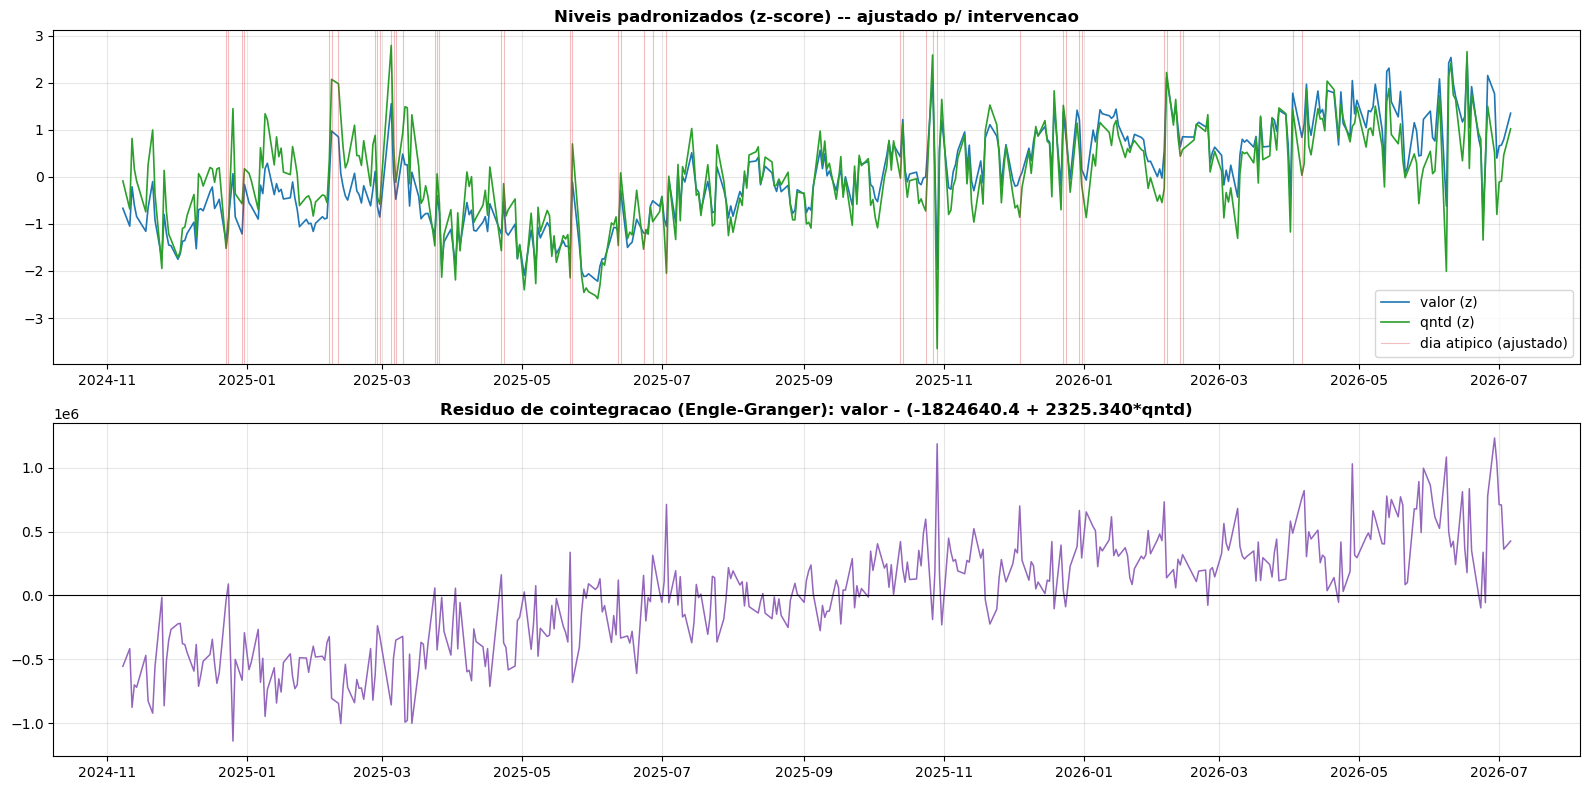

{'p_eg': np.float64(0.941878672961814),
 'beta': 2325.3400044979862,
 'resid': data
 2024-11-08   -556213.08
 2024-11-11   -417595.50
 2024-11-12   -877623.62
 2024-11-13   -701019.09
 2024-11-14   -720250.94
                 ...    
 2026-06-30   1036881.35
 2026-07-01    711389.76
 2026-07-02    707986.01
 2026-07-03    361813.02
 2026-07-06    425060.57
 Length: 413, dtype: float64,
 'ticket': data
 2024-11-08   1465.21
 2024-11-11   1447.75
 2024-11-12   1451.10
 2024-11-13   1441.62
 2024-11-14   1405.94
                ...  
 2026-06-30   2011.99
 2026-07-01   1921.84
 2026-07-02   1921.78
 2026-07-03   1831.81
 2026-07-06   1882.86
 Length: 413, dtype: float64,
 'n_dias_atipicos_ajustados': 42}

In [12]:
analise_cointegracao(serie_v, serie_q, nomes=('valor', 'qntd'))

In [13]:
def etl_pipeline():
    spark.conf.set("spark.sql.session.timeZone", "UTC")
    
    tz_sp = timezone(timedelta(hours=-3))
    hj = datetime.now(tz_sp)
    hj_str = hj.strftime('%Y-%m-%d')

    dim_calendario = spark.table("clickhouse.mis_s3.dim_calendario")
    
    row = dim_calendario.filter(
            (F.col("data") < F.to_date(F.lit(hj_str))) &
            (F.col("feriado") == 0) &
            (F.col("numerosemanadia") != 1)
        ) \
        .orderBy(F.col("data").desc()) \
        .select("data") \
        .first()
    data_referencia = row["data"]
    data_min = data_referencia - timedelta(days=45)

    data_referencia_str = data_referencia.strftime('%Y-%m-%d')
    data_min_str = data_min.strftime('%Y-%m-%d')

    # === DATAFRAME 1: Propostas (Ingestão e Agrupamento da Etapa 16) ===
    ft_proposta = spark.table("clickhouse.crefaz.ft_proposta")

    ft_proposta = ft_proposta.filter(
        (F.col("propostaetapaid") == 16) &
        (F.col("propostadecisaoid").isNull()) &
        (F.col("ultimaalteracao").cast("date").between(
            F.date_sub(F.current_date(), 55),
            F.date_sub(F.current_date(), 1)
        ))
    )

    interval_expr = F.to_timestamp(
        F.from_unixtime((F.unix_timestamp("ultimaalteracao") / 900).cast("long") * 900)
    ).alias("Intervalo")

    ft_proposta = ft_proposta.groupBy(interval_expr).agg(
        F.sum("valor").alias("valor"),
        F.count("propostaid").alias("qntd")
    )

    ft_proposta = ft_proposta.withColumn(
        "data_hora",
        F.to_timestamp(F.split(F.col("Intervalo").cast("string"), "\\+").getItem(0))
    ).withColumn(
        "data",
        F.to_date("data_hora")
    )

    ft_proposta = ft_proposta.filter(
        (F.col("data") <= F.to_date(F.lit(data_referencia_str))) &
        (F.col("data") > F.to_date(F.lit(data_min_str)))
    )

    ft_proposta = ft_proposta.groupBy("data").agg(
        F.sum("qntd").alias("qntd"),
        F.sum("valor").alias("valor")
    )

    ft_proposta = ft_proposta.withColumn("qntd", F.col("qntd").cast("integer"))

    # === DATAFRAME 2: Fila (Quantidade de Propostas na Etapa 15) ===
    dbo_propostastatushistorico = spark.table("clickhouse.crefazon15m.dbo_propostastatushistorico")

    dbo_propostastatushistorico = dbo_propostastatushistorico.filter(
        (F.col("data") > F.date_sub(F.current_date(), 65)) &
        (F.col("data") < F.current_date())
    )

    dbo_propostastatushistorico = dbo_propostastatushistorico.groupBy(
        "propostaid",
        F.to_date("data").alias("Data")
    ).agg(
        F.max(F.struct("data", "id", "propostaetapaid")).alias("max_struct")
    ).select(
        "Data",
        "propostaid",
        F.col("max_struct.propostaetapaid").alias("etapa")
    )

    dbo_propostastatushistorico = dbo_propostastatushistorico.filter(F.col("etapa") == 15) \
                    .groupBy("Data") \
                    .agg(F.count("propostaid").alias("QUANTIDADE"))

    dbo_propostastatushistorico = dbo_propostastatushistorico.withColumnRenamed("Data", "data")

    # === JOIN: Cruzamento dos dados de Propostas (DF 1) com o Histórico de Fila (DF 2) ===
    df_merged = ft_proposta.join(dbo_propostastatushistorico, on="data", how="left")

    # Mesma tabela (cálculo dos lags de predição, sem lag fictício em lag_0, lag_1 e lag_7) -> mantém o nome
    window_spec = Window.orderBy("data")
    df_merged = df_merged \
        .withColumn("lag_0", F.col("qntd")) \
        .withColumn("lag_1", F.col("valor")) \
        .withColumn("lag_2", F.lag("valor", 1).over(window_spec)) \
        .withColumn("lag_3", F.lag("valor", 2).over(window_spec)) \
        .withColumn("lag_4", F.lag("valor", 3).over(window_spec)) \
        .withColumn("lag_5", F.lag("valor", 4).over(window_spec)) \
        .withColumn("lag_6", F.lag("valor", 5).over(window_spec)) \
        .withColumn("lag_7", F.col("QUANTIDADE"))

    df_merged = df_merged.dropna().orderBy("data").drop('data', 'qntd', 'valor', 'QUANTIDADE')

    return df_merged.toPandas()

def model_construct():
    # === load model ===
    path_model = 's3://crefaz-temp-sa-east-1-794038227804-hml/engdados/felipe_zandonadi/projects/modelo_treinado-2026-05-26.pkl'

    if path_model.startswith("s3://"):
        parsed_url = urlparse(path_model)
        bucket_name = parsed_url.netloc
        model_key = parsed_url.path.lstrip("/")

        s3_client = boto3.client("s3")
        response = s3_client.get_object(Bucket=bucket_name, Key=model_key)
        model = joblib.load(io.BytesIO(response["Body"].read()))
    else:
        model = joblib.load(path_model)

    return model

def ml_pipeline(model, df):
    # Seleciona o registro mais recente (ontem)
    ultima_linha = df.tail(1).copy()

    # O dia_semana para a predição deve ser o dia de HOJE
    tz_sp = timezone(timedelta(hours=-3))
    hoje = datetime.now(tz_sp)
    ultima_linha['dia_semana'] = hoje.weekday()  # Monday=0, Sunday=6

    # Garante a ordem exata das features esperada pelo modelo
    cols_model = ['dia_semana', 'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7']
    ultima_linha = ultima_linha[cols_model]

    prediction = model.predict(ultima_linha)

    return prediction[0]


 

## 3 - AREA VALOR

### 3.A Estimação

In [14]:
serie_v

data
2024-11-08   4055687.67
2024-11-11   3699007.83
2024-11-12   4485361.95
2024-11-13   4120162.26
2024-11-14   3891649.81
                ...    
2026-06-30   5058145.74
2026-07-01   5302362.45
2026-07-02   5317561.42
2026-07-03   5429480.41
2026-07-06   5955470.62
Name: valor, Length: 413, dtype: float64

Ordem (auto_arima, univariado): SARIMA(1, 1, 2) x (0, 0, 1, 5)  | AIC=12135.7
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6038      1.538     -0.393      0.695      -3.619       2.411
ma.L1         -0.1771      1.529     -0.116      0.908      -3.175       2.821
ma.L2         -0.4880      1.189     -0.411      0.681      -2.818       1.842
ma.S.L5       -0.1179      0.054     -2.173      0.030      -0.224      -0.012
sigma2      3.628e+11   5.17e-11   7.01e+21      0.000    3.63e+11    3.63e+11


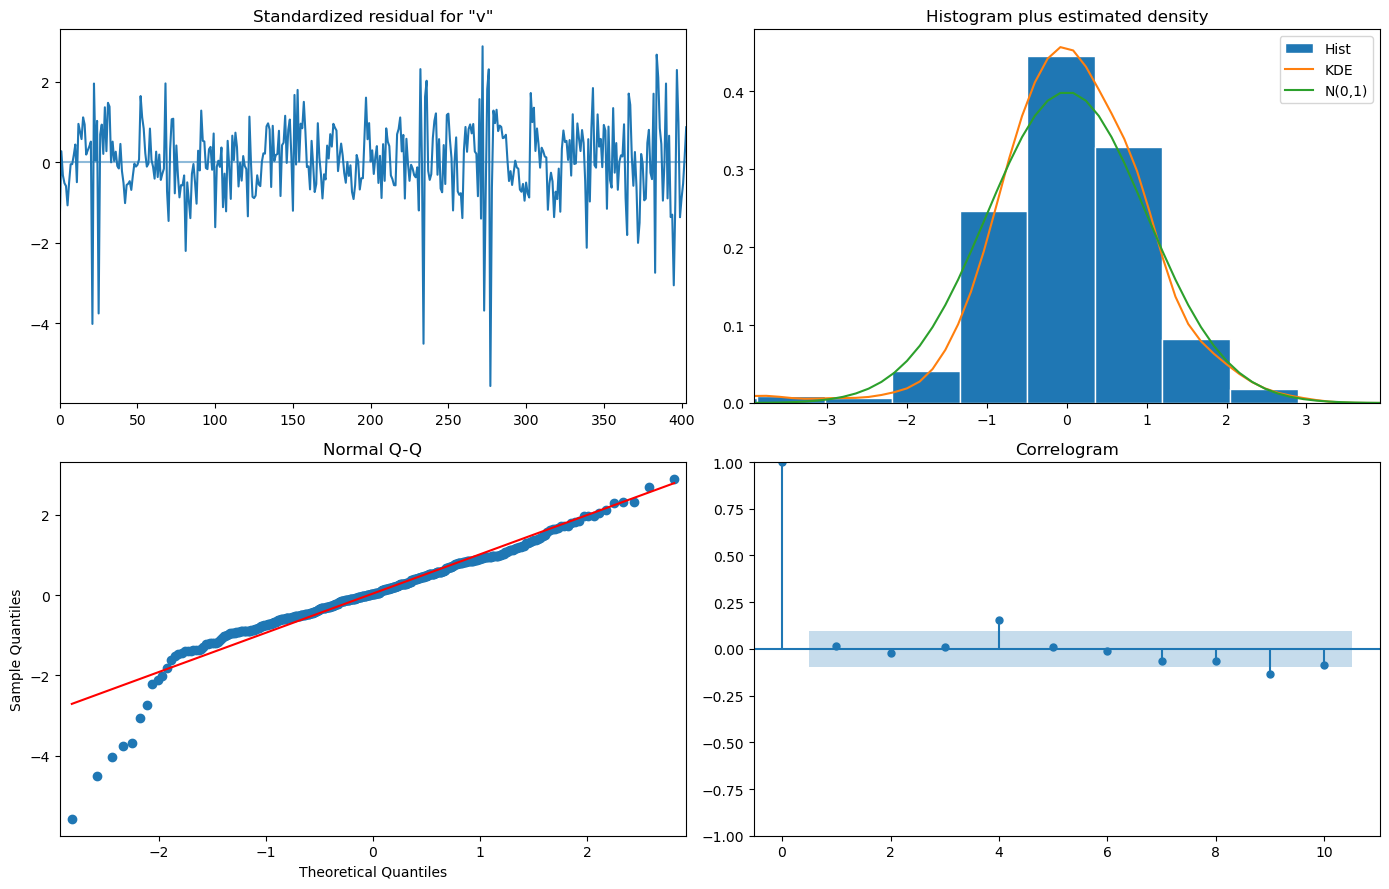

Ljung-Box (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10    23.28       0.01
20    47.48       0.00


In [15]:
order_v, seas_v, aic_v = selecionar_ordem(serie_v)
print(f'Ordem (auto_arima, univariado): SARIMA{order_v} x {seas_v}  | AIC={aic_v:.1f}')
res_v = ajustar_sarimax(serie_v, order_v, seas_v, None)
print(res_v.summary().tables[1])
try:
    res_v.plot_diagnostics(figsize=(14, 9)); plt.tight_layout(); plt.show()
except Exception as e:
    print('diagnostics:', e)
print('Ljung-Box (H0 = residuos sem autocorrelacao):')
print(acorr_ljungbox(res_v.resid, lags=[10, 20], return_df=True))

### Analise de intervencao (efeito por evento + residuo pre/pos)

Efeito dos **dias especiais** (eventos do `Log_Erro` e vesperas de feriado) sobre a serie de
valor, via **regressores de intervencao** (Box-Tiao) ja montados acima. Cada evento e
classificado em **abrupto** (efeito transitorio, constante nos dias de impacto) ou **gradual**
(efeito decaindo ao longo da janela de impacto), escolhendo por significancia (p<0.05) e menor
AIC; sem efeito significativo -> `nao signif.`. Abaixo: tabela por evento, barra de efeito
(SARIMAX) e comparacao do **residuo PRE x POS** intervencao (ajuste SARIMA univariado).

=== Analise classica: Valor (R$) | n=413 | 2024-11-08 -> 2026-07-06 ===


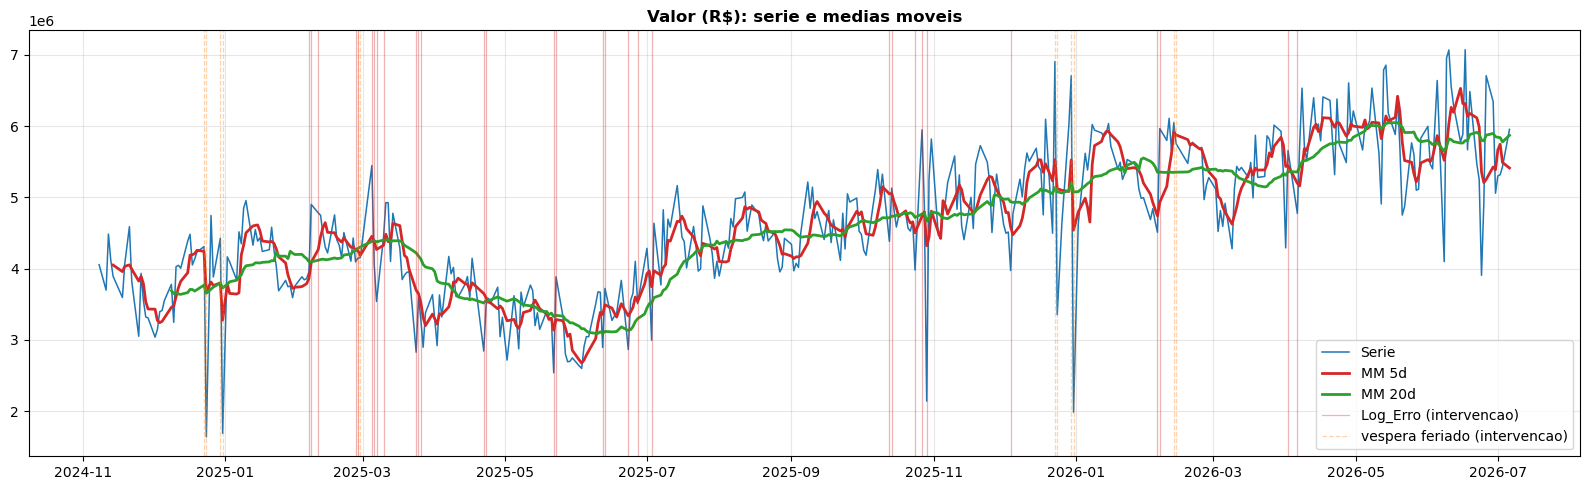

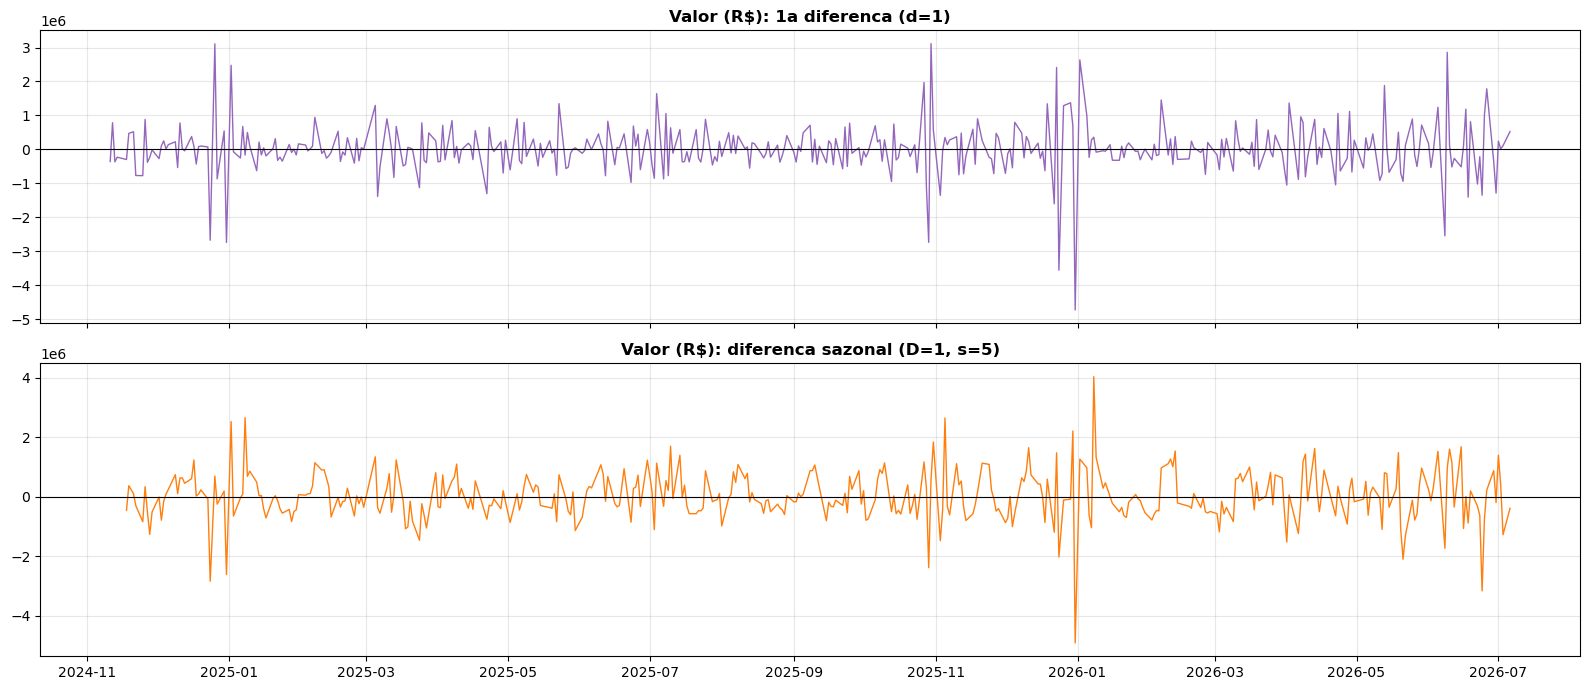

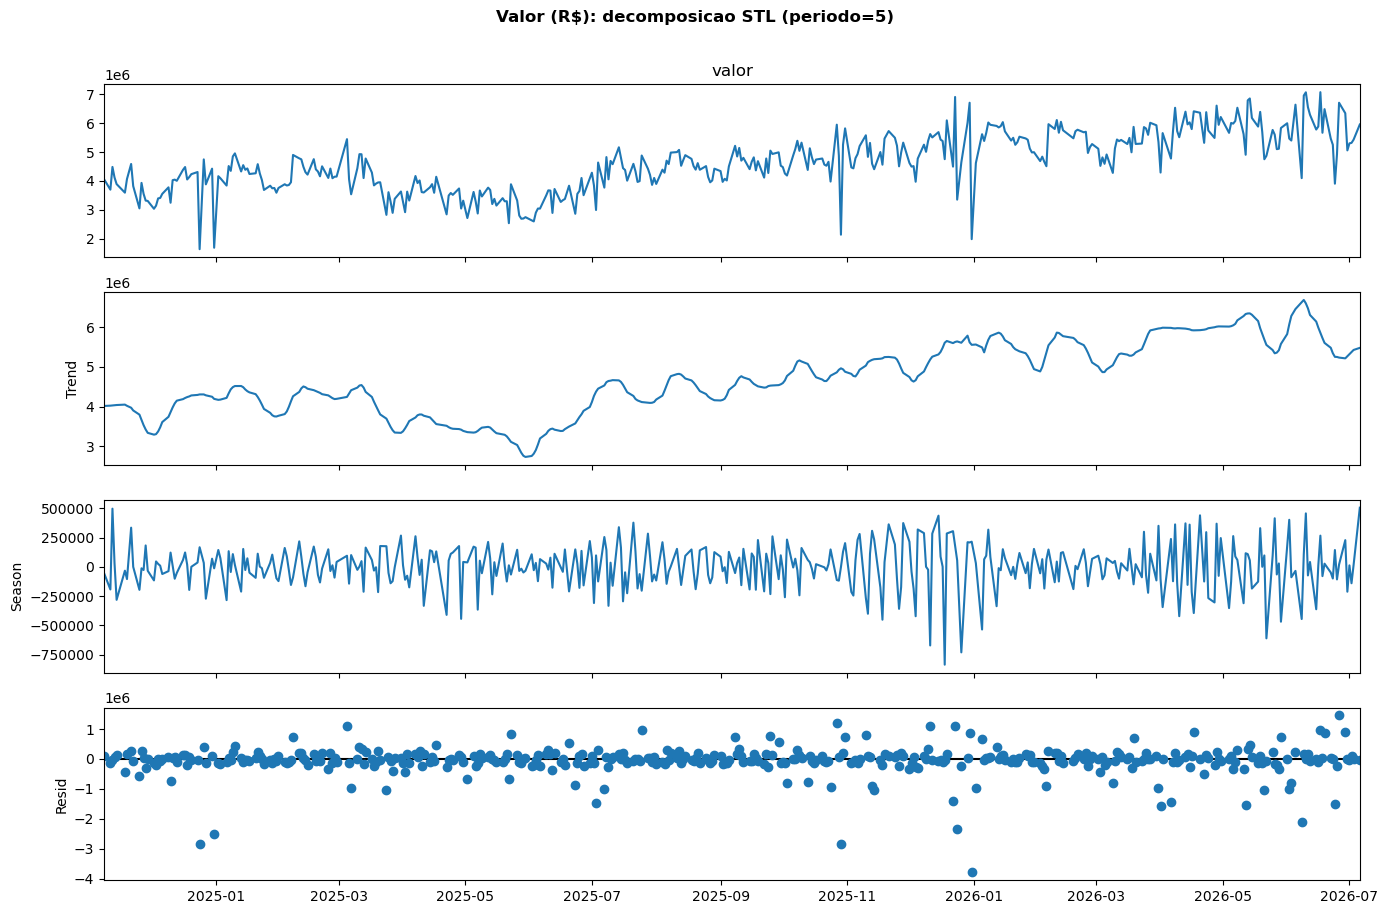

Estacionariedade (ADF H0=raiz unitaria | KPSS H0=estacionaria) -- ADF bruto x ajustado p/ intervencao (42 dias atipicos: Log_Erro + vespera Natal/AnoNovo/Carnaval):
  nivel              ADF bruto p=0.8175 (NAO estac.)  |  ADF ajustado p=0.7457 (NAO estac.)  |  KPSS (bruto) p=0.0100 (NAO estac.)
  1a diferenca       ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)
  diff sazonal(5)    ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)


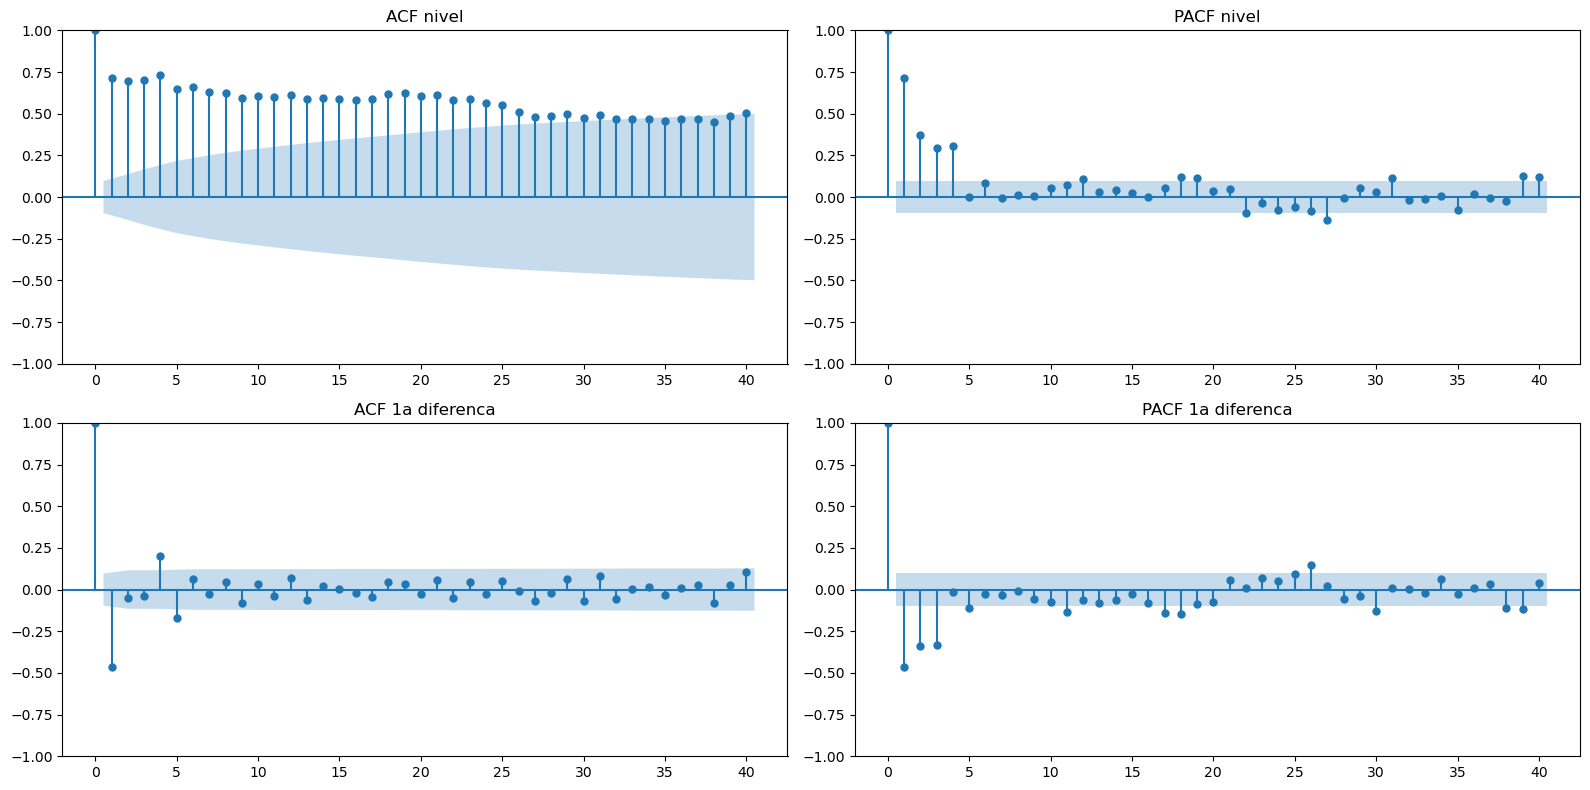

[cache hit] analise_intervencao <- analise_intervencao_4de9ce510fb2748d.pkl
[cache saved] analise_transferencia -> analise_transferencia_60bb1e1abb321422.pkl
[cache hit] analise_intervencao <- analise_intervencao_74064fe8ce63215e.pkl
[cache saved] analise_transferencia -> analise_transferencia_9b8e3dd477feb3be.pkl

Valor (R$) | SARIMA {'abrupto': 6, 'gradual': 5, 'e': 3, 'nao signif.': 3, 'b': 3, 'rebote': 2, 'd': 1} -> 26 regressores | SARIMAX {'gradual': 7, 'abrupto': 6, 'e': 3, 'b': 2, 'rebote': 2, 'd': 1, 'nao signif.': 1, 'f': 1} -> 28 regressores
  -> 7 evento(s) usam funcao de TRANSFERENCIA (b/c/d/e/f) no fit final (SARIMAX)

Tabela de intervencao classica -- Valor (R$) / SARIMAX:


,Evento,Tipo,Inicio,n_dias,Impacto/dias,coef_abrupto,p_abrupto,AIC_abrupto,coef_gradual,p_gradual,AIC_gradual,coef_rebote_dia1,coef_rebote_pos,p_rebote_dia1,p_rebote_pos,AIC_rebote,Classe
0,dia anterior a vespera de Natal (n=2),vespera,2024-12-23,2,1,2215559.40,0.00,11880.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto
1,vespera Natal (n=2),vespera,2024-12-24,2,1,-2569453.50,0.00,11849.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto
2,dia anterior a vespera de Ano Novo (n=2),vespera,2024-12-30,2,1,2086051.70,0.00,11879.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto
3,vespera Ano Novo (n=2),vespera,2024-12-31,2,1,-2957263.40,0.00,11833.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,abrupto
4,BrSCAM (2025-02-06),log_erro,2025-02-06,3,3,53971.80,0.91,11888.50,-152668.60,0.00,11889.10,-222713.00,330112.70,0.08,0.59,11889.20,gradual
5,CrefazOn (2025-02-26),log_erro,2025-02-26,2,2,48991.20,0.00,11888.80,17038.60,0.00,11888.80,17099.80,80911.00,0.00,0.00,11890.80,gradual
6,dia anterior a vespera de Carnaval (n=2),vespera,2025-02-27,2,1,201736.10,0.78,11888.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nao signif.
7,vespera Carnaval (n=2),vespera,2025-02-28,2,1,-531490.90,0.24,11890.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nao signif.
8,Carnaval (2025-03-05),log_erro,2025-03-05,2,2,1118791.80,0.00,11886.60,1771782.50,0.01,11884.20,1771765.90,473425.40,0.00,0.39,11884.60,gradual
9,Bacen - Fila Pagamento (2025-03-07),log_erro,2025-03-07,2,2,-514275.80,0.33,11887.90,-905676.30,0.00,11887.10,-905353.30,-121200.50,0.00,0.00,11888.40,gradual



Decisao COMBINADA (classica x transferencia Box-Tiao) por evento -- Valor (R$) / SARIMAX:


,Evento,Tipo,Inicio,Vencedor,delta,AIC_vencedor,AIC_abrupto
0,dia anterior a vespera de Natal (n=2),vespera,2024-12-23,e,0.10,11849.50,11880.40
1,vespera Natal (n=2),vespera,2024-12-24,abrupto,NaN,11849.30,11849.30
2,dia anterior a vespera de Ano Novo (n=2),vespera,2024-12-30,e,0.20,11826.90,11879.40
3,vespera Ano Novo (n=2),vespera,2024-12-31,e,0.10,11832.50,11833.40
4,BrSCAM (2025-02-06),log_erro,2025-02-06,gradual,NaN,11889.10,11888.50
5,CrefazOn (2025-02-26),log_erro,2025-02-26,abrupto,NaN,11888.80,11888.80
6,dia anterior a vespera de Carnaval (n=2),vespera,2025-02-27,d,0.90,11889.40,11888.30
7,vespera Carnaval (n=2),vespera,2025-02-28,b,0.20,11886.50,11890.20
8,Carnaval (2025-03-05),log_erro,2025-03-05,gradual,NaN,11884.20,11886.60
9,Bacen - Fila Pagamento (2025-03-07),log_erro,2025-03-07,gradual,NaN,11887.10,11887.90


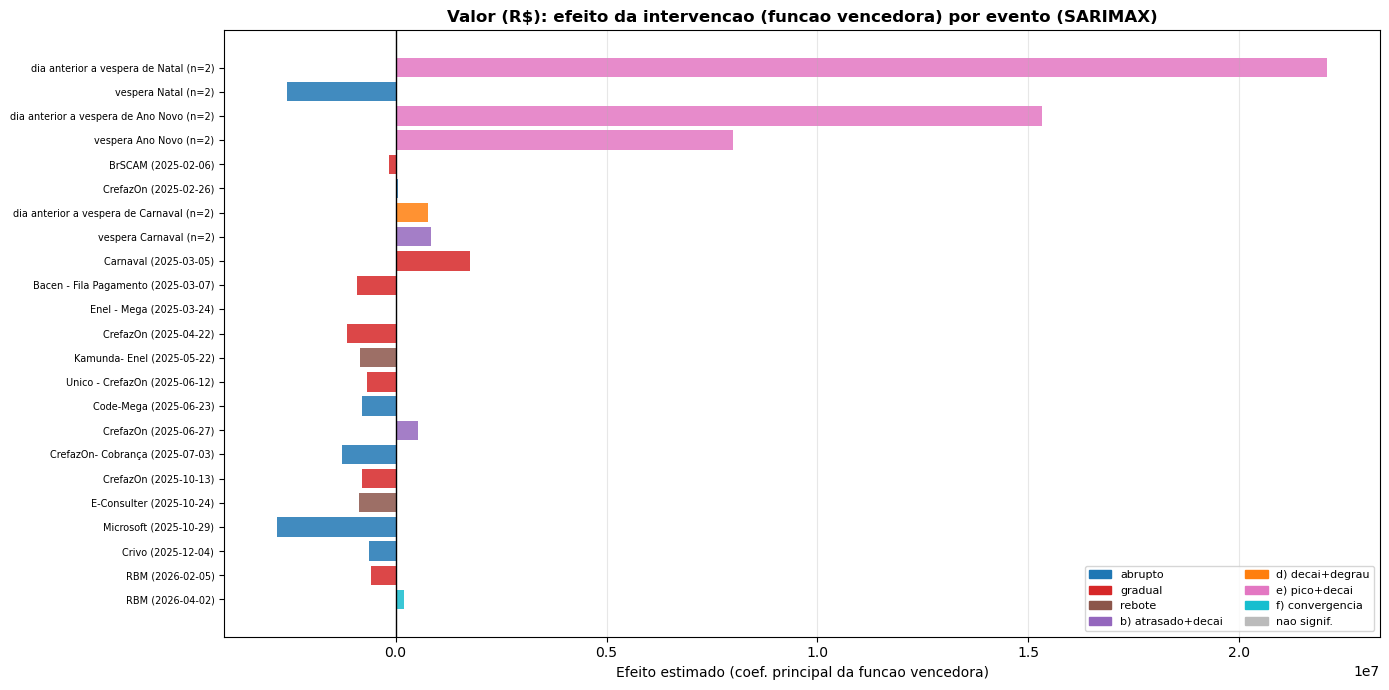

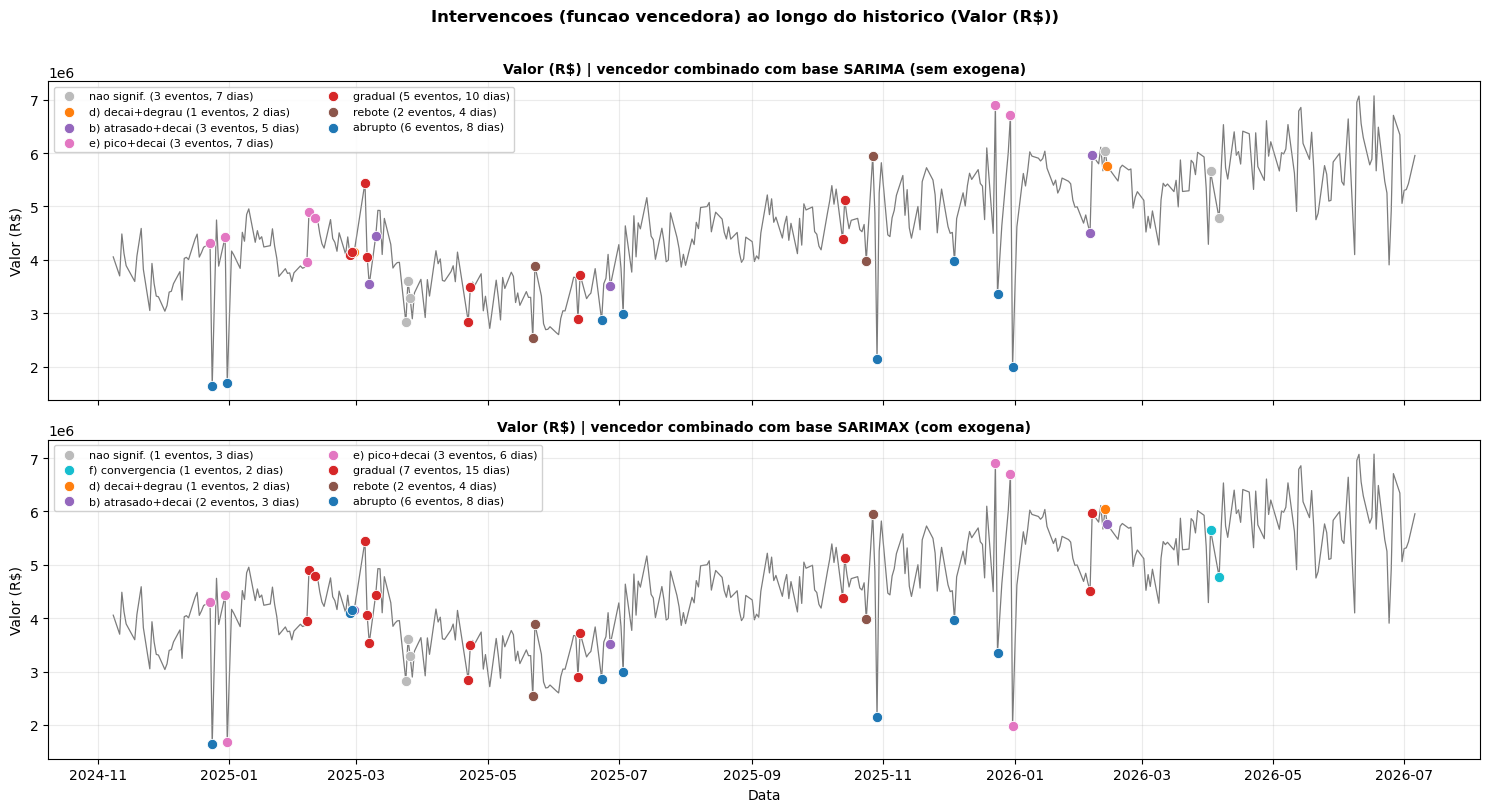

RESIDUO PRE x POS INTERVENCAO -- Valor (R$) -- SARIMA


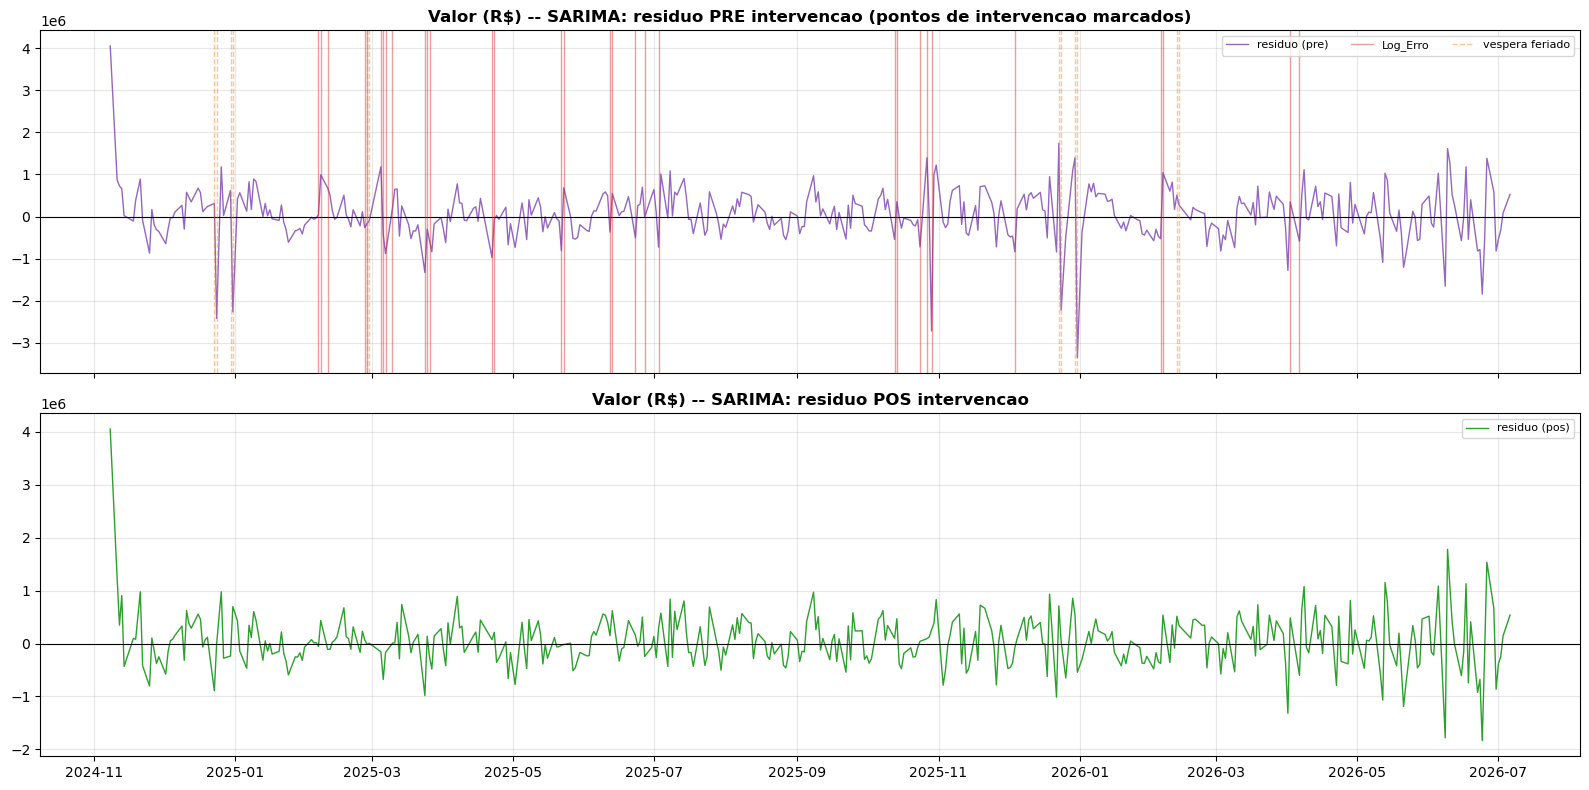

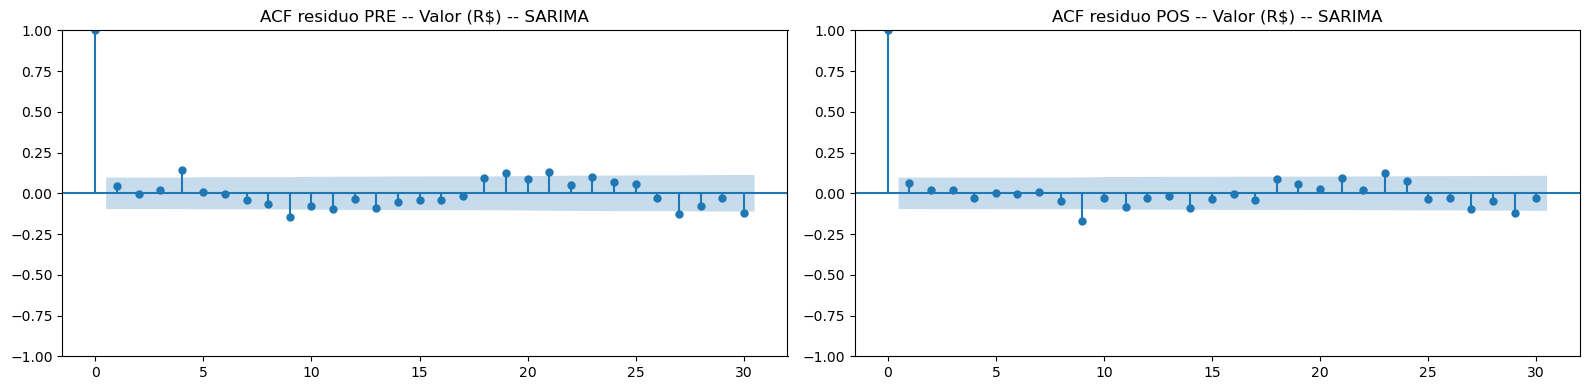

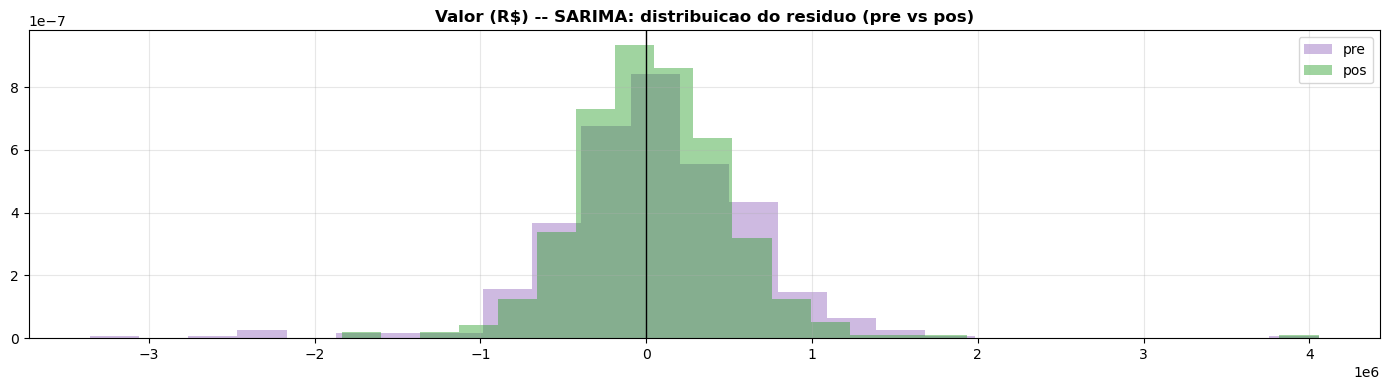

Resumo do residuo (pre vs pos):


,Modelo,n,AIC,BIC,DP residuo,MAE residuo,LB p(10),LB p(20),JB p (normal.)
0,PRE (sem intervencao),413,11892.40,11912.40,619891.26,436390.60,0.01,0.00,0.00
1,POS (com intervencao),413,11720.00,11844.00,492195.19,354285.70,0.09,0.09,0.00


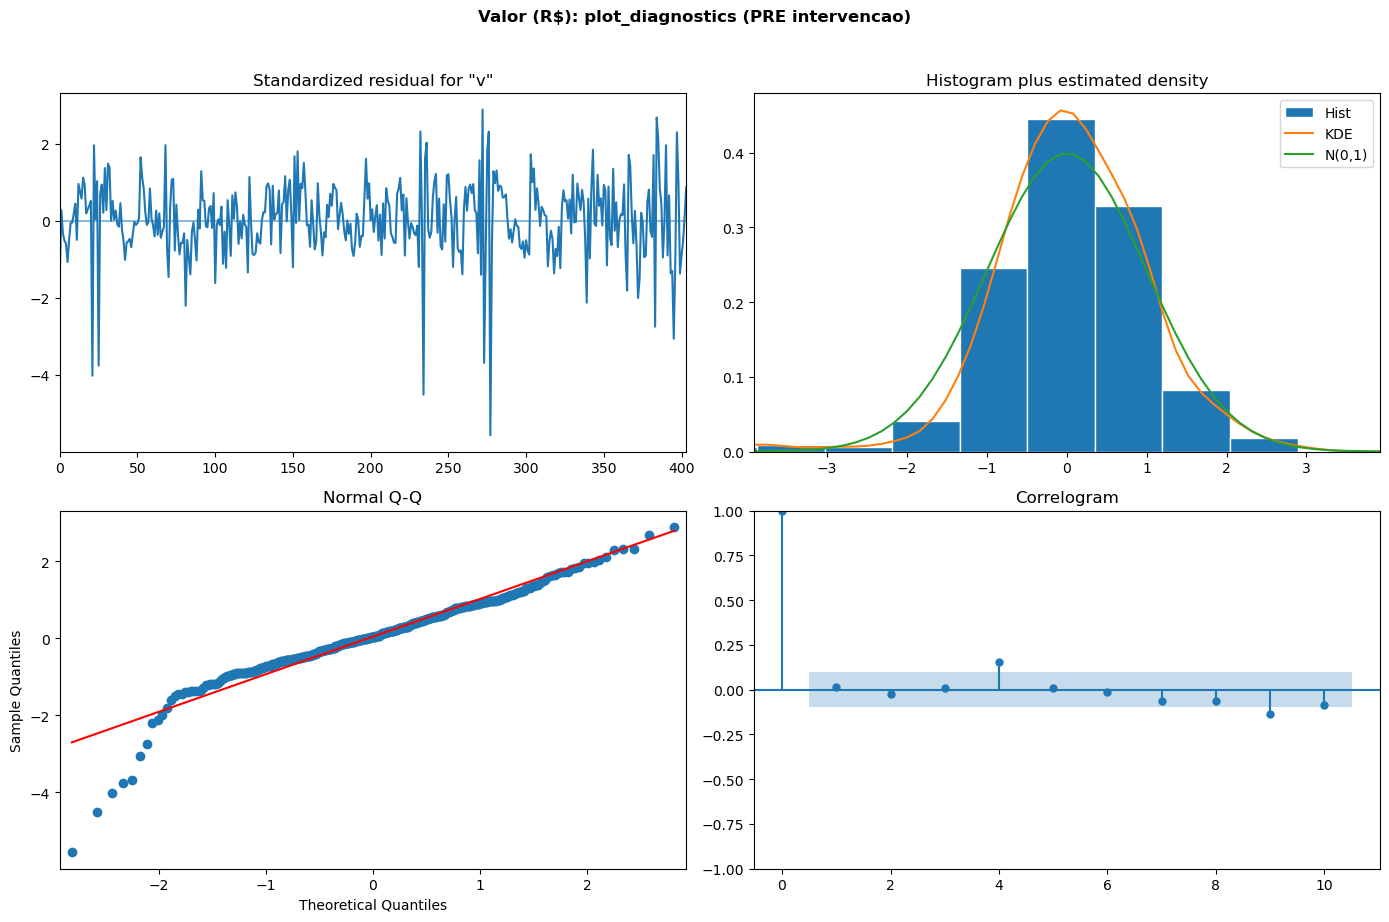

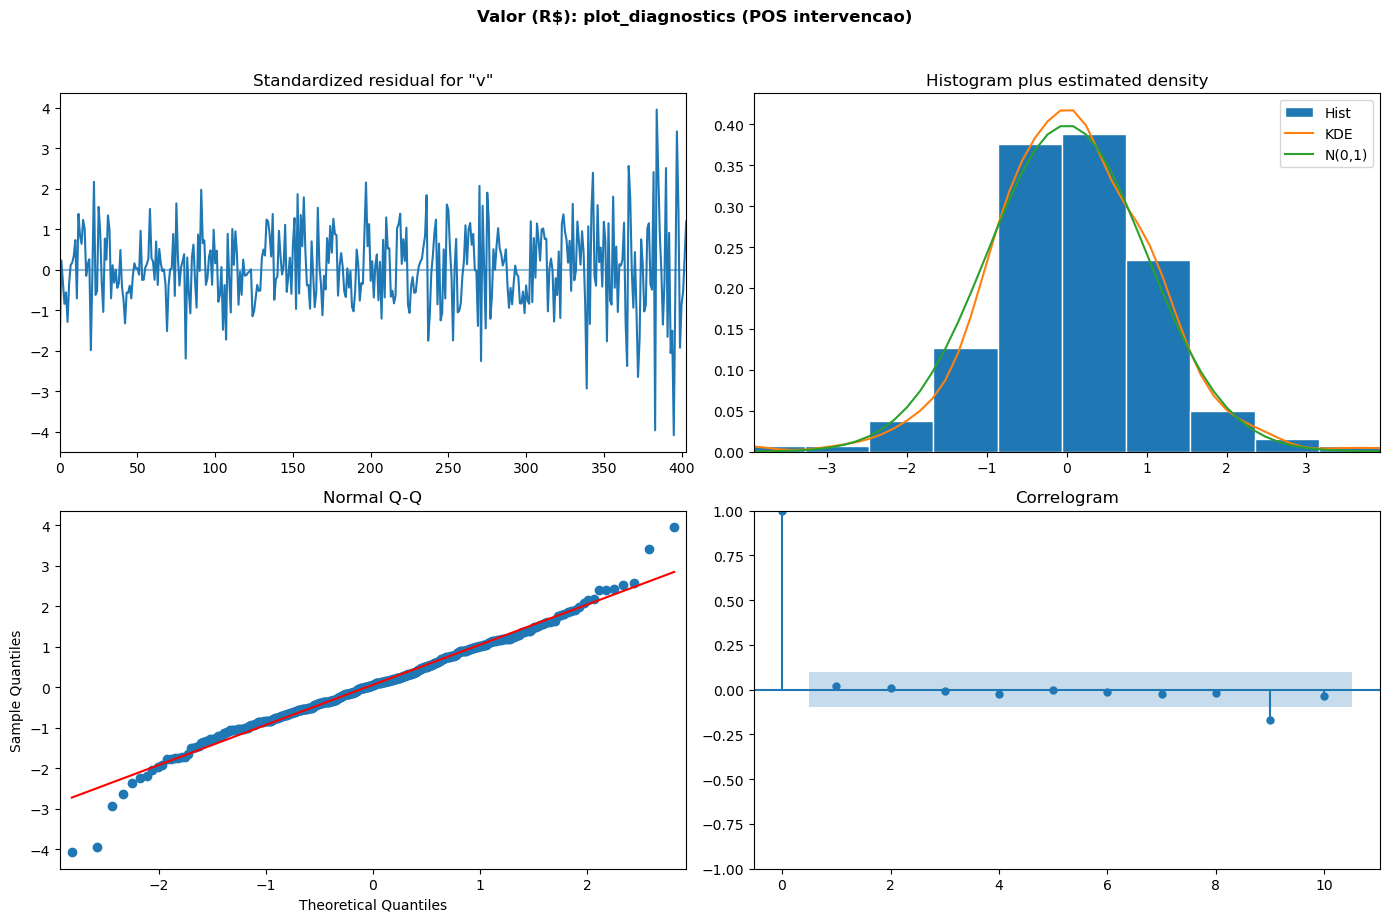


Ljung-Box (POS intervencao) -- Valor (R$) (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10    16.20       0.09
20    29.10       0.09


In [16]:
# ===== Analise classica + intervencao -- VALOR =====
# analise_classifica_intervencao junta: (1) analise classica (medias moveis, STL, ADF/KPSS,
# ACF/PACF), (2) classificacao da intervencao por evento -- SARIMA e SARIMAX -- + onde cada
# uma cai no historico, e (3) residuo PRE (sem intervencao) x POS (com intervencao). As
# matrizes X_int_* seguem sendo usadas na avaliacao (Secao 3) e na correcao de vies.
resultado_v = analise_classifica_intervencao(serie_v, order_v, seas_v, eventos_v,
                                             nome='Valor (R$)', exog=exog_v, res_pre=res_v)
interv_sarima_v,  classes_sarima_v,  X_int_sarima_v  = (resultado_v['interv_sarima'],
                                                        resultado_v['classes_sarima'], resultado_v['X_int_sarima'])
interv_sarimax_v, classes_sarimax_v, X_int_sarimax_v = (resultado_v['interv_sarimax'],
                                                        resultado_v['classes_sarimax'], resultado_v['X_int_sarimax'])

In [17]:
print(res_v.summary().tables[0])

                                      SARIMAX Results                                      
Dep. Variable:                               valor   No. Observations:                  413
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 5)   Log Likelihood               -5941.196
Date:                             Tue, 07 Jul 2026   AIC                          11892.392
Time:                                     15:02:14   BIC                          11912.399
Sample:                                          0   HQIC                         11900.312
                                             - 413                                         
Covariance Type:                               opg                                         


In [18]:
_df_db_valor, ranking_valor = avaliar_area(
    'valor', serie_v, exog_v, order_v, seas_v,
    'resultados/backup_valor.xlsx', 'Dia Referência', dfull_v,
    exog_int_u=X_int_sarima_v, exog_int_x=X_int_sarimax_v,
    eventos=eventos_v, interv_lr=interv_sarima_v)   # inclui LOG-RETORNO no ranking
print('\nRanking VALOR (ordenado por RMSPE):')
display(_com_modelo(ranking_valor))

[avaliar_area_valor] hash por componente (compare com a execucao anterior p/ achar o que mudou): codigo=4102139fea598208 | serie=9c19b25bdd65c0e6 | exog=b05b886403447141 | exog_int_u=69beec3d9e224cf6 | exog_int_x=48d6637422d9cecc | order_seas=ed54e549f61bb3d6 | d_full=020091e32a56e3af | backup_fp=74073fcce9d197ce | vies_fp=62a9094e3575e046 | globals=607a33aed389bb2b
[valor] datas de avaliacao: overlap=232 | apos remover atipicos (Log_Erro+vespera)=210
[valor] restrito as datas dos _vies (datas_avaliadas_valor.pkl): 210 -> 209
[valor] PERIODO avaliado: 2025-02-05 -> 2026-04-16 | N=209
[valor] linhas em dias atipicos removidas do _df_db: 22
[valor] datas comuns a todos os modelos: 209
[cache saved] avaliar_area_valor -> avaliar_area_valor_951f2d18a1be0bc9.pkl

Ranking VALOR (ordenado por RMSPE):


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,MAE,DP Erro,Mediana (%),N
0,SARIMA,7.35,9.36,0.75,-594.40,594.40,333398.60,432295.20,6.28,209.00
1,Pipeline Antiga em Producao,7.23,9.57,0.74,28430.70,28430.70,330061.50,435522.70,5.35,209.00
2,SARIMAX,7.72,10.02,0.71,-11360.50,11360.50,349873.80,468379.90,6.54,209.00
3,LOG-RETORNO,8.31,11.18,0.61,72983.30,72983.30,381770.50,534886.70,6.69,209.00


#### Export das predicoes (p/ import no `experimento_valor`, Secao 4.A)

In [19]:
# ==================== EXPORT: predicoes SARIMAX (valor) ====================
# Usado pela Secao 4.A do experimento_valor.ipynb para comparar o SARIMAX com os
# modelos de ML nas mesmas condicoes (mesma base comum de datas + remocao de
# Log_Erro/vesperas ja feita la). So a previsao crua e exportada (sem debias).
_export_v = _df_db_valor[_df_db_valor['Modelo'] == 'SARIMAX'][
    ['Dia Prevista', 'Valor Previsto', 'Valor Realizado']
].dropna().sort_values('Dia Prevista').reset_index(drop=True)
_export_v.insert(0, 'Modelo', 'SARIMAX')
os.makedirs('resultados', exist_ok=True)
_export_v.to_pickle(r'resultados\sarimax_valor_predicoes.pkl')
print(f'[export] SARIMAX (valor) -> resultados/sarimax_valor_predicoes.pkl | '
      f'{len(_export_v)} previsoes | '
      f'{_export_v["Dia Prevista"].min().date()} -> {_export_v["Dia Prevista"].max().date()}')


[export] SARIMAX (valor) -> resultados/sarimax_valor_predicoes.pkl | 209 previsoes | 2025-02-05 -> 2026-04-16


### 3.B - VALOR: comparacao de todos os modelos 

VALOR 5.C - comparacao de todos os modelos:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,MAE,DP Erro,Mediana (%),N
0,SARIMA,7.35,9.36,0.75,-594.40,594.40,333398.60,432295.20,6.28,209.00
1,Pipeline Antiga em Producao,7.23,9.57,0.74,28430.70,28430.70,330061.50,435522.70,5.35,209.00
2,SARIMAX,7.72,10.02,0.71,-11360.50,11360.50,349873.80,468379.90,6.54,209.00
3,LOG-RETORNO,8.31,11.18,0.61,72983.30,72983.30,381770.50,534886.70,6.69,209.00



### VALOR 5.C | Parte 1 - Historico completo


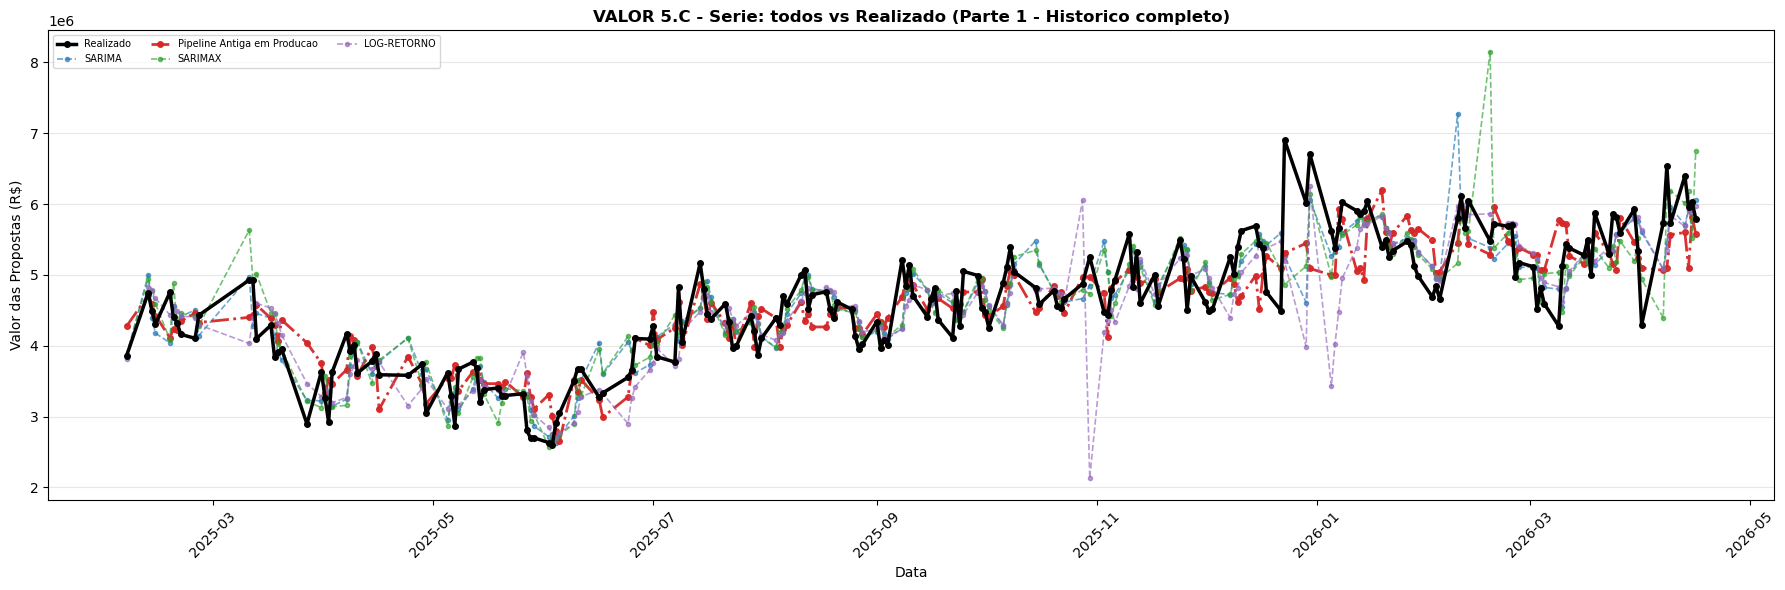

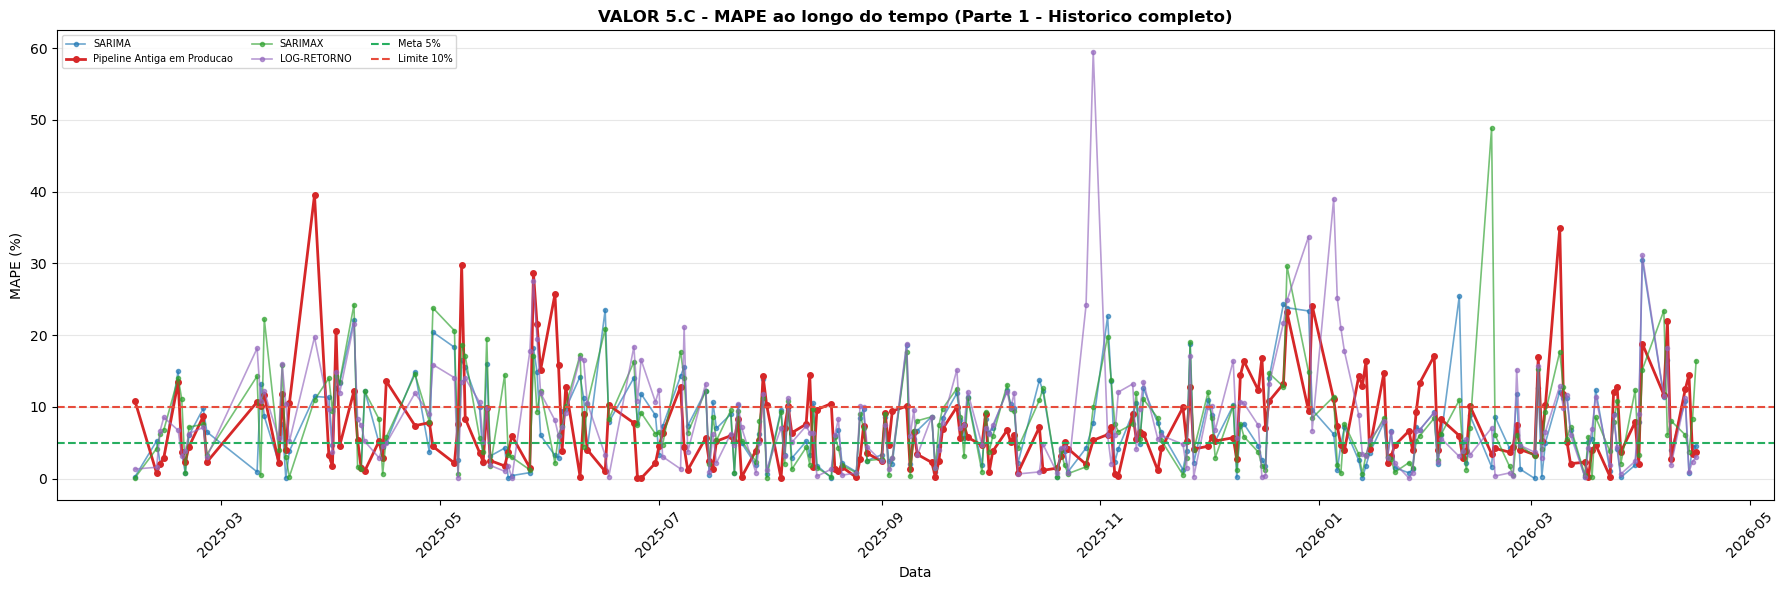

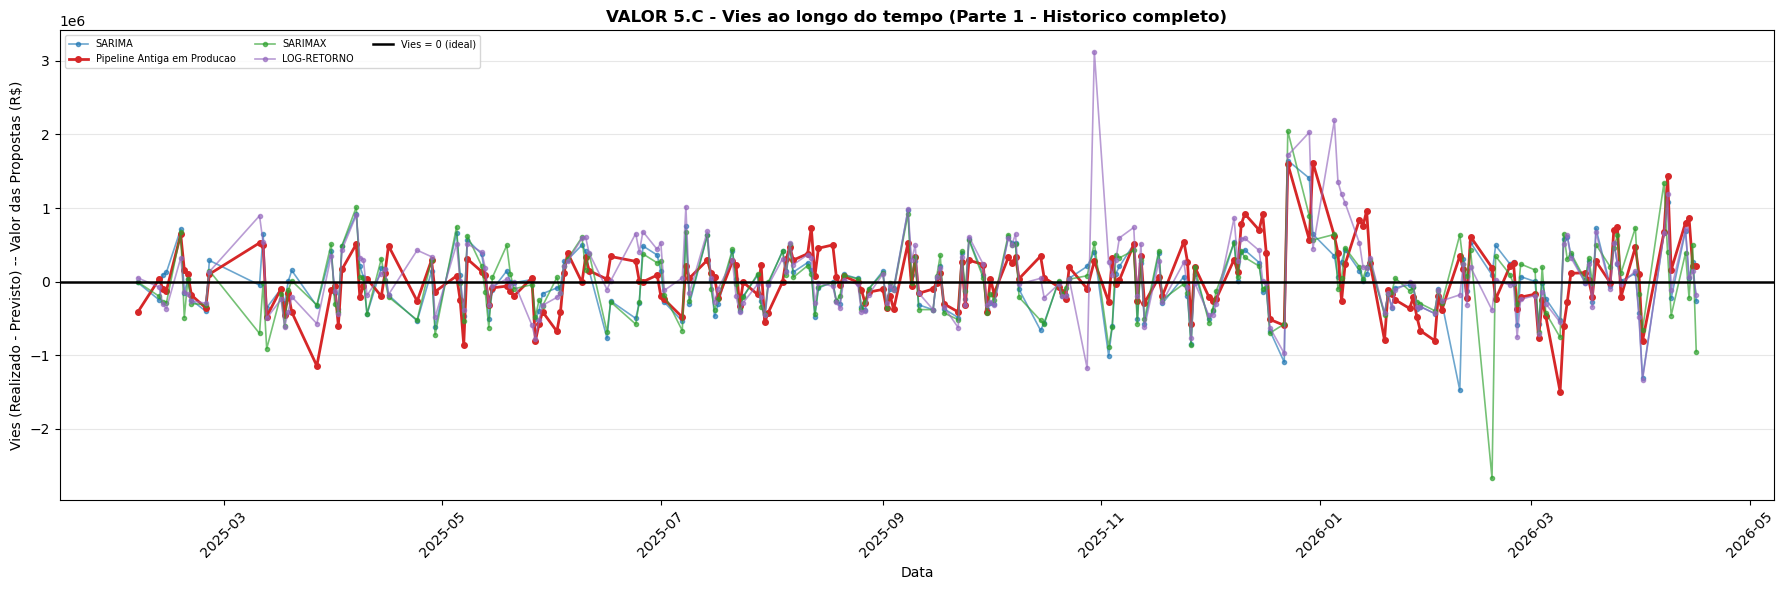


-- Metricas do periodo -- Parte 1 - Historico completo:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMA,7.35,9.36,0.75,-594.40,594.40,-0.63,333398.60,432295.20,9.37,6.28,0.04,30.52,88/209,152/209,209
1,Pipeline Antiga em Producao,7.23,9.57,0.74,28430.70,28430.70,-0.33,330061.50,435522.70,9.44,5.35,0.05,39.52,95/209,154/209,209
2,SARIMAX,7.72,10.02,0.71,-11360.50,11360.50,-0.86,349873.80,468379.90,10.15,6.54,0.13,48.82,81/209,151/209,209
3,LOG-RETORNO,8.30,11.18,0.61,72983.30,72983.30,0.85,381770.50,534886.70,11.59,6.69,0.06,59.50,77/209,144/209,209



### VALOR 5.C | Parte 2 - Janeiro em diante


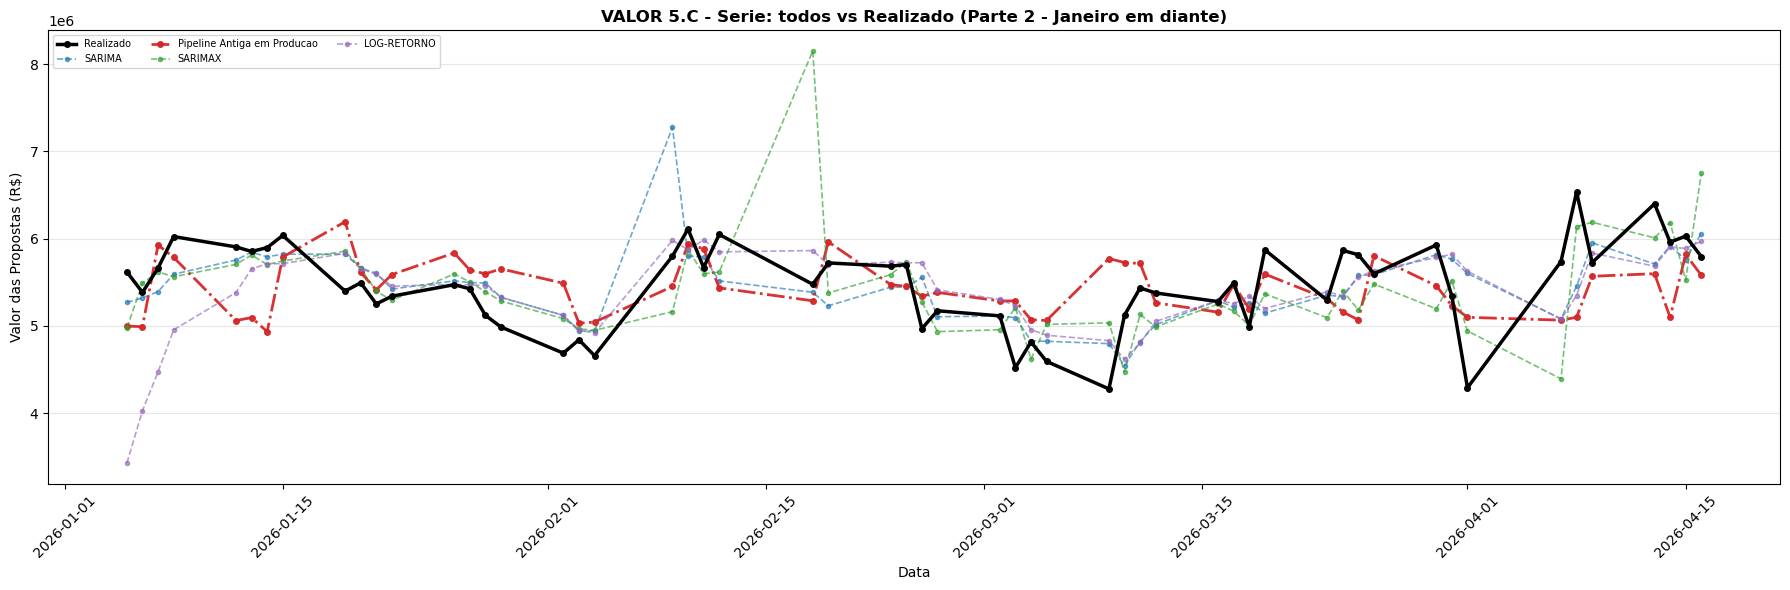

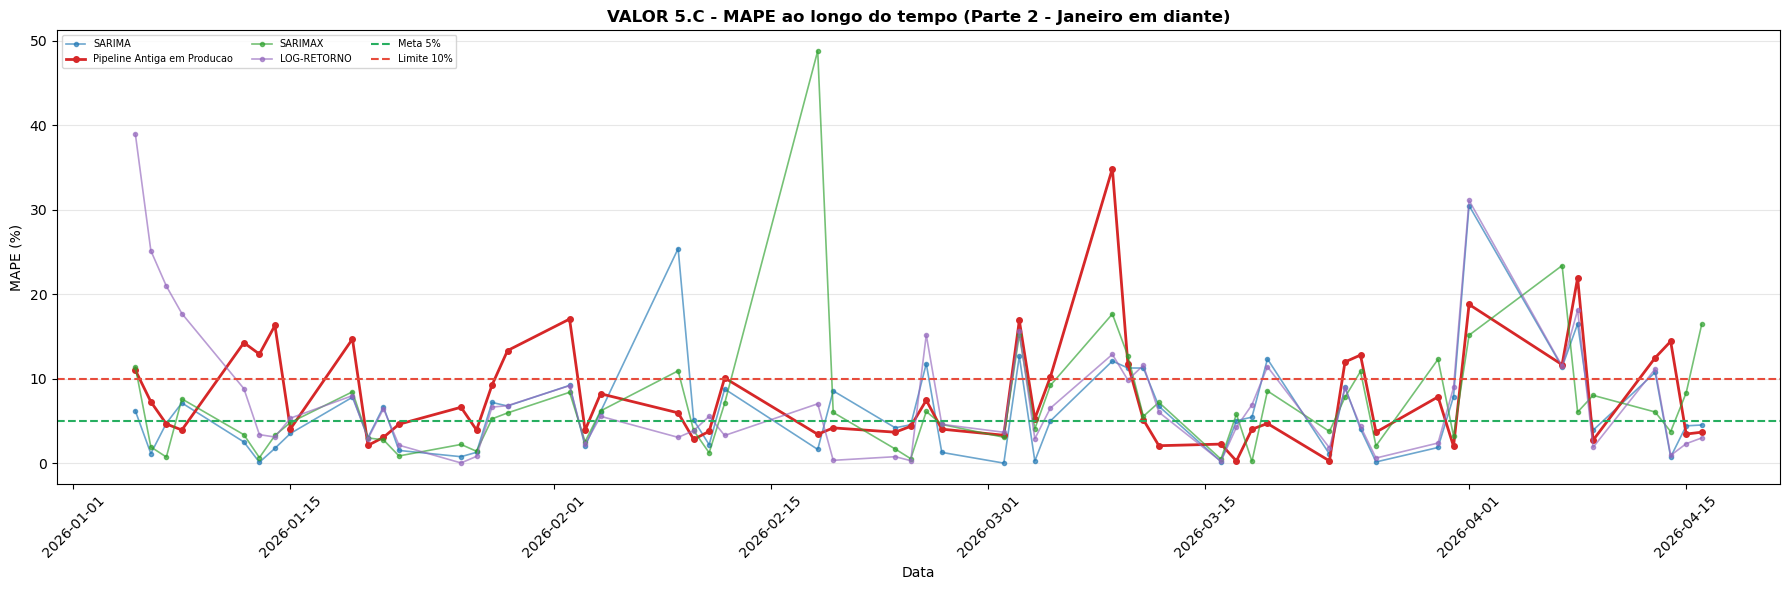

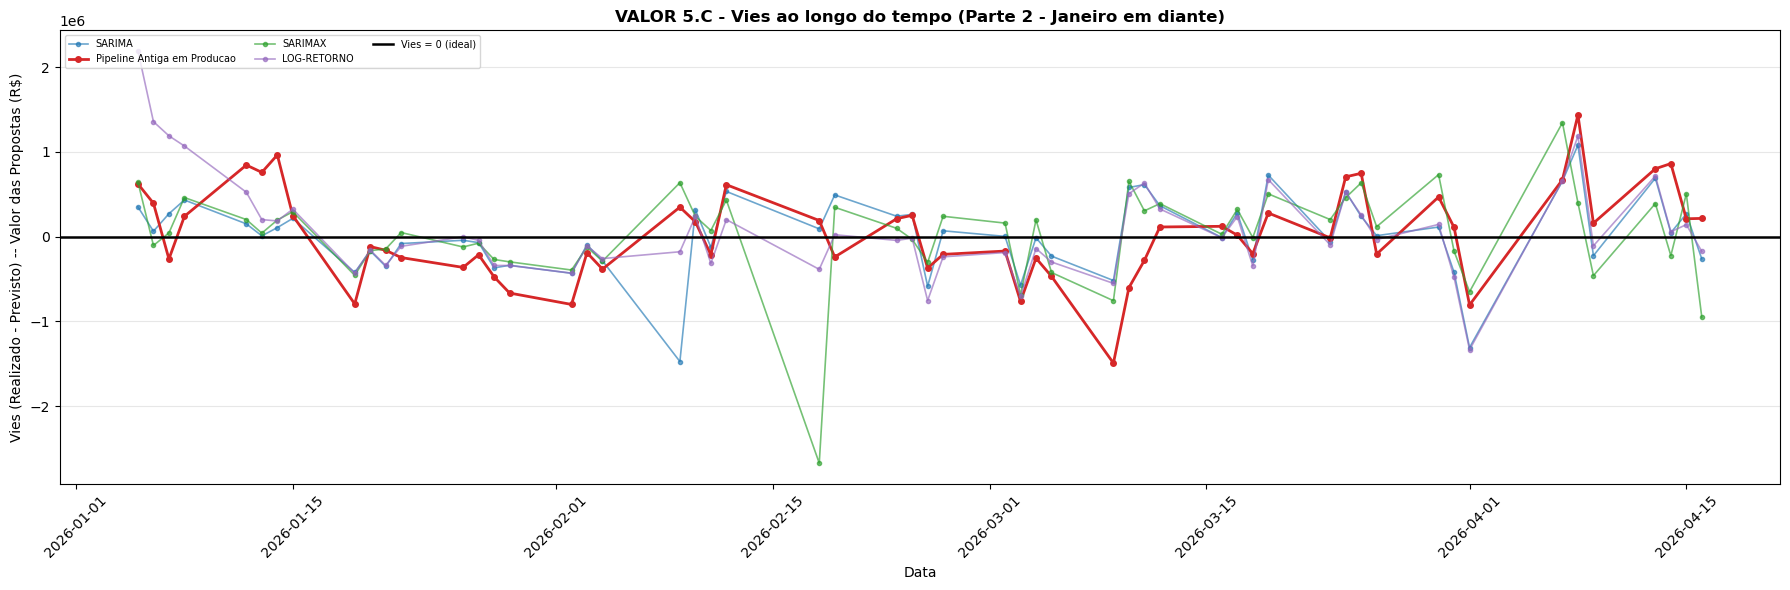


-- Metricas do periodo -- Parte 2 - Janeiro em diante:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMA,6.25,8.54,0.17,18521.20,18521.20,-0.15,337065.90,453401.00,8.29,5.02,0.04,30.52,27/55,44/55,55
1,Pipeline Antiga em Producao,8.02,10.22,-0.17,31979.40,31979.40,-0.19,431733.90,538563.10,9.85,5.17,0.29,34.90,27/55,36/55,55
2,SARIMAX,7.09,10.30,-0.26,27161.10,27161.10,0.07,384007.80,556913.30,10.19,5.84,0.24,48.82,25/55,44/55,55
3,LOG-RETORNO,7.61,10.83,-0.37,82480.20,82480.20,0.91,409994.80,576288.30,10.54,5.58,0.06,38.99,26/55,42/55,55



### VALOR 5.C | Parte 3 - Recorte de marco


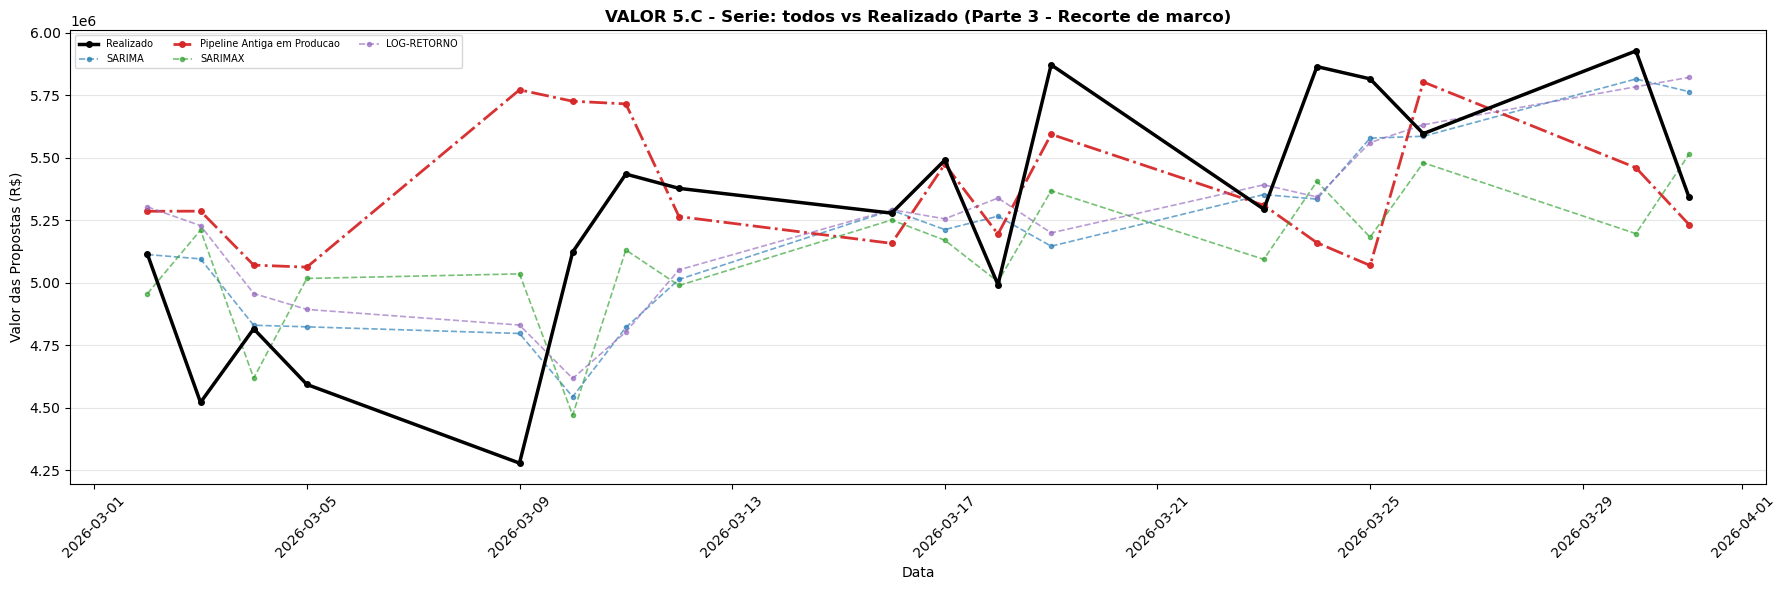

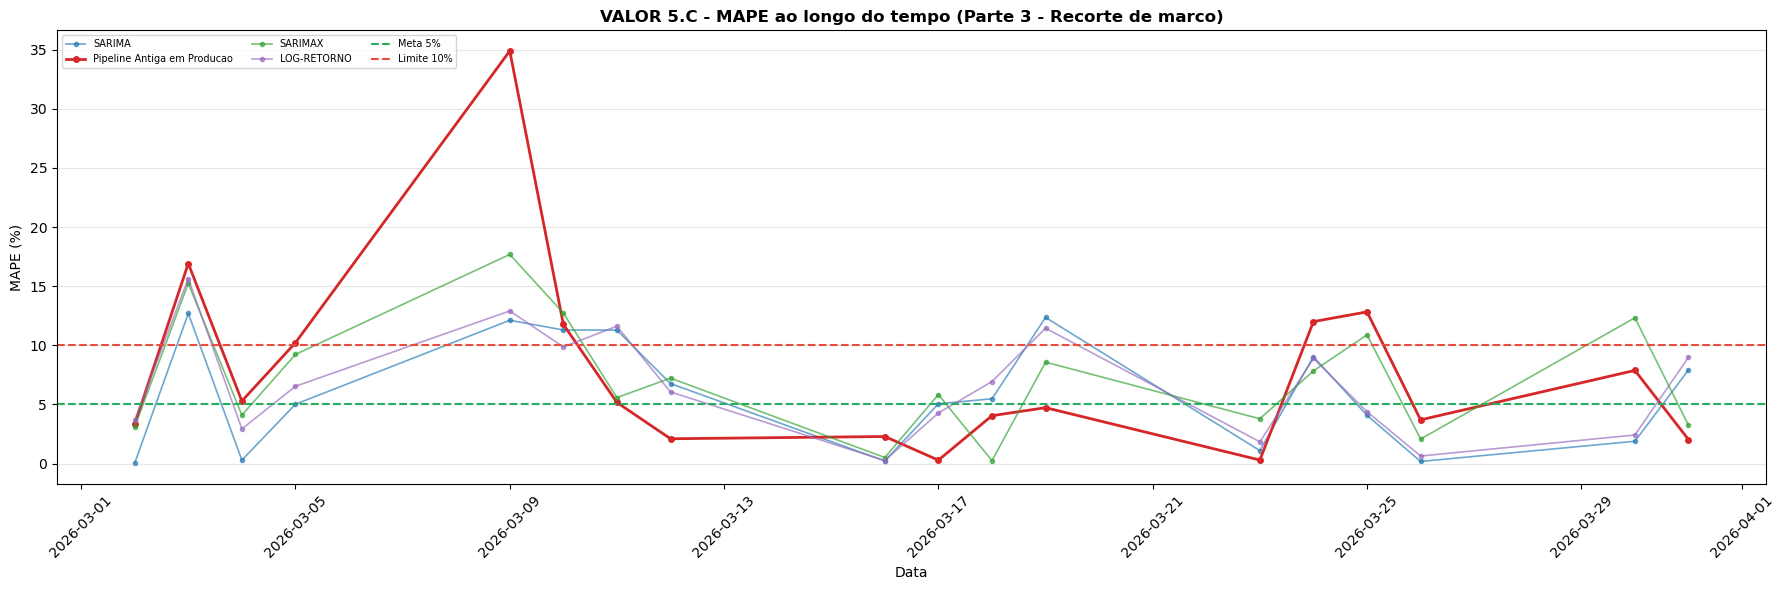

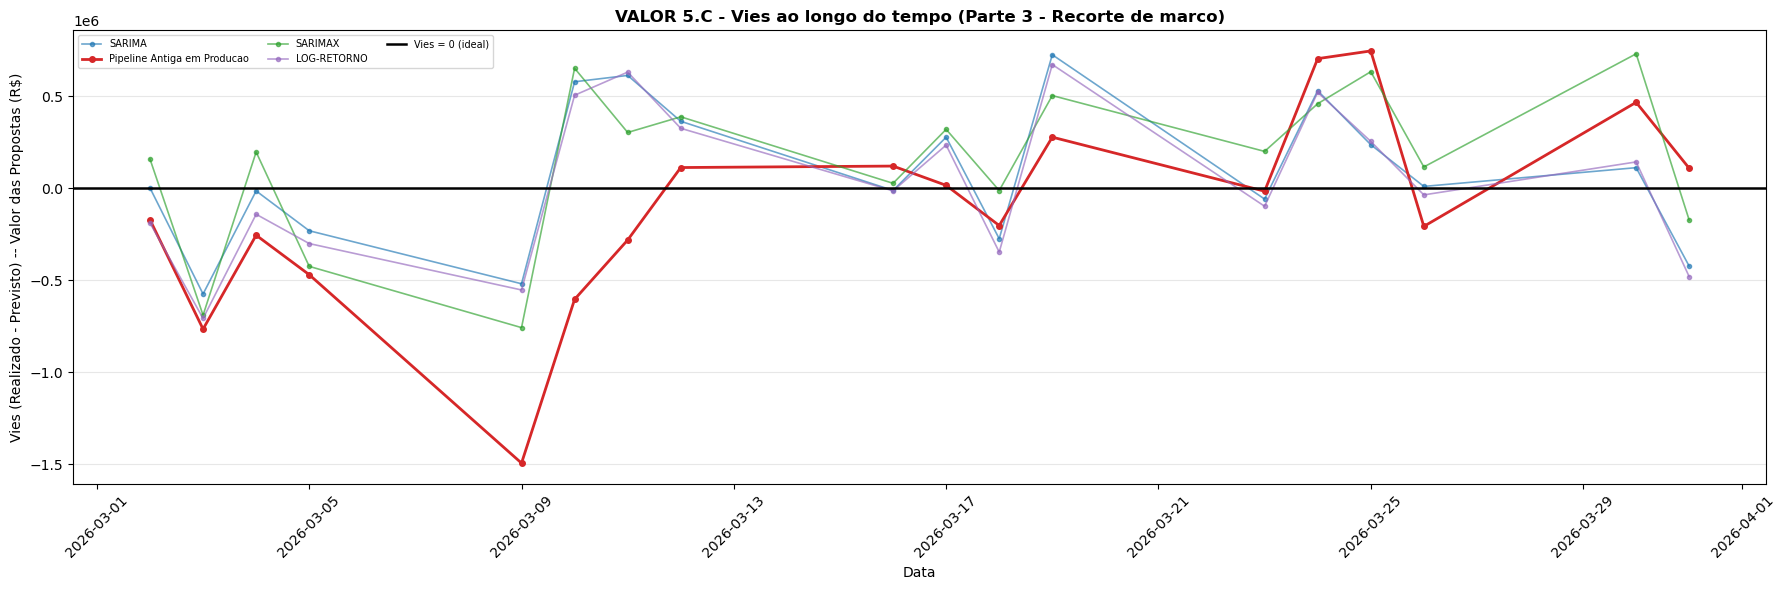


-- Metricas do periodo -- Parte 3 - Recorte de marco:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMA,5.94,7.49,0.32,74839.60,74839.60,0.95,308706.10,380553.50,7.23,5.27,0.04,12.70,7/18,13/18,18
1,Pipeline Antiga em Producao,7.77,11.18,-0.27,-105978.80,105978.80,-2.86,389851.20,518702.30,9.86,4.95,0.29,34.90,9/18,12/18,18
2,SARIMAX,7.24,8.73,0.11,146518.00,146518.00,2.16,374916.50,419162.10,7.96,6.54,0.24,17.69,7/18,13/18,18
3,LOG-RETORNO,6.63,7.93,0.26,23738.70,23738.70,-0.08,341880.80,403324.00,7.66,6.30,0.26,15.64,8/18,14/18,18



### VALOR 5.C | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)


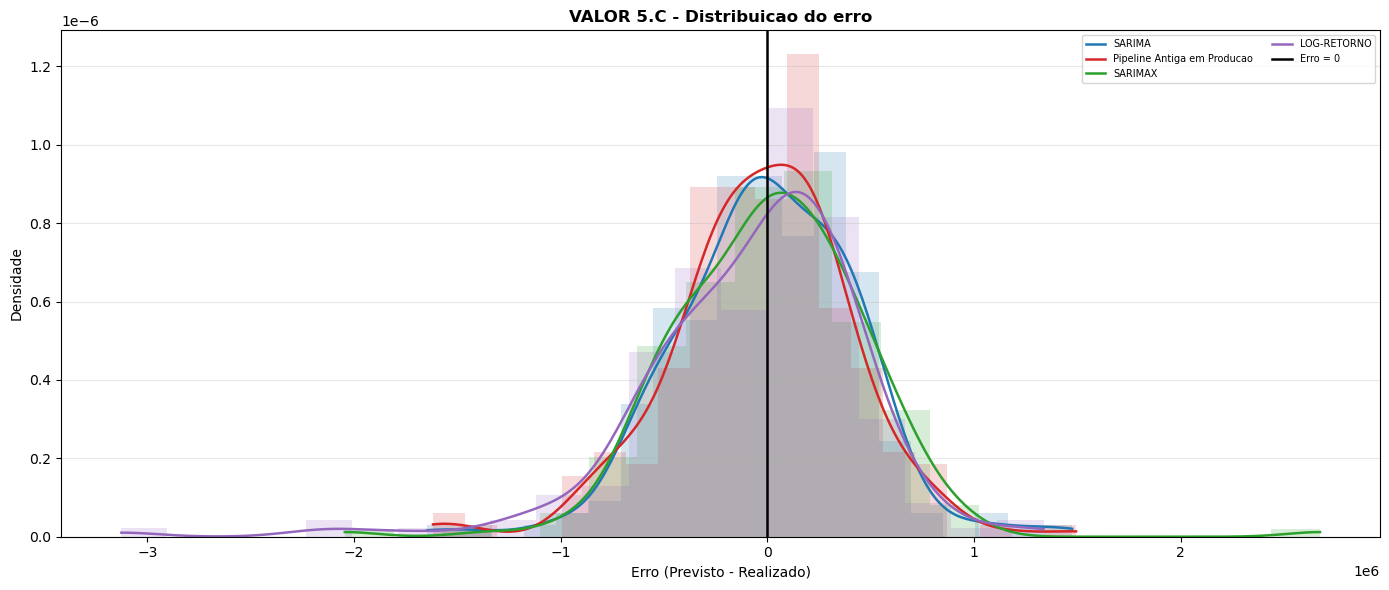

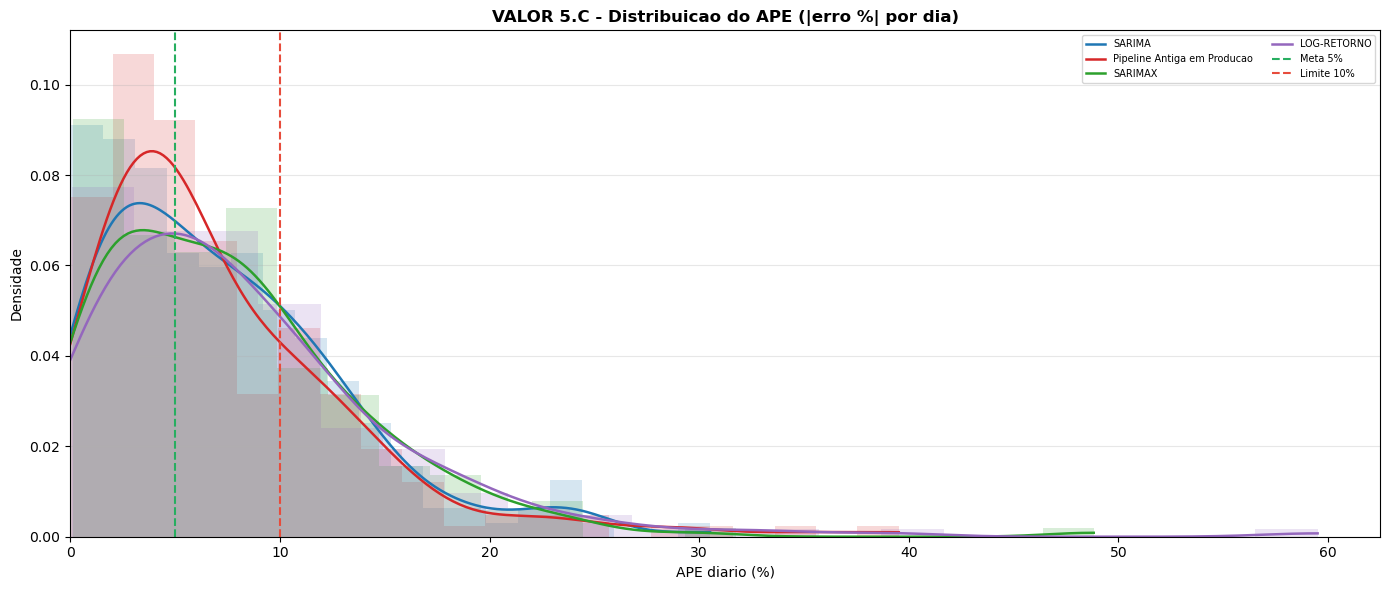

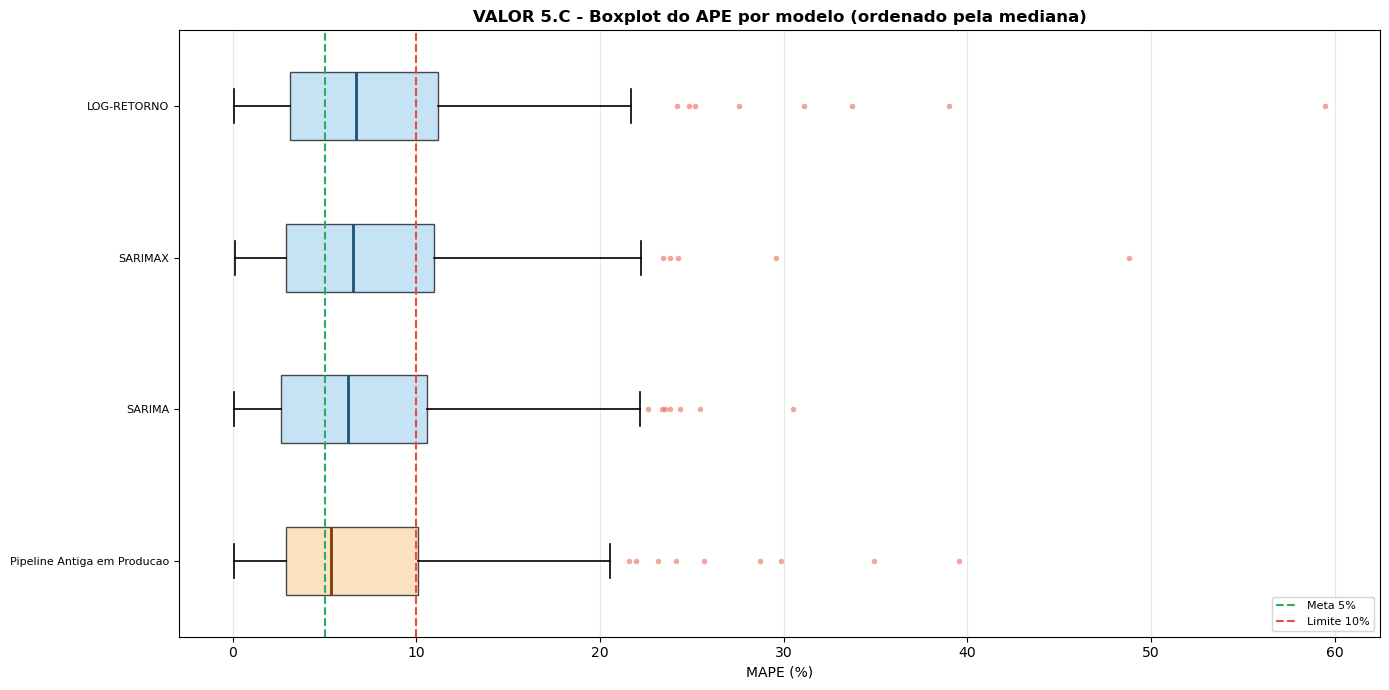

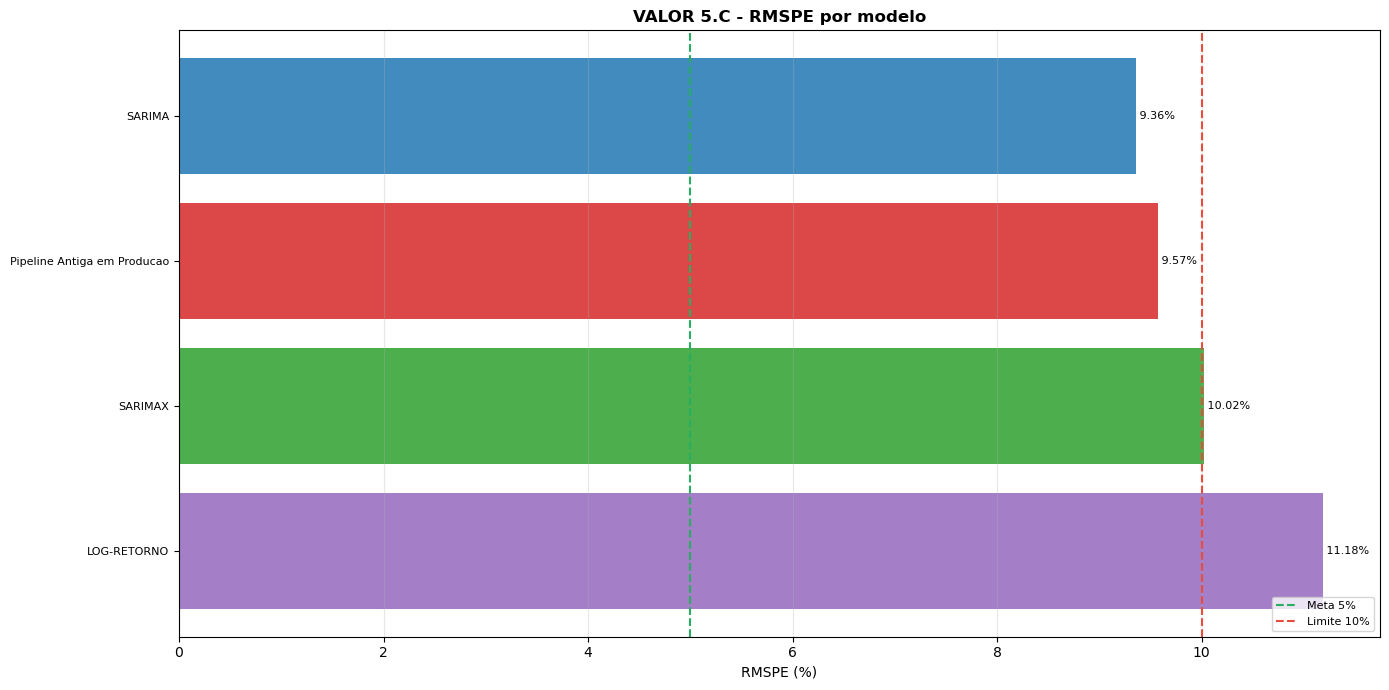

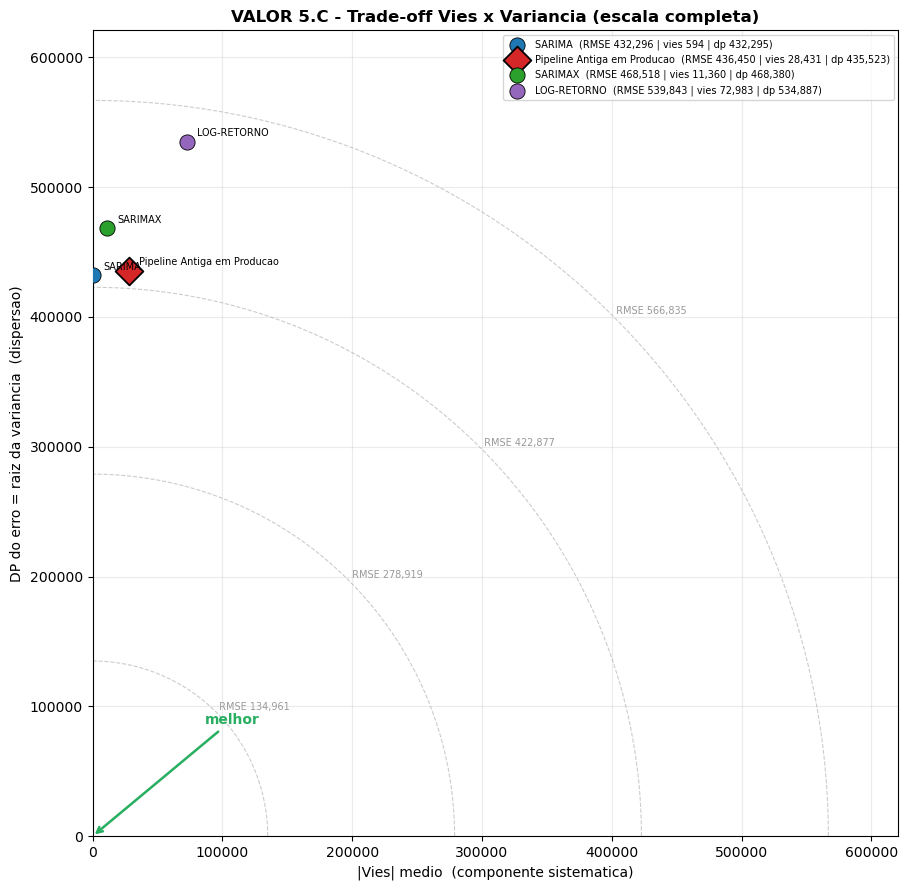

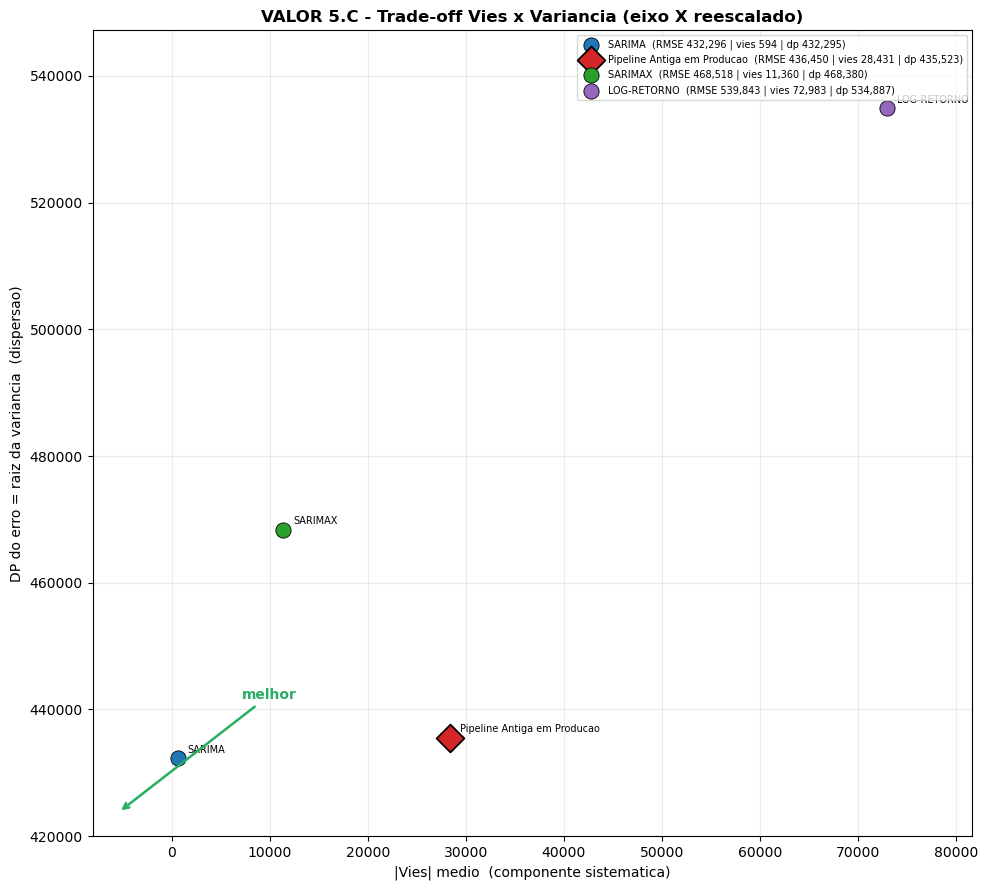

In [20]:
comparar_todos_modelos(_df_db_valor, ranking_valor, 'Valor das Propostas (R$)', titulo='VALOR 5.C')

### 3.C - VALOR: comparacao individual de cada modelo (estilo 5.D)

In [21]:
# ===== Replica 5.D para a area VALOR =====
_df_db          = _df_db_valor.copy()
df_ranking_int  = ranking_valor.copy()
df_ranking_orig = None
_UNID           = 'Valor das Propostas (R$)'



#### SARIMAX


### 5.D - SARIMAX | Parte 1 - Historico completo


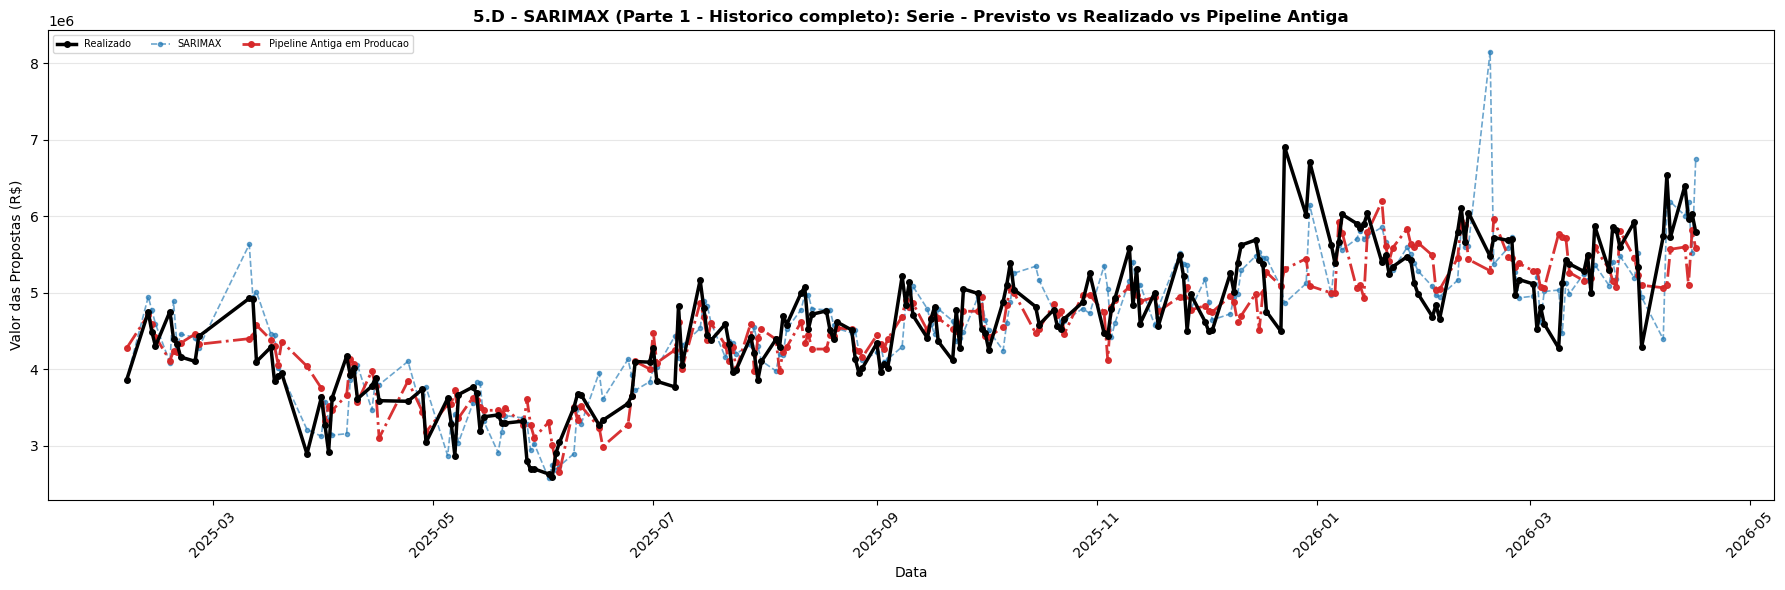

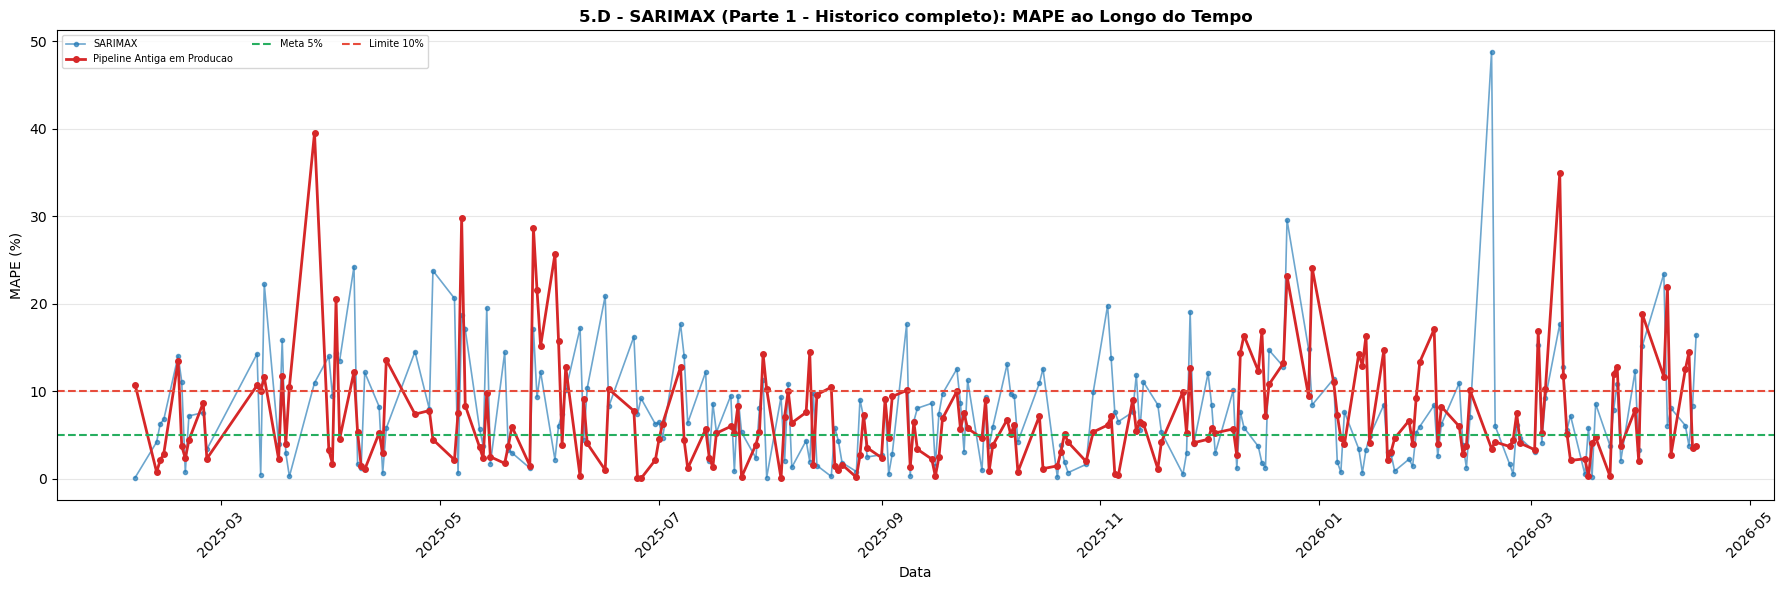

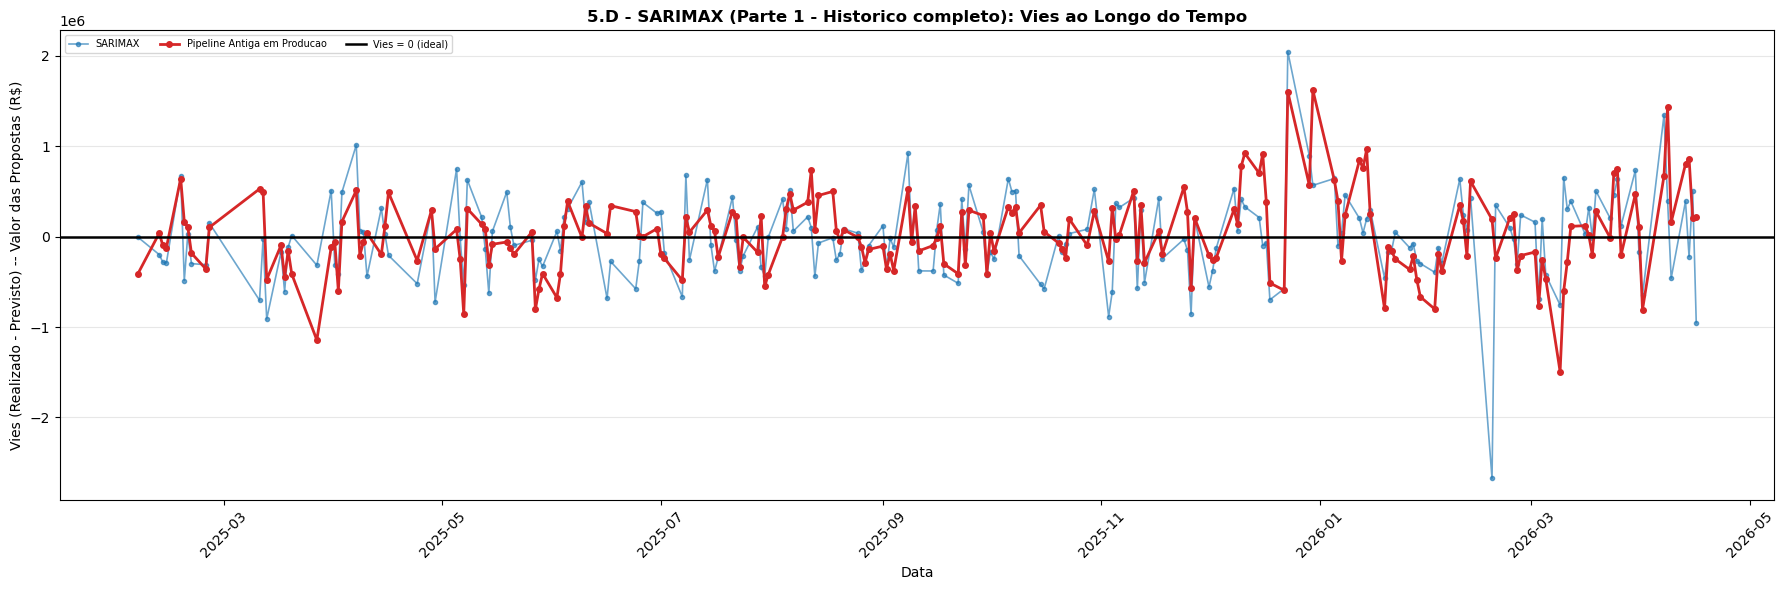


-- Metricas do periodo -- Parte 1 - Historico completo:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,7.72,10.02,0.71,-11360.50,11360.50,-0.86,349873.80,468379.90,10.15,6.54,0.13,48.82,81/209,151/209,209
1,Pipeline Antiga em Producao,7.23,9.57,0.74,28430.70,28430.70,-0.33,330061.50,435522.70,9.44,5.35,0.05,39.52,95/209,154/209,209



### 5.D - SARIMAX | Parte 2 - Janeiro em diante


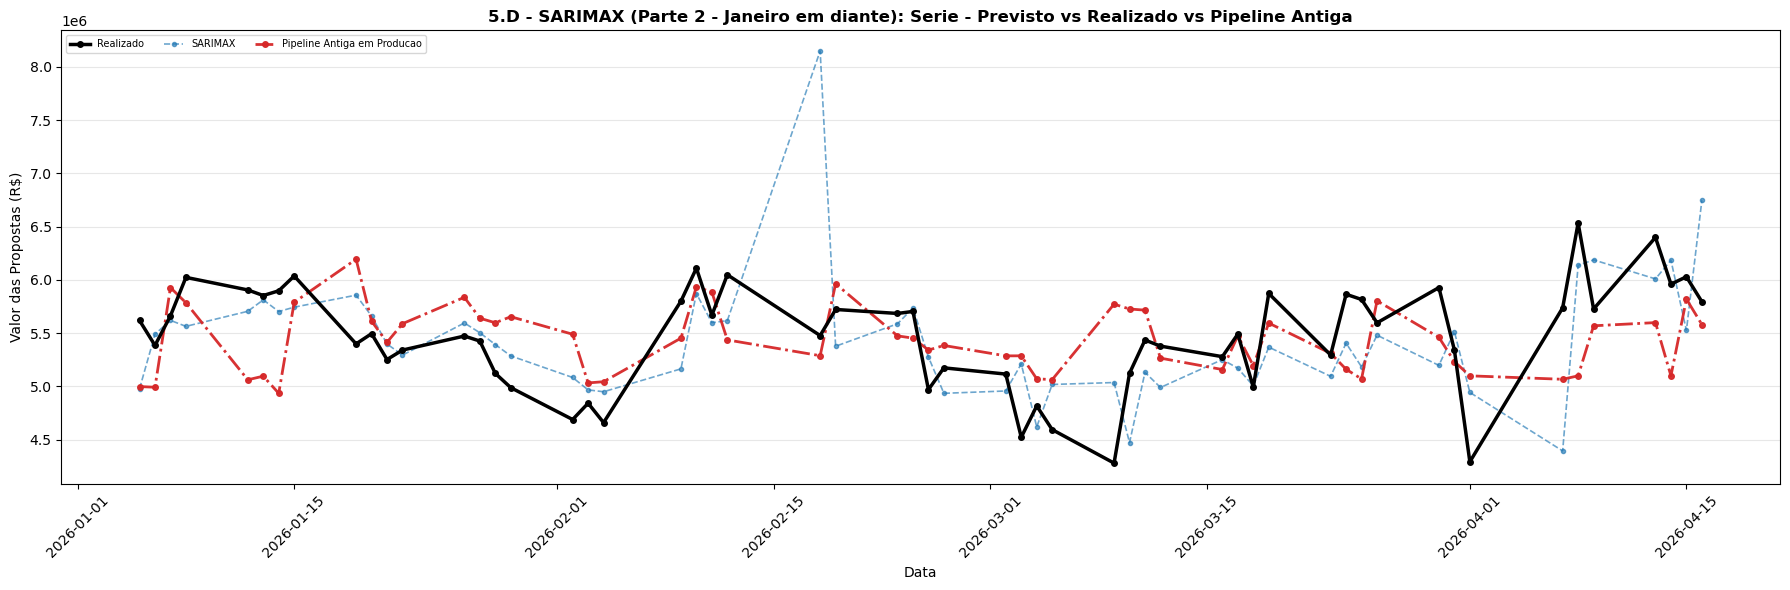

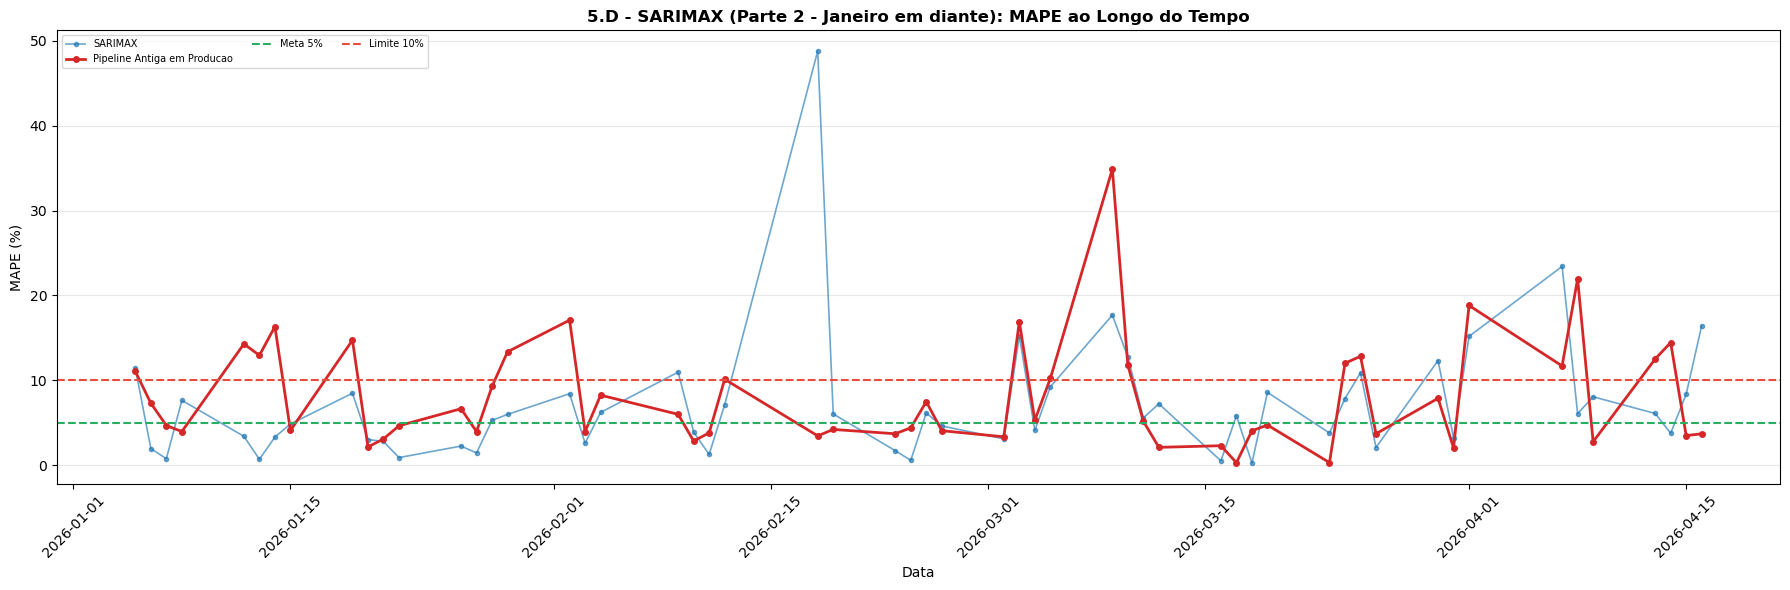

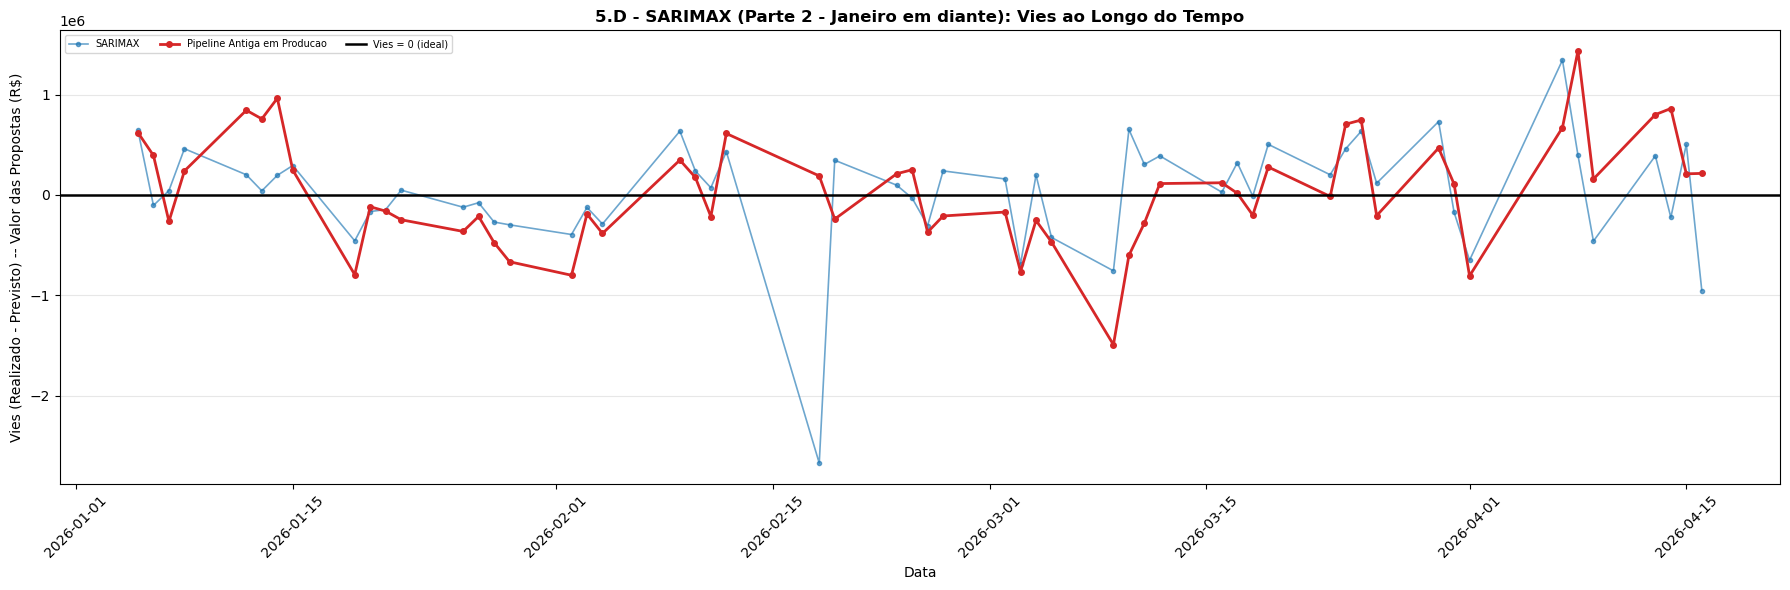


-- Metricas do periodo -- Parte 2 - Janeiro em diante:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,7.09,10.30,-0.26,27161.10,27161.10,0.07,384007.80,556913.30,10.19,5.84,0.24,48.82,25/55,44/55,55
1,Pipeline Antiga em Producao,8.02,10.22,-0.17,31979.40,31979.40,-0.19,431733.90,538563.10,9.85,5.17,0.29,34.90,27/55,36/55,55



### 5.D - SARIMAX | Parte 3 - Recorte de marco


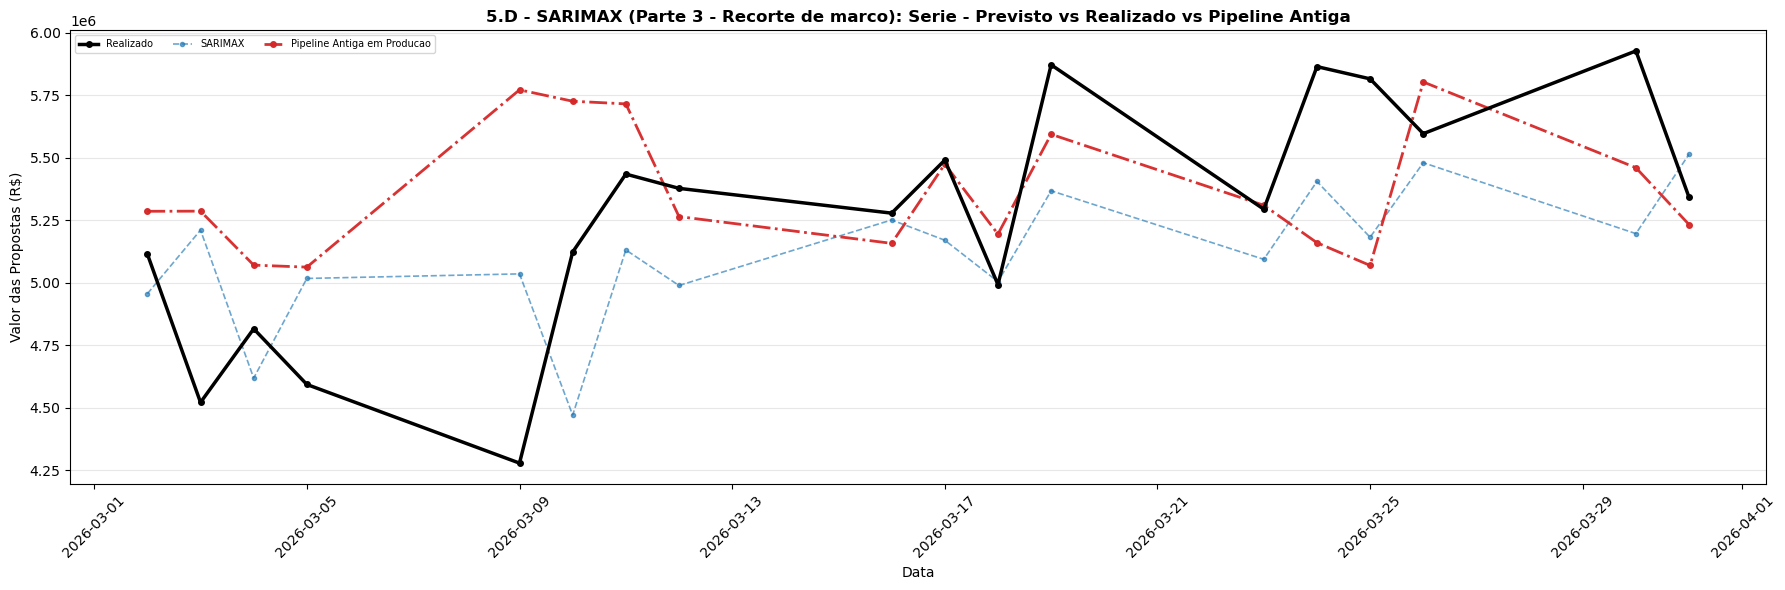

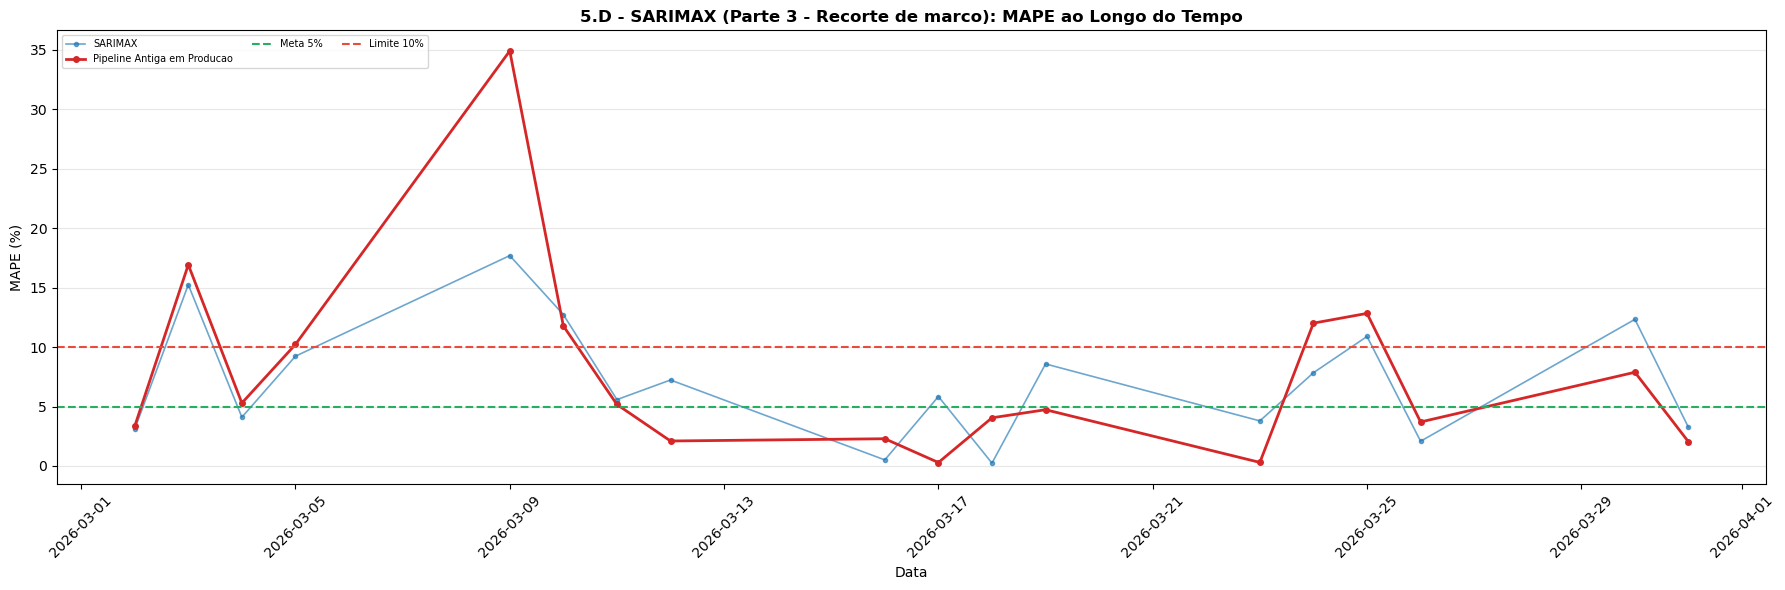

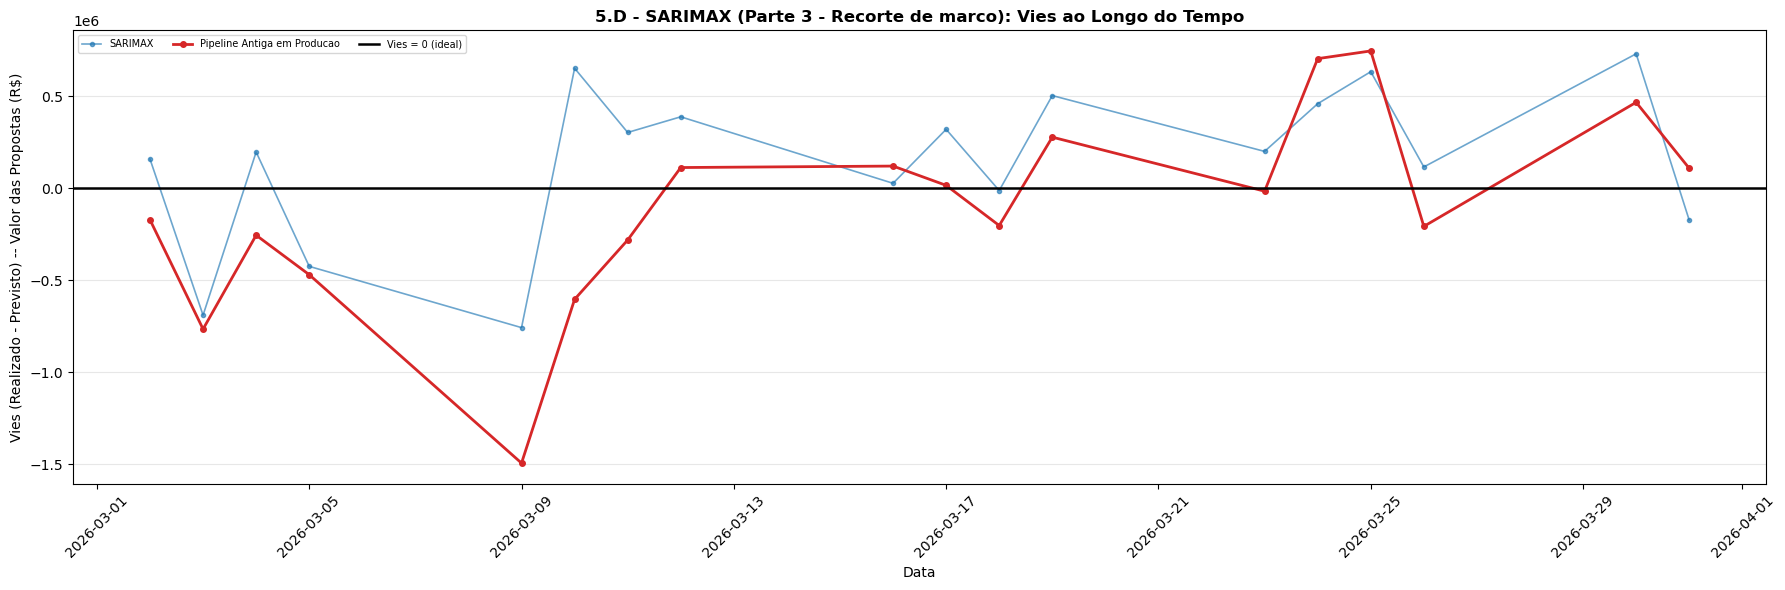


-- Metricas do periodo -- Parte 3 - Recorte de marco:


,Modelo,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,7.24,8.73,0.11,146518.00,146518.00,2.16,374916.50,419162.10,7.96,6.54,0.24,17.69,7/18,13/18,18
1,Pipeline Antiga em Producao,7.77,11.18,-0.27,-105978.80,105978.80,-2.86,389851.20,518702.30,9.86,4.95,0.29,34.90,9/18,12/18,18



### 5.D - SARIMAX | Parte 4 - Distribuicoes, RMSPE e trade-off (base completa)


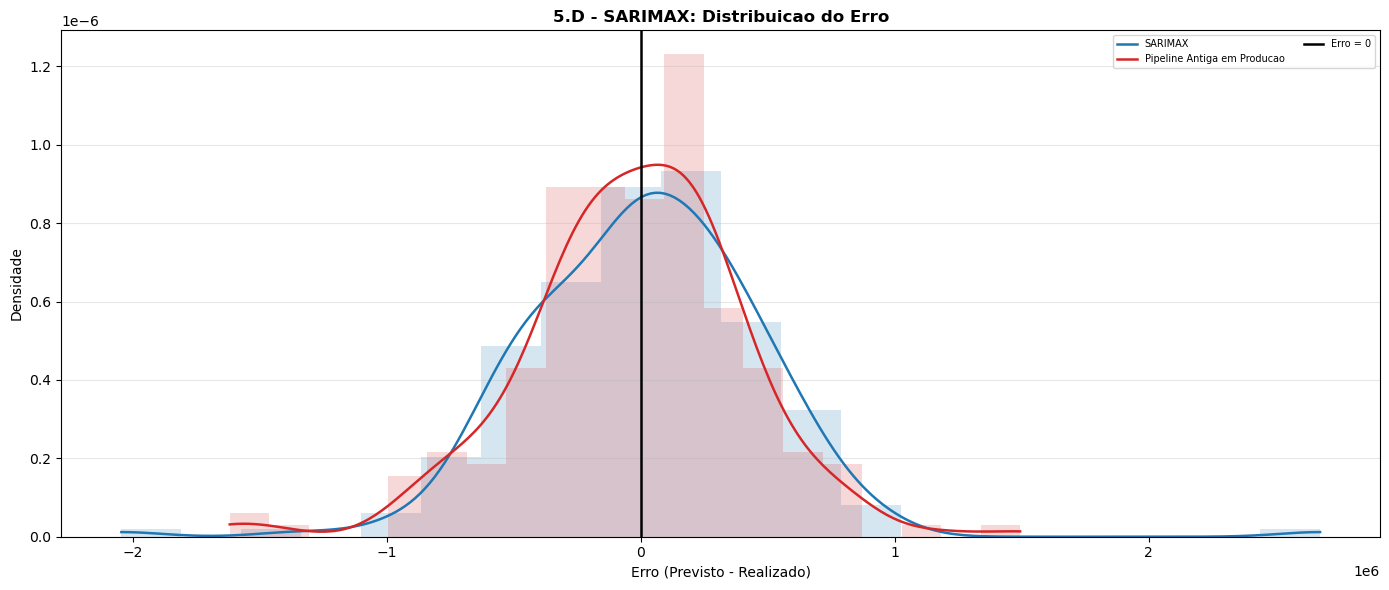

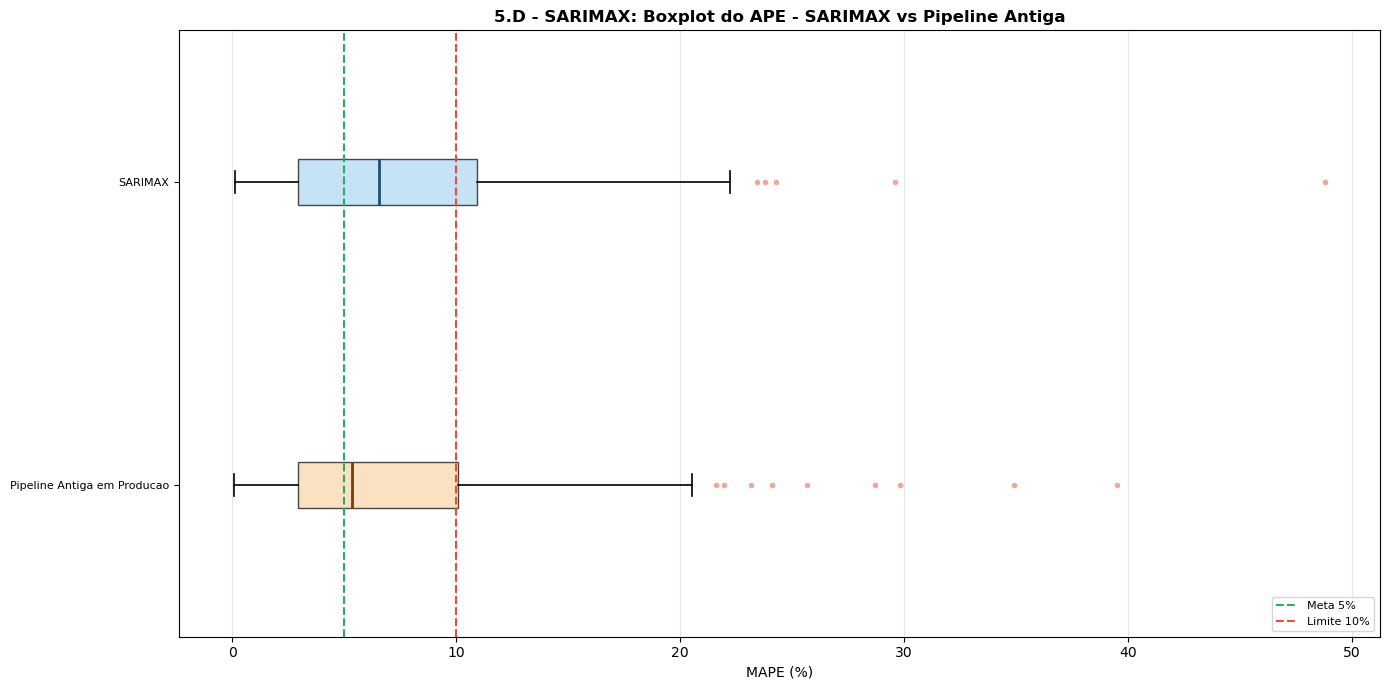

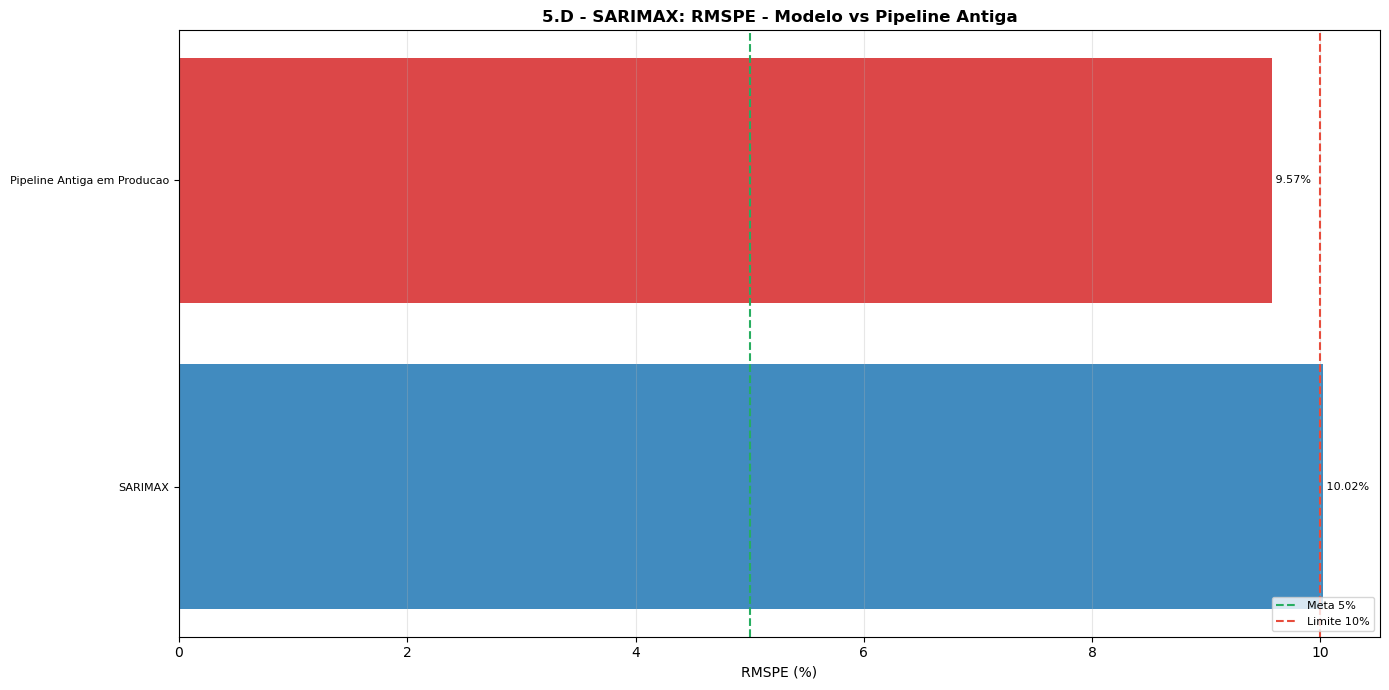

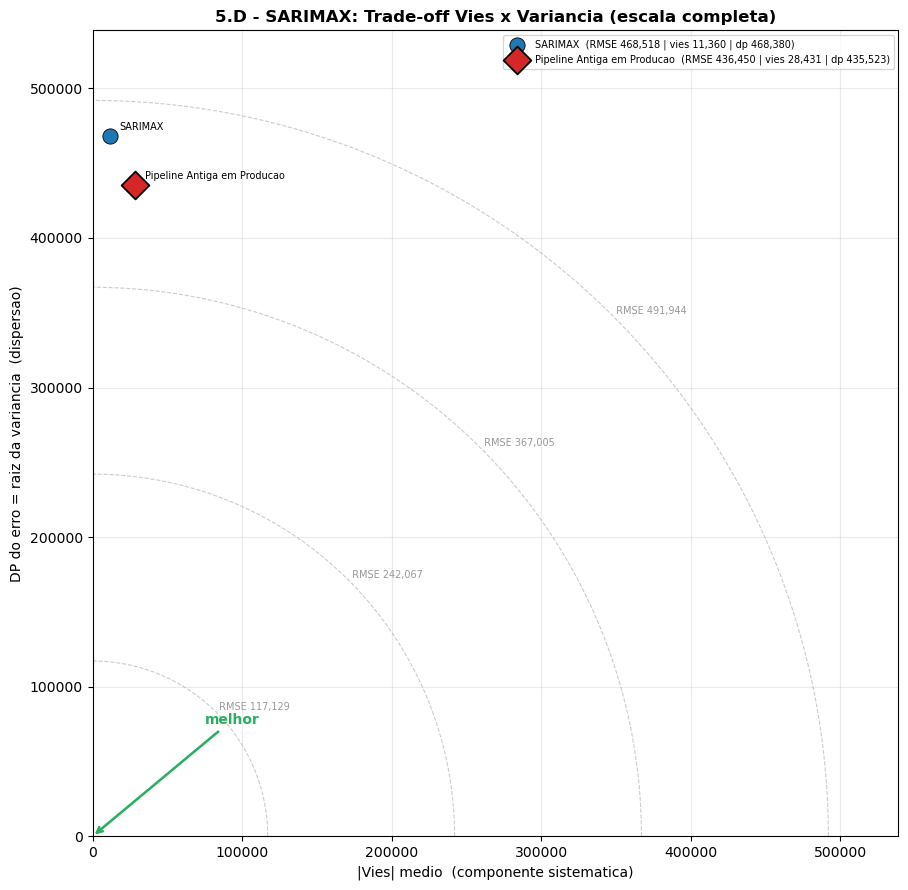


-- Metricas por mes -- SARIMAX:


,Modelo,Mes,MAPE Medio (%),RMSPE (%),R2,Vies (real-prev),|Vies|,Vies % (MPE),MAE,DP Erro,CV Erro (%),Mediana (%),Min (%),Max (%),< 5%,< 10%,N
0,SARIMAX,2025-02,6.14,7.38,-0.59,-102637.10,102637.10,-2.51,272684.00,315140.80,7.23,6.54,0.13,14.05,4/10,8/10,10
1,SARIMAX,2025-03,9.45,11.97,0.34,-259388.60,259388.60,-6.28,374831.10,407665.70,10.06,10.97,0.27,22.24,4/9,4/9,9
2,SARIMAX,2025-04,10.59,12.89,-0.71,-28179.20,28179.20,-1.73,375028.40,460047.10,12.68,9.46,0.65,24.26,3/13,7/13,13
3,SARIMAX,2025-05,9.89,12.27,-0.33,-18374.30,18374.30,-1.51,318036.70,396832.50,12.14,9.35,0.61,20.62,6/15,8/15,15
4,SARIMAX,2025-06,9.70,10.99,0.34,30239.50,30239.50,0.63,332660.00,377259.50,11.14,8.27,2.18,20.89,2/13,8/13,13
5,SARIMAX,2025-07,7.32,8.67,0.01,-64581.90,64581.90,-2.07,314776.70,368688.40,8.58,6.46,0.15,17.67,5/17,13/17,17
6,SARIMAX,2025-08,4.55,5.74,0.30,-13775.30,13775.30,-0.48,202686.00,254717.00,5.64,3.40,0.27,10.87,10/16,15/16,16
7,SARIMAX,2025-09,6.72,8.17,0.00,3898.60,3898.60,-0.41,311318.20,385932.60,8.44,7.76,0.31,17.67,7/18,15/18,18
8,SARIMAX,2025-10,6.28,7.65,-0.51,20709.50,20709.50,0.11,306107.60,375429.80,7.82,5.07,0.19,13.10,7/14,11/14,14
9,SARIMAX,2025-11,8.87,10.43,-0.74,-131050.70,131050.70,-3.19,420846.90,466806.30,9.51,7.64,0.53,19.80,3/14,9/14,14


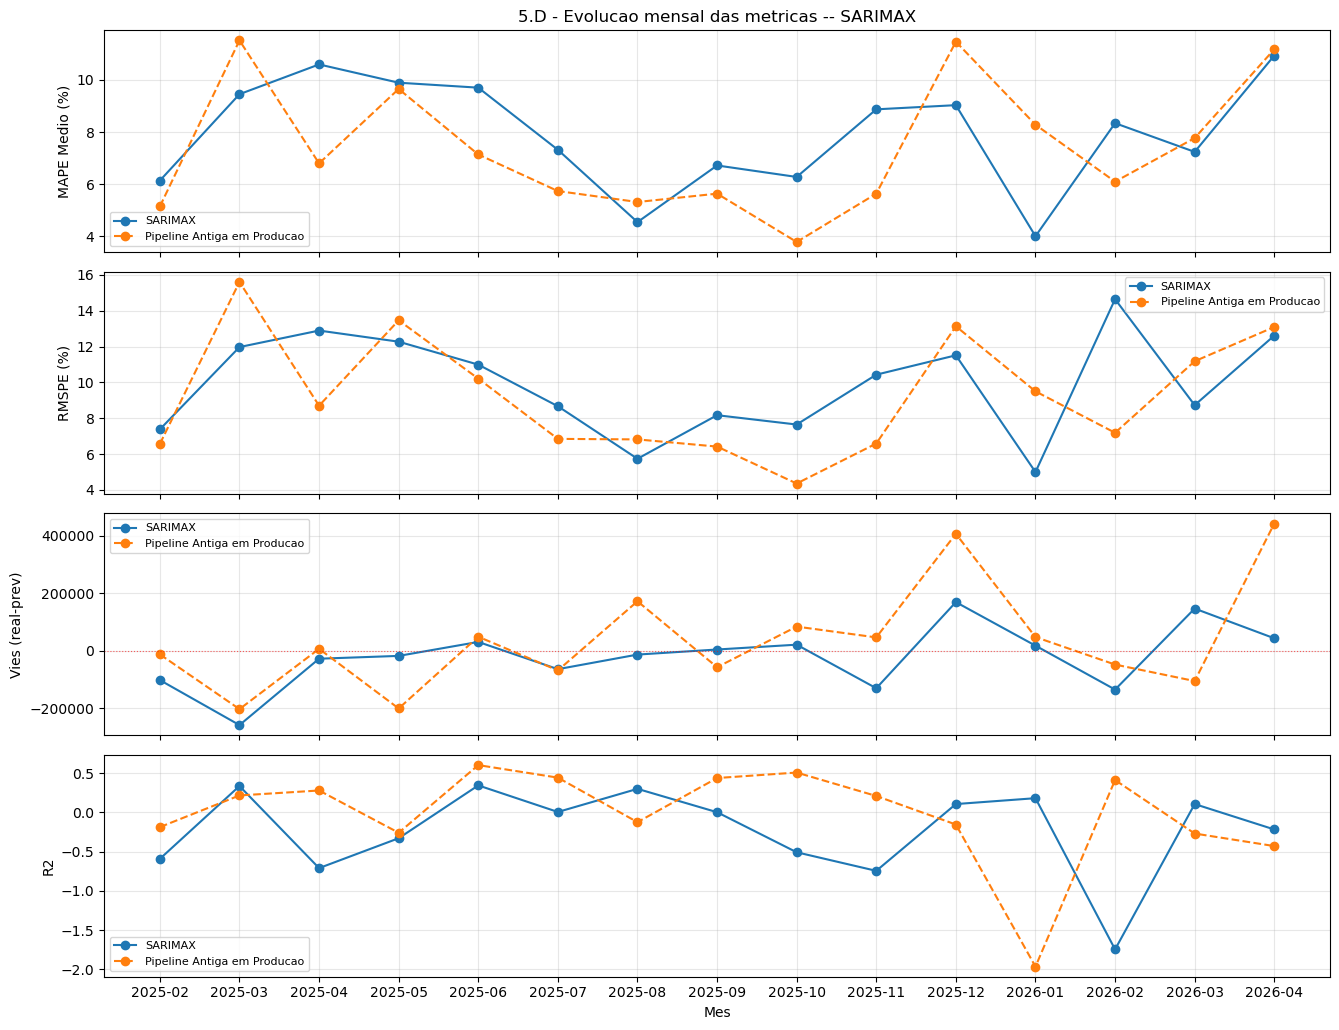

COMPARATIVO  |  SARIMAX   vs   Pipeline Antiga em Producao
Metrica                     Modelo   Pipeline Antiga         Delta   Resultado
------------------------------------------------------------------------------------
MAPE Medio (%)                7.72              7.23         +0.49   pior
RMSPE (%)                    10.02              9.57         +0.45   pior
R2                           0.706             0.745         -0.04   pior
Vies (real-prev)          -11360.5           28430.7     -39791.20   
|Vies|                     11360.5           28430.7     -17070.20   melhor
MAE                       349873.8          330061.5     +19812.30   pior
DP Erro                   468379.9          435522.7     +32857.20   pior
Mediana (%)                   6.54              5.35         +1.19   pior
N                            209.0             209.0         +0.00   


In [22]:
comparar_modelo('SARIMAX')

#### SARIMA

In [23]:
# comparar_modelo('SARIMA')

## 4 - AREA QUANTIDADE

### 4.A Estimação

Ordem (auto_arima, univariado): SARIMA(0, 1, 1) x (0, 0, 2, 5)  | AIC=5956.5
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8216      0.032    -25.352      0.000      -0.885      -0.758
ma.S.L5       -0.0977      0.048     -2.041      0.041      -0.192      -0.004
ma.S.L10      -0.0687      0.058     -1.180      0.238      -0.183       0.045
sigma2        1.1e+05   5137.310     21.419      0.000       1e+05     1.2e+05


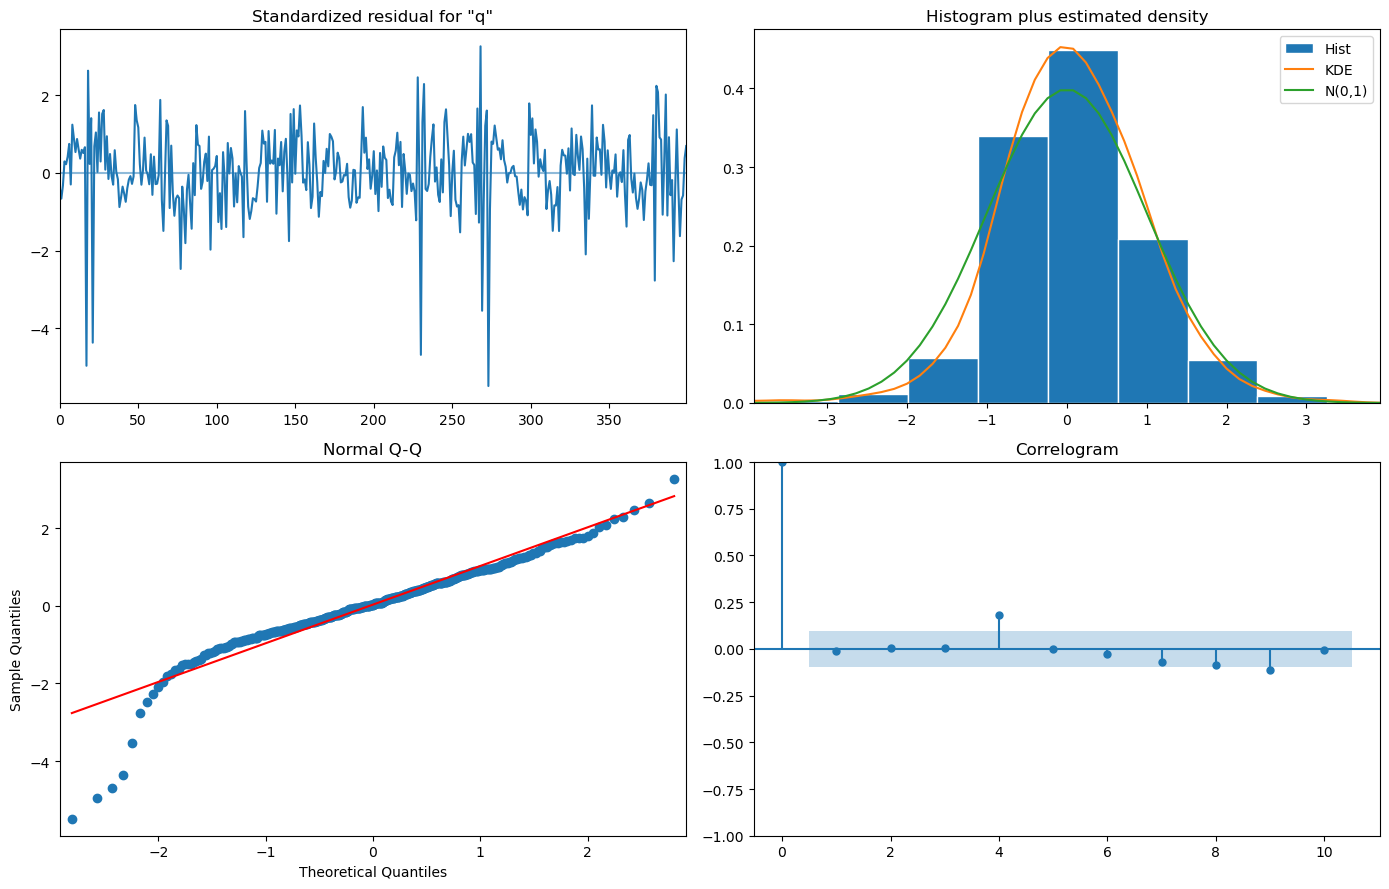

Ljung-Box (H0 = residuos sem autocorrelacao):
    lb_stat  lb_pvalue
10    22.16       0.01
20    42.98       0.00


In [24]:
order_q, seas_q, aic_q = selecionar_ordem(serie_q)
print(f'Ordem (auto_arima, univariado): SARIMA{order_q} x {seas_q}  | AIC={aic_q:.1f}')
res_q = ajustar_sarimax(serie_q, order_q, seas_q, None)
print(res_q.summary().tables[1])
try:
    res_q.plot_diagnostics(figsize=(14, 9)); plt.tight_layout(); plt.show()
except Exception as e:
    print('diagnostics:', e)
print('Ljung-Box (H0 = residuos sem autocorrelacao):')
print(acorr_ljungbox(res_q.resid, lags=[10, 20], return_df=True))

### Analise de intervencao (efeito por evento + residuo pre/pos)

Efeito dos **dias especiais** (eventos do `Log_Erro` e vesperas de feriado) sobre a serie de
quantidade, via **regressores de intervencao** (Box-Tiao) ja montados acima. Cada evento e
classificado em **abrupto** (efeito transitorio, constante nos dias de impacto) ou **gradual**
(efeito decaindo ao longo da janela de impacto), escolhendo por significancia (p<0.05) e menor
AIC; sem efeito significativo -> `nao signif.`. Abaixo: tabela por evento, barra de efeito
(SARIMAX) e comparacao do **residuo PRE x POS** intervencao (ajuste SARIMA univariado).

=== Analise classica: Quantidade de Propostas | n=413 | 2024-11-08 -> 2026-07-06 ===


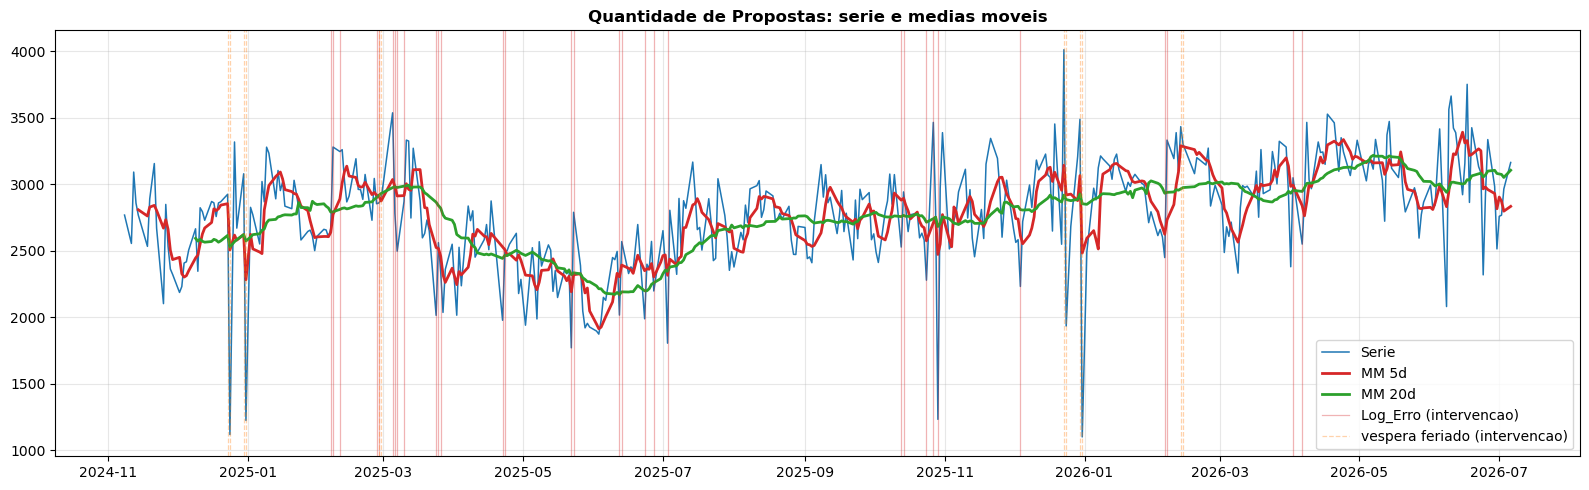

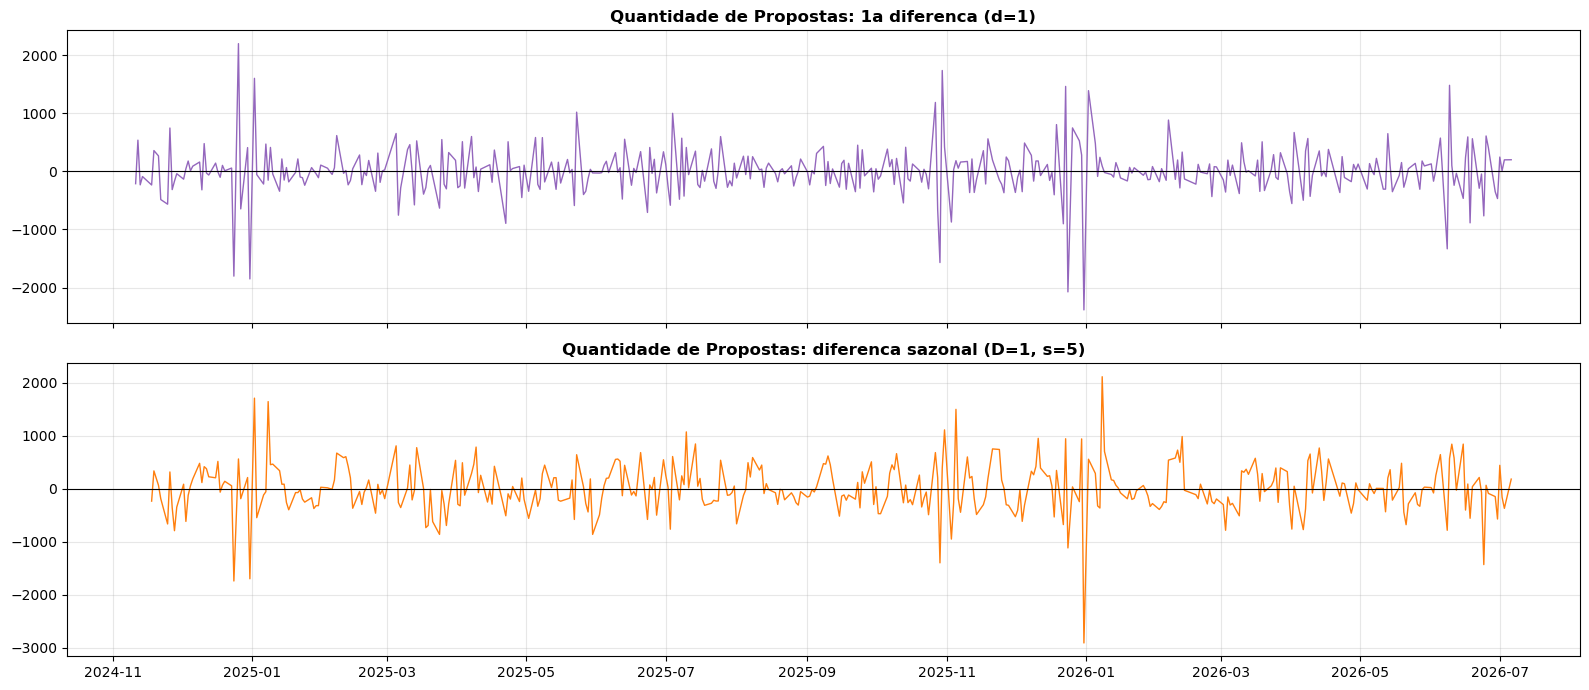

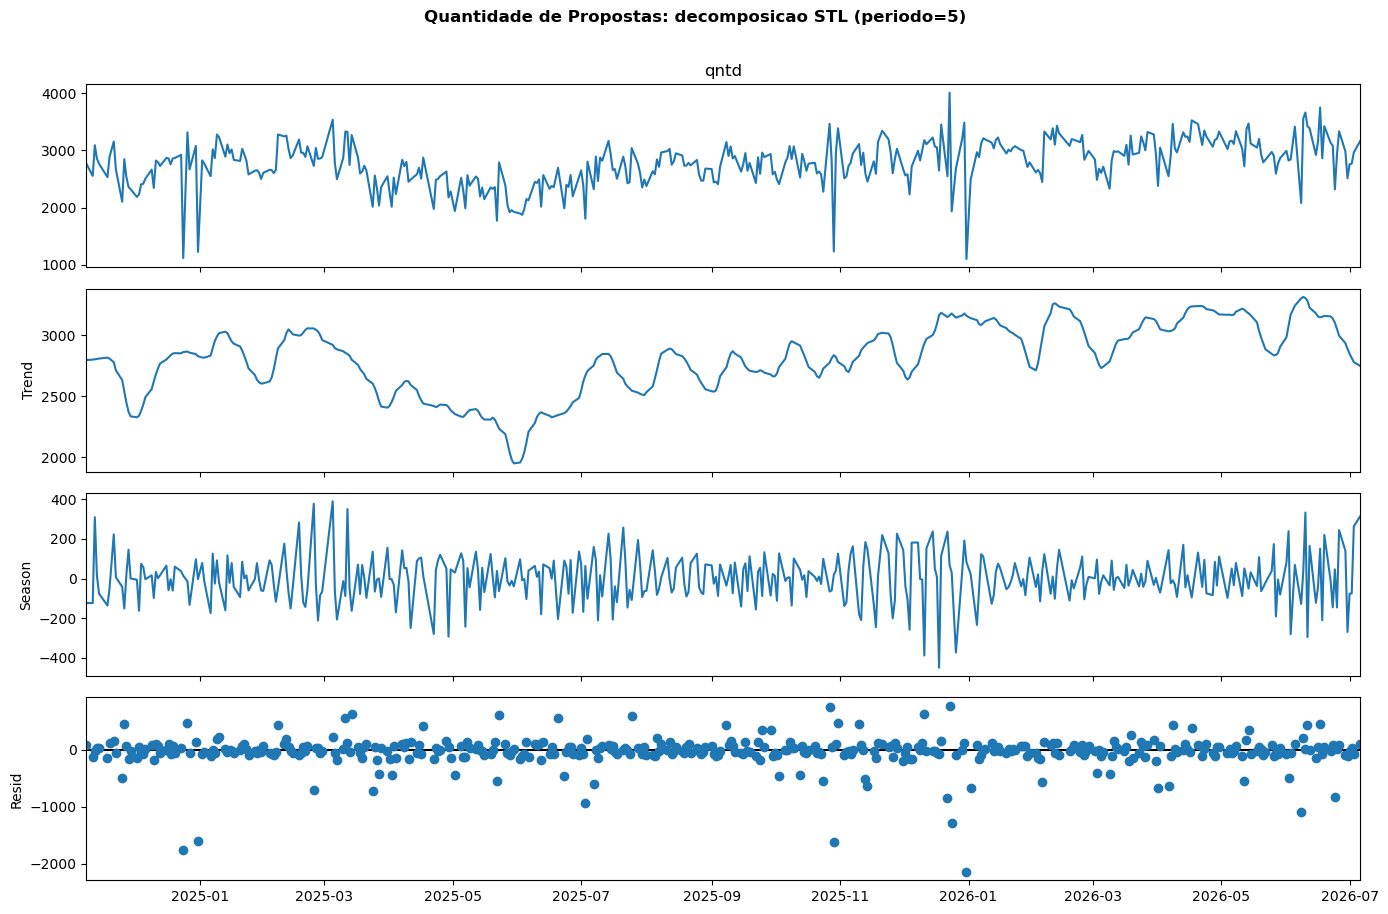

Estacionariedade (ADF H0=raiz unitaria | KPSS H0=estacionaria) -- ADF bruto x ajustado p/ intervencao (42 dias atipicos: Log_Erro + vespera Natal/AnoNovo/Carnaval):
  nivel              ADF bruto p=0.5305 (NAO estac.)  |  ADF ajustado p=0.4890 (NAO estac.)  |  KPSS (bruto) p=0.0100 (NAO estac.)
  1a diferenca       ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)
  diff sazonal(5)    ADF bruto p=0.0000 (estacionaria)  |  ADF ajustado p=0.0000 (estacionaria)  |  KPSS (bruto) p=0.1000 (estacionaria)


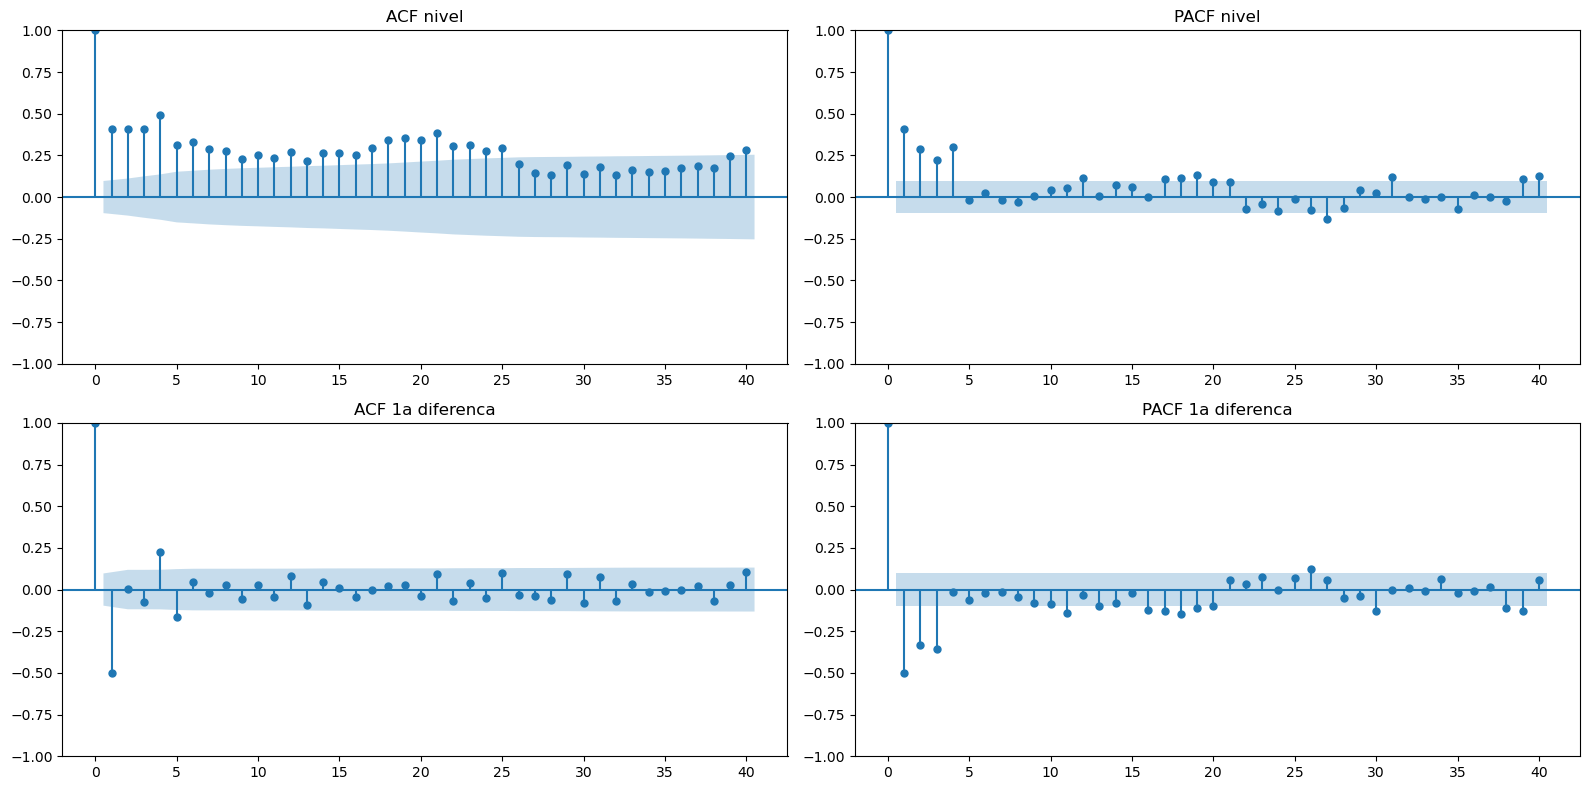

[cache saved] analise_intervencao -> analise_intervencao_c30e1c520ef2fcb5.pkl


In [ ]:
# ===== Analise classica + intervencao -- QUANTIDADE =====
# analise_classifica_intervencao junta: (1) analise classica (medias moveis, STL, ADF/KPSS,
# ACF/PACF), (2) classificacao da intervencao por evento -- SARIMA e SARIMAX -- + onde cada
# uma cai no historico, e (3) residuo PRE (sem intervencao) x POS (com intervencao). As
# matrizes X_int_* seguem sendo usadas na avaliacao (Secao 4) e na correcao de vies.
resultado_q = analise_classifica_intervencao(serie_q, order_q, seas_q, eventos_q,
                                             nome='Quantidade de Propostas', exog=exog_q, res_pre=res_q)
interv_sarima_q,  classes_sarima_q,  X_int_sarima_q  = (resultado_q['interv_sarima'],
                                                        resultado_q['classes_sarima'], resultado_q['X_int_sarima'])
interv_sarimax_q, classes_sarimax_q, X_int_sarimax_q = (resultado_q['interv_sarimax'],
                                                        resultado_q['classes_sarimax'], resultado_q['X_int_sarimax'])

In [ ]:
_df_db_qtd, ranking_qtd = avaliar_area(
    'qntd', serie_q, exog_q, order_q, seas_q,
    'resultados/backup_qtd.xlsx', 'Data previsao', dfull_q,
    exog_int_u=X_int_sarima_q, exog_int_x=X_int_sarimax_q,
    eventos=eventos_q, interv_lr=interv_sarima_q)   # inclui LOG-RETORNO no ranking
print('\nRanking QUANTIDADE (ordenado por RMSPE):')
display(_com_modelo(ranking_qtd))

#### Export das predicoes (p/ import no `experimento_qtd`, Secao 4.A)

In [ ]:
# ==================== EXPORT: predicoes SARIMA (quantidade) ====================
# Usado pela Secao 4.A do experimento_qtd.ipynb para comparar o SARIMA (univariado)
# com os modelos de ML nas mesmas condicoes (mesma base comum de datas + remocao de
# Log_Erro/vesperas ja feita la). So a previsao crua e exportada (sem debias).
_export_q = _df_db_qtd[_df_db_qtd['Modelo'] == 'SARIMA'][
    ['Dia Prevista', 'Valor Previsto', 'Valor Realizado']
].dropna().sort_values('Dia Prevista').reset_index(drop=True)
_export_q.insert(0, 'Modelo', 'SARIMA')
os.makedirs('resultados', exist_ok=True)
_export_q.to_pickle(r'resultados\sarima_qtd_predicoes.pkl')
print(f'[export] SARIMA (qtd) -> resultados/sarima_qtd_predicoes.pkl | '
      f'{len(_export_q)} previsoes | '
      f'{_export_q["Dia Prevista"].min().date()} -> {_export_q["Dia Prevista"].max().date()}')


### 4.B - QTD: comparacao de todos os modelos (estilo 5.C)

In [ ]:
comparar_todos_modelos(_df_db_qtd, ranking_qtd, 'Quantidade de Propostas', titulo='QTD 5.C')

### 4.C - QTD: comparacao individual de cada modelo (estilo 5.D)

In [ ]:
# ===== Replica 5.D para a area QUANTIDADE =====
_df_db          = _df_db_qtd.copy()
df_ranking_int  = ranking_qtd.copy()
df_ranking_orig = None
_UNID           = 'Quantidade de Propostas'

#### SARIMAX

In [ ]:
comparar_modelo('SARIMAX')

#### SARIMA

In [ ]:
comparar_modelo('SARIMA')

## 5 - Verificacao da adequacao (diagnostico do ajuste)

Verificacao da adequacao **depois** da analise de intervencao (Secoes 3/4), para que os modelos
ja entrem com as intervencoes classificadas. Tres blocos:

- **7.A Univariado + intervencao (estilo 5.D):** reajusta `SARIMA`/`SARIMAX` de cada area
  **incorporando as intervencoes** (pulsos/degraus) como exogenas e roda o diagnostico de
  residuos (`plot_diagnostics` + Ljung-Box). Os modelos univariados passam a levar a
  intervencao em conta.
- **7.B Cointegrado + intervencao (VECM):** previsao conjunta de valor e qtd e diagnostico
  multivariado dos residuos (Ljung-Box por equacao, whiteness e normalidade do sistema, ACF).
- **7.C Pressupostos da cointegracao (Secao 5):** reroda os testes de cointegracao (I(1),
  Johansen, Engle-Granger, estacionariedade do residuo) para identificar/corrigir pressupostos
  da modelagem cointegrada antes de confiar no VECM.

In [ ]:
# ============================================================
# 7 - FUNCOES DE DIAGNOSTICO DA ADEQUACAO
# ============================================================
def diagnostico_ajuste(res, nome='', lags=(10, 20)):
    """Estilo 5.D -- adequacao do ajuste univariado: coeficientes + plot_diagnostics +
       Ljung-Box dos residuos (H0 = residuos sao ruido branco)."""
    print('=' * 84); print(f'DIAGNOSTICO DO AJUSTE -- {nome}'); print('=' * 84)
    try:
        print(res.summary().tables[1])
    except Exception as e:
        print('summary:', e)
    try:
        res.plot_diagnostics(figsize=(14, 9)); plt.tight_layout(); plt.show()
    except Exception as e:
        print('plot_diagnostics:', e)
    try:
        print('Ljung-Box (H0 = residuos sem autocorrelacao):')
        print(acorr_ljungbox(res.resid, lags=list(lags), return_df=True))
    except Exception as e:
        print('Ljung-Box:', e)


def diagnostico_vecm(vecm_res, nomes=('valor', 'qntd'), lags=(10, 20)):
    """Adaptacao multivariada do plot_diagnostics para o VECM (cointegrado + intervencao):
       Ljung-Box por equacao, whiteness/normalidade do sistema e ACF/histograma por serie."""
    resid = np.asarray(vecm_res.resid)
    k = resid.shape[1]
    print('=' * 84); print('DIAGNOSTICO VECM (cointegrado + intervencao)'); print('=' * 84)
    for j in range(k):
        try:
            print(f'[{nomes[j]}] Ljung-Box:')
            print(acorr_ljungbox(resid[:, j], lags=list(lags), return_df=True))
        except Exception as e:
            print(f'[{nomes[j]}] Ljung-Box:', e)
    try:
        wt = vecm_res.test_whiteness(nlags=max(lags))
        print(f'\nWhiteness (Portmanteau, H0 = sem autocorrelacao do sistema): p={wt.pvalue:.4f}')
    except Exception as e:
        print('test_whiteness:', e)
    try:
        nt = vecm_res.test_normality()
        print(f'Normalidade dos residuos (H0 = normal): p={nt.pvalue:.4f}')
    except Exception as e:
        print('test_normality:', e)
    _lg = min(30, len(resid) // 2 - 1)
    fig, axes = plt.subplots(k, 2, figsize=(14, 4 * k)); axes = np.atleast_2d(axes)
    for j in range(k):
        plot_acf(resid[:, j], lags=_lg, ax=axes[j, 0]); axes[j, 0].set_title(f'ACF residuo -- {nomes[j]}')
        axes[j, 1].hist(resid[:, j], bins=25, density=True, color='#1f77b4', alpha=0.7)
        axes[j, 1].axvline(0, color='black', lw=1.0); axes[j, 1].set_title(f'Histograma residuo -- {nomes[j]}')
    plt.tight_layout(); plt.show()

print('Funcoes de diagnostico (adequacao) OK')

In [ ]:
# ----- 7.A  Univariado + intervencao (estilo 5.D, res.plot_diagnostics) -----
# usa o VENCEDOR combinado (classica x transferencia) escolhido em analise_classifica_intervencao,
# nao apenas a classe classica -> o diagnostico reflete as funcoes de transferencia adotadas
classes_v = classes_sarimax_v
classes_q = classes_sarimax_q

# VALOR: SARIMA + intervencao e SARIMAX + intervencao
res_v_int  = ajustar_com_intervencao(serie_v, order_v, seas_v, eventos_v, classes_v, exog=None)
res_vx_int = ajustar_com_intervencao(serie_v, order_v, seas_v, eventos_v, classes_v, exog=exog_v)
diagnostico_ajuste(res_v_int,  'VALOR -- SARIMA + intervencao')
diagnostico_ajuste(res_vx_int, 'VALOR -- SARIMAX + intervencao (fila_d1)')

# QUANTIDADE: SARIMA + intervencao e SARIMAX + intervencao
res_q_int  = ajustar_com_intervencao(serie_q, order_q, seas_q, eventos_q, classes_q, exog=None)
res_qx_int = ajustar_com_intervencao(serie_q, order_q, seas_q, eventos_q, classes_q, exog=exog_q)
diagnostico_ajuste(res_q_int,  'QTD -- SARIMA + intervencao')
diagnostico_ajuste(res_qx_int, 'QTD -- SARIMAX + intervencao (valor_d1)')

# Residuo PRE x POS intervencao (SARIMAX) -- complementa a estimacao (Secoes 3/4, que cobriu o SARIMA)
res_vx_pre = ajustar_sarimax(serie_v, order_v, seas_v, exog_v)
analise_residuo_pre_pos('VALOR -- SARIMAX (fila_d1)', res_vx_pre, res_vx_int, eventos_v)
res_qx_pre = ajustar_sarimax(serie_q, order_q, seas_q, exog_q)
analise_residuo_pre_pos('QTD -- SARIMAX (valor_d1)', res_qx_pre, res_qx_int, eventos_q)


In [ ]:
# ----- 7.C  Pressupostos da modelagem cointegrada (diagnostico da Secao 5) -----
# I(1) das series, posto de Johansen, Engle-Granger e estacionariedade do residuo de
# cointegracao -> identifique/corrija pressupostos antes de confiar no VECM (7.B).
analise_cointegracao(serie_v, serie_q, nomes=('valor', 'qntd'))

## 6 - Modelos de agregacao mensal

Duas estrategias para o **total do mes** (em vez da serie diaria das Secoes 3/4): o **Nowcast** (8.A), que atualiza o total do mes **dia a dia** conforme o realizado entra, e o **Modelo Mensal** (8.B), que preve o **total fechado do mes antes de ele comecar** (so com meses anteriores).

### 6.A - Nowcast (total do mes atualizado dia a dia)

A cada **dia-origem D** do mes, o *nowcast* do total do mes e:

> **nowcast(D) = soma do REALIZADO dos dias uteis ate D  +  previsao SARIMA dos dias uteis restantes do mes**

Conforme o mes avanca, mais dias viram realizado e menos ficam a cargo da previsao, entao a
trajetoria do nowcast **converge para o total real**. As exogenas D-1 (`valor_d1`/`fila_d1`) NAO
entram na previsao dos dias restantes -- nao sao conhecidas no horizonte; usamos o forecast
univariado (a ordem sazonal `m=5` ja captura o padrao semanal). Extensao natural: injetar as
intervencoes (Carnaval/vespera) como exogena futura deterministica.

Alem do nowcast, a secao mostra: (i) o **nowcast corrigido** -- uma regressao do erro relativo do nowcast contra `t` (indice do dia do mes, 0..N-1) ajustada nos **primeiros 5 meses** e aplicada como `nowcast/(1+vies(t))`; e (ii) o **SARIMAX mensal**, uma unica previsao do total do mes feita **antes** de o mes comecar (so com dados anteriores), desenhada como linha constante para comparacao.

In [ ]:
# ============================================================
# 12 - ESTRATEGIA NOWCAST (total do mes atualizado dia a dia)
# ------------------------------------------------------------
# nowcast(D) = soma do REALIZADO dos dias uteis <= D + previsao SARIMA dos dias uteis > D.
# Exogenas D-1 nao entram (nao sao conhecidas no horizonte) -> forecast univariado (m=5).
# ============================================================
def _dias_uteis_serie_mes(serie, ano, mes):
    """Dias uteis (seg-sex, sem feriado) do mes presentes no index da serie."""
    idx = pd.DatetimeIndex(serie.index)
    return sorted(idx[(idx.year == ano) & (idx.month == mes)])


def _nowcast_tabela_impl(target, serie, order, seas, ano, mes):
    dias_mes = _dias_uteis_serie_mes(serie, ano, mes)
    if not dias_mes:
        print(f'[nowcast] {ano}-{mes:02d}: nenhum dia util na serie'); return pd.DataFrame()
    _mes_completo = pd.Timestamp(dias_mes[-1]) <= serie.index.max()
    total_real = float(serie.loc[dias_mes].sum())
    # ancora PRE-mes, INDEPENDENTE do nowcast: media dos ultimos ~63 dias uteis ANTES do mes
    # x nº de dias uteis do mes. Referencia p/ a feature de discrepancia da correcao de vies.
    _loc0   = serie.index.get_loc(dias_mes[0])
    _hist0  = serie.iloc[:_loc0]
    _ancora = float(_hist0.iloc[-63:].mean()) * len(dias_mes) if len(_hist0) >= 5 else np.nan
    rows = []
    for D in dias_mes:
        loc       = serie.index.get_loc(D)
        elapsed   = [d for d in dias_mes if d <= D]
        remaining = [d for d in dias_mes if d > D]
        real_ate_D = float(serie.loc[elapsed].sum())
        prev_rest  = 0.0
        if remaining and loc + 1 < MIN_TREINO:
            prev_rest = np.nan                       # historico insuficiente -> forecast instavel
        elif remaining:
            try:
                _r = SARIMAX(serie.iloc[:loc + 1], order=order, seasonal_order=seas,
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                prev_rest = float(np.nansum(np.asarray(_r.forecast(len(remaining)))))
            except Exception:
                prev_rest = np.nan
        nowcast_total = real_ate_D + prev_rest
        rows.append({
            'Dia Nowcast':        pd.Timestamp(D).normalize(),
            'Mes Previsto':       f'{ano:04d}-{mes:02d}',
            'Dias Corridos':      len(elapsed),
            'Dias Restantes':     len(remaining),
            'Atipicos Restantes':  int(sum(eh_dia_atipico(d) for d in remaining)),
            f'Nowcast ({target})': round(nowcast_total, 1),
            f'Real ({target})':    round(total_real, 1),
            f'Ancora ({target})':  (round(_ancora, 1) if np.isfinite(_ancora) else np.nan),
            'Disc Ancora':         ((nowcast_total - _ancora) / _ancora
                                    if (np.isfinite(_ancora) and _ancora) else np.nan),
            'Erro %':             (round((nowcast_total - total_real) / total_real * 100, 2)
                                   if total_real else np.nan),
        })
    df = pd.DataFrame(rows)
    df.attrs['mes_completo'] = bool(_mes_completo)
    return df


def nowcast_tabela(target, serie, order, seas, ano, mes):
    """Wrapper com cache em disco de _nowcast_tabela_impl (1 fit SARIMA por dia-origem)."""
    _key = _hash_obj(_fn_src_hash(_nowcast_tabela_impl), target, serie, order, seas, ano, mes)
    return _cache_call(f'nowcast_{target}_{ano}{mes:02d}', _key,
                       lambda: _nowcast_tabela_impl(target, serie, order, seas, ano, mes))


def plot_nowcast_mes(df_nc, target, unidade=None, prev_mes=None, prev_corr=None, prev_naive=None, figsize=(14, 6)):
    """Linha CONSTANTE = total real do mes; trajetoria = nowcast por dia-origem.
    Mostra o quao perto o nowcast ficou do real ao longo do mes (deve convergir)."""
    if df_nc is None or df_nc.empty:
        print('[nowcast] sem dados p/ plotar'); return
    _cn, _cr = f'Nowcast ({target})', f'Real ({target})'
    x    = pd.to_datetime(df_nc['Dia Nowcast'])
    y    = pd.to_numeric(df_nc[_cn], errors='coerce')
    real = float(pd.to_numeric(df_nc[_cr], errors='coerce').iloc[0])
    mes  = df_nc['Mes Previsto'].iloc[0]
    _lab = unidade or target
    fig, ax = plt.subplots(figsize=figsize)
    ax.axhspan(real * 0.95, real * 1.05, color='#2ca02c', alpha=0.10, label='+-5% do real')
    ax.axhline(real, color='#2ca02c', lw=2.4, label=f'Real do mes = {real:,.0f}')
    ax.plot(x, y, color='#1f77b4', lw=1.8, marker='o', ms=5, label='Nowcast (total do mes)')
    _cc = f'Nowcast corr ({target})'
    if _cc in df_nc.columns:
        ax.plot(x, pd.to_numeric(df_nc[_cc], errors='coerce'), color='#ff7f0e', lw=1.8,
                marker='s', ms=5, label='Nowcast corrigido (~f(t))')
    if prev_mes is not None and np.isfinite(prev_mes):
        ax.axhline(prev_mes, color='#9467bd', lw=2.0, ls='--',
                   label=f'SARIMAX mensal (previsto no inicio) = {prev_mes:,.0f}')
    if prev_naive is not None and np.isfinite(prev_naive):
        ax.axhline(prev_naive, color='#8c564b', lw=2.0, ls=':',
                   label=f'Naive (mes-1) = {prev_naive:,.0f}')
    for _xi, _yi, _e in zip(x, y, pd.to_numeric(df_nc['Erro %'], errors='coerce')):
        if pd.notna(_e):
            ax.annotate(f'{_e:+.0f}%', (_xi, _yi), textcoords='offset points',
                        xytext=(0, 7), ha='center', fontsize=7, color='#555')
    ax.set_title(f'Nowcast do total do mes {mes} - {_lab}\n'
                 f'(atualizado a cada dia; converge p/ o real conforme o mes avanca)',
                 fontweight='bold')
    ax.set_xlabel('Dia em que o nowcast foi feito'); ax.set_ylabel(_lab)
    ax.legend(loc='best', fontsize=9); ax.grid(alpha=0.3)
    fig.autofmt_xdate(); plt.tight_layout(); plt.show()


def avaliar_nowcast(target, serie, order, seas, ano, mes, unidade=None, modelo_corr=None):
    """Monta a tabela de nowcast do mes, exibe e plota a trajetoria vs o real."""
    df_nc = nowcast_tabela(target, serie, order, seas, ano, mes)
    if df_nc.empty:
        return df_nc
    if modelo_corr is not None:
        if (ano, mes) in [(a, m) for a, m, _ in modelo_corr.get('meses', [])]:
            print(f'[correcao] AVISO: {ano}-{mes:02d} esta no treino da correcao (in-sample)')
        df_nc = _aplica_correcao_nowcast(df_nc, modelo_corr, target)
    _prev_mes = prever_mes_sarimax(target, serie, order, seas, ano, mes)
    _real = float(pd.to_numeric(df_nc[f'Real ({target})'], errors='coerce').iloc[0])
    if np.isfinite(_prev_mes) and _real:
        print(f'[SARIMAX mensal] previsto no inicio do mes = {_prev_mes:,.1f} | '
              f'real = {_real:,.1f} | erro = {(_prev_mes - _real) / _real * 100:+.2f}%')
    _prev_naive = prever_mes_naive(target, serie, ano, mes)
    if np.isfinite(_prev_naive) and _real:
        print(f'[Naive mes-1] previsto no inicio do mes = {_prev_naive:,.1f} | '
              f'real = {_real:,.1f} | erro = {(_prev_naive - _real) / _real * 100:+.2f}%')
    _prev_corr = np.nan
    _cc = f'Nowcast corr ({target})'
    if _cc in df_nc.columns:
        _sc = pd.to_numeric(df_nc[_cc], errors='coerce').dropna()
        if len(_sc):
            _prev_corr = float(_sc.iloc[0])
    if np.isfinite(_prev_corr) and _real:
        print(f'[Nowcast corrigido] call no inicio do mes = {_prev_corr:,.1f} | '
              f'real = {_real:,.1f} | erro = {(_prev_corr - _real) / _real * 100:+.2f}%')
    if not df_nc.attrs.get('mes_completo', True):
        print(f'[nowcast] AVISO: {ano}-{mes:02d} ainda nao terminou nos dados -> '
              f'"Real" e parcial e o Erro % nao e definitivo')
    _disp = df_nc.copy(); _disp['Dia Nowcast'] = pd.to_datetime(_disp['Dia Nowcast']).dt.date
    display(_disp)
    plot_nowcast_mes(df_nc, target, unidade=unidade, prev_mes=_prev_mes, prev_corr=_prev_corr,
                     prev_naive=_prev_naive)
    return df_nc


def _ultimo_mes_completo(serie):
    """(ano, mes) do ultimo mes completo na serie (mes anterior ao do ultimo dado)."""
    _m = serie.index.max()
    _p = pd.Timestamp(_m.year, _m.month, 1) - pd.Timedelta(days=1)   # ultimo dia do mes anterior
    return _p.year, _p.month

def _dias_uteis_mes_calendario(ano, mes):
    """Todos os dias uteis (seg-sex, sem feriado) do mes no calendario."""
    _ini = pd.Timestamp(ano, mes, 1); _fim = _ini + pd.offsets.MonthEnd(0)
    return [d for d in pd.bdate_range(_ini, _fim) if not wd.is_holiday(d.date(), country='BR')]


def _meses_completos(serie):
    """Lista (ano, mes) dos meses COMPLETOS na serie (todos os dias uteis presentes)."""
    idx = pd.DatetimeIndex(serie.index); _max = serie.index.max(); out = []
    for (a, m) in sorted({(d.year, d.month) for d in idx}):
        _pres = _dias_uteis_serie_mes(serie, a, m)
        _cal  = _dias_uteis_mes_calendario(a, m)
        if _pres and len(_pres) == len(_cal) and pd.Timestamp(_pres[-1]) <= _max:
            out.append((a, m))
    return out


def prever_mes_sarimax(target, serie, order, seas, ano, mes):
    """SARIMAX MENSAL: previsao do TOTAL do mes feita ANTES de o mes comecar.
    Fit so com dados anteriores ao 1o dia util do mes e forecast de todos os dias
    uteis do mes; soma = total previsto (uma constante). Sem atualizacao intra-mes."""
    dias = _dias_uteis_serie_mes(serie, ano, mes)
    if not dias:
        return np.nan
    loc = serie.index.get_loc(dias[0])           # posicao do 1o dia do mes
    y_tr = serie.iloc[:loc]                       # SOMENTE dados antes do inicio do mes
    if len(y_tr) < MIN_TREINO:
        return np.nan
    try:
        _r = SARIMAX(y_tr, order=order, seasonal_order=seas,
                     enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        return float(np.nansum(np.asarray(_r.forecast(len(dias)))))
    except Exception:
        return np.nan


def prever_mes_naive(target, serie, ano, mes):
    """Naive de total mensal: media por dia util do mes ANTERIOR x dias uteis deste mes
    (= 'Naive (mes-1)' da Secao 8.B). Usa so o mes anterior -> sem vazamento."""
    dias = _dias_uteis_serie_mes(serie, ano, mes)
    if not dias:
        return np.nan
    _prev = pd.Timestamp(ano, mes, 1) - pd.Timedelta(days=1)   # ultimo dia do mes anterior
    dias_prev = _dias_uteis_serie_mes(serie, _prev.year, _prev.month)
    if not dias_prev:
        return np.nan
    return float(serie.loc[dias_prev].mean()) * len(dias)      # media-util(m-1) x dias uteis(m)


def _feat_correcao(df_nc):
    """Matriz de features da correcao (mesma p/ treino e aplicacao):
    [fracao restante do mes, fracao restante^2, nº de dias atipicos ainda por prever]."""
    _N  = max(len(df_nc), 1)
    _fr = pd.to_numeric(df_nc['Dias Restantes'], errors='coerce').fillna(0).values / _N
    if 'Atipicos Restantes' in df_nc.columns:
        _at = pd.to_numeric(df_nc['Atipicos Restantes'], errors='coerce').fillna(0).values
    else:
        _at = np.zeros(len(df_nc))
    # disc_ancora = (nowcast - ancora)/ancora: gap p/ a estimativa PRE-mes independente.
    # Grande no inicio (nowcast pouco confiavel) -> a correcao aprende a puxar p/ a ancora.
    # Clipada em +-100% p/ poucos extremos nao dominarem o Ridge padronizado.
    if 'Disc Ancora' in df_nc.columns:
        _da = np.clip(pd.to_numeric(df_nc['Disc Ancora'], errors='coerce').fillna(0.0).values, -1.0, 1.0)
    else:
        _da = np.zeros(len(df_nc))
    return np.column_stack([_fr, _fr ** 2, _at.astype(float), _da])


def ajustar_correcao_nowcast(target, serie, order, seas, antes_de=None, alphas=None):
    """Modelo de correcao do nowcast (erro RELATIVO ~ features) treinado em TODOS os meses
    completos ANTERIORES a `antes_de`=(ano, mes) -- sem vazamento (o mes alvo fica de fora).
    Se antes_de=None, usa todos os meses completos. Features compactas (evitam overfit):
    fracao restante do mes, seu quadrado e nº de dias atipicos ainda por prever.
    Ridge (features padronizadas); alpha por leave-one-MONTH-out CV. Reporta o MAE OOS
    vs. 'sem correcao' e vs. 't puro' (polinomio grau 3) p/ ver se realmente ajuda."""
    from sklearn.linear_model import Ridge
    from sklearn.preprocessing import StandardScaler
    if alphas is None:
        alphas = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
    meses = _meses_completos(serie)
    if antes_de is not None:
        meses = [(a, m) for (a, m) in meses if (a, m) < tuple(antes_de)]   # so meses ANTERIORES ao alvo
    Xs, ys, ts, grp, det = [], [], [], [], []
    for _gi, (a, m) in enumerate(meses):
        df = nowcast_tabela(target, serie, order, seas, a, m)
        if df.empty:
            continue
        real = float(pd.to_numeric(df[f'Real ({target})'], errors='coerce').iloc[0])
        nc   = pd.to_numeric(df[f'Nowcast ({target})'], errors='coerce').values
        if not real:
            continue
        Xs.append(_feat_correcao(df)); ys.append((nc - real) / real)
        ts.append(np.arange(len(df), dtype=float)); grp += [_gi] * len(df); det.append((a, m, len(df)))
    if len(det) < 2:
        print(f'[correcao nowcast/{target}] precisa de >=2 meses completos -- sem correcao'); return None
    X = np.vstack(Xs); y = np.concatenate(ys); t = np.concatenate(ts); grp = np.asarray(grp)
    _fin = np.isfinite(y)
    X, y, t, grp = X[_fin], y[_fin], t[_fin], grp[_fin]
    _CLIP = 0.5                                   # erro rel > |50%| num total mensal = fit instavel -> winsoriza
    y = np.clip(y, -_CLIP, _CLIP)

    def _cv_mae_ridge(alpha):
        _e = []
        for g in np.unique(grp):
            tr, te = grp != g, grp == g
            if tr.sum() < 3 or te.sum() == 0:
                continue
            sc = StandardScaler().fit(X[tr])
            r  = Ridge(alpha=alpha).fit(sc.transform(X[tr]), y[tr])
            _e.append(np.mean(np.abs(y[te] - r.predict(sc.transform(X[te])))))
        return float(np.mean(_e)) if _e else np.inf

    cv   = {a: _cv_mae_ridge(a) for a in alphas}
    best = min(cv, key=cv.get)

    # baselines OOS (leave-one-month-out): sem correcao e 't puro' (polinomio grau 3)
    mae_none = float(np.mean(np.abs(y)))
    _e_t = []
    for g in np.unique(grp):
        tr, te = grp != g, grp == g
        if tr.sum() <= 3 or te.sum() == 0:
            continue
        _cf = np.polyfit(t[tr], y[tr], 3)
        _e_t.append(np.mean(np.abs(y[te] - np.polyval(_cf, t[te]))))
    mae_tpoly = float(np.mean(_e_t)) if _e_t else np.nan

    scaler = StandardScaler().fit(X)
    ridge  = Ridge(alpha=best).fit(scaler.transform(X), y)
    _ref = min([v for v in [mae_none, mae_tpoly] if np.isfinite(v)] or [np.inf])
    print(f'[correcao nowcast/{target}] treino {len(det)} meses '
          f'{[f"{a}-{m:02d}" for a, m, _ in det]} | {len(y)} pts | Ridge alpha={best}')
    print(f'   MAE OOS (erro relativo) | sem correcao={mae_none:.4f} | t puro(g3)={mae_tpoly:.4f} | '
          f'Ridge={cv[best]:.4f}  -> {"VALE a pena" if cv[best] < _ref else "NAO ajuda (fique no sem/t puro)"}')
    return {'tipo': 'ridge', 'scaler': scaler, 'ridge': ridge, 'alpha': best, 'cv': cv,
            'meses': det, 'target': target, 'feat': ['frac_rest', 'frac_rest^2', 'atip_rest', 'disc_ancora'],
            'bias_clip': (float(np.min(y)), float(np.max(y))),
            'mae_oos': {'sem': mae_none, 't_poly': mae_tpoly, 'ridge': cv[best]}}
def _aplica_correcao_nowcast(df_nc, modelo_corr, target):
    """Adiciona 'Nowcast corr (target)' = nowcast_t / (1 + vies_rel_hat) e 'Erro corr %'.
    Usa Ridge (features de _feat_correcao) ou, retrocompat, o polinomio antigo em t."""
    if df_nc is None or df_nc.empty or modelo_corr is None:
        return df_nc
    if modelo_corr.get('tipo') == 'ridge':
        _bias = modelo_corr['ridge'].predict(modelo_corr['scaler'].transform(_feat_correcao(df_nc)))
    else:
        _bias = np.polyval(modelo_corr['coef'], np.arange(len(df_nc), dtype=float))
    _bias = np.clip(_bias, *modelo_corr.get('bias_clip', (-0.5, 0.5)))   # evita over-correcao (colapso p/ ~0)
    _den  = 1.0 + _bias
    _den  = np.where(np.abs(_den) < 1e-6, np.nan, _den)
    _nc   = pd.to_numeric(df_nc[f'Nowcast ({target})'], errors='coerce').values
    _real = pd.to_numeric(df_nc[f'Real ({target})'],    errors='coerce').values
    out = df_nc.copy(); out.attrs = dict(df_nc.attrs)
    out[f'Nowcast corr ({target})'] = np.round(_nc / _den, 1)
    with np.errstate(divide='ignore', invalid='ignore'):
        out['Erro corr %'] = np.round((out[f'Nowcast corr ({target})'].values - _real) / _real * 100, 2)
    return out
print('Funcoes de nowcast OK (nowcast_tabela / plot_nowcast_mes / avaliar_nowcast / '
      'ajustar_correcao_nowcast / prever_mes_sarimax)')


#### 8.A.1 - Nowcast VALOR

Trajetoria do nowcast do **total de valor** do mes escolhido (default: ultimo mes completo).
Ajuste `ANO_NC`/`MES_NC` para inspecionar outro mes.

In [ ]:
# Mes a avaliar (default: ultimo mes completo). Troque ANO_NC/MES_NC a vontade.
ANO_NC, MES_NC = _ultimo_mes_completo(serie_v)
# Correcao treinada em TODOS os meses completos ANTES do mes alvo (sem vazamento)
corr_v = ajustar_correcao_nowcast('valor', serie_v, order_v, seas_v, antes_de=(ANO_NC, MES_NC))
print(f'Nowcast VALOR | mes {ANO_NC}-{MES_NC:02d}')
df_nowcast_v = avaliar_nowcast('valor', serie_v, order_v, seas_v, ANO_NC, MES_NC,
                               unidade='Valor das Propostas (R$)', modelo_corr=corr_v)


#### 8.A.2 - Nowcast QUANTIDADE

Mesma trajetoria para a **quantidade de propostas**.

In [ ]:
ANO_NC_Q, MES_NC_Q = _ultimo_mes_completo(serie_q)
ANO_NC_Q, MES_NC_Q = 2026,3
corr_q = ajustar_correcao_nowcast('qntd', serie_q, order_q, seas_q, antes_de=(ANO_NC_Q, MES_NC_Q))
print(f'Nowcast QTD | mes {ANO_NC_Q}-{MES_NC_Q:02d}')
df_nowcast_q = avaliar_nowcast('qntd', serie_q, order_q, seas_q, ANO_NC_Q, MES_NC_Q,
                               unidade='Quantidade de Propostas', modelo_corr=corr_q)


### 6.B - Modelo Mensal (total do mes; valor e quantidade)

Consolidado do antigo `experimento_mensal.ipynb`. Enquanto a Secao 8.A (nowcast) atualiza o
total do mes **dia a dia**, aqui prevemos o **total fechado do mes antes dele comecar**
(so com meses anteriores).

**Estrutura dos dados (o problema central):** o historico util e curto (~15 meses). Por isso
NAO usamos serie temporal mensal pura para as regressoes (sazonalidade anual m=12 e inviavel
com <2 ciclos); usamos **linha-por-mes com lags**, e o alvo e a **media por dia util**
(`total / nº_dias_uteis`) -- remove o driver de calendario e estabiliza o ajuste. O total e
reconstruido como `media_prevista x nº_dias_uteis` (o nº de dias uteis e deterministico e
conhecido a frente). A serie mensal pura fica so para o SARIMA.

In [ ]:
# ---- extras do modelo mensal (nao carregados nas secoes diarias) ----
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
try:
    from tpot import TPOTRegressor
    _HAS_TPOT = True
except Exception as _e:
    _HAS_TPOT = False
    print('[TPOT indisponivel]', _e)

MIN_TREINO_M  = 6      # minimo de meses de historico antes de avaliar
COBERTURA_MIN = 0.80   # fracao dos dias uteis do mes p/ considerar o mes "completo"
print('extras mensal OK | TPOT:', _HAS_TPOT)

#### 6.B.1 - Da serie diaria para a tabela mensal

`n_dias_uteis_mes(ano, mes)`: dias uteis (seg-sex, sem feriado BR) do mes -- deterministico.
`tab_mensal`: 1 linha por mes (`tot_valor/qntd`, `n_uteis`, medias por dia util). Mantemos so
meses com cobertura >= `COBERTURA_MIN` dos dias uteis (descarta 1º mes parcial e o mes corrente).
O `df_diario` do sarimax tem TODOS os dias (+ fila); aqui filtramos os dias uteis antes de agregar.

In [ ]:
def n_dias_uteis_mes(ano, mes):
    """Dias uteis (seg-sex, sem feriado BR) no mes-calendario inteiro."""
    _ini = pd.Timestamp(ano, mes, 1)
    _fim = _ini + pd.offsets.MonthEnd(0)
    _rng = pd.date_range(_ini, _fim, freq='D')
    return int(sum((x.weekday() < 5) and not wd.is_holiday(x.date(), country='BR') for x in _rng))

# agrega o diario por mes-calendario -- SO dias uteis (df_diario do sarimax inclui todos os dias)
_g = df_diario.copy()
_hol = _g['data'].apply(lambda x: bool(wd.is_holiday(x.date(), country='BR')))
_g = _g[(_g['data'].dt.dayofweek < 5) & (~_hol)].copy()
_g['ano'] = _g['data'].dt.year
_g['mes'] = _g['data'].dt.month
_agg = _g.groupby(['ano', 'mes']).agg(
    tot_valor=('valor', 'sum'), tot_qntd=('qntd', 'sum'),
    dias_com_dados=('data', 'nunique'),
    d_ini=('data', 'min'), d_fim=('data', 'max')).reset_index()
_agg['n_uteis']    = _agg.apply(lambda r: n_dias_uteis_mes(int(r['ano']), int(r['mes'])), axis=1)
_agg['cobertura']  = _agg['dias_com_dados'] / _agg['n_uteis']
_agg['periodo']    = pd.to_datetime(dict(year=_agg['ano'], month=_agg['mes'], day=1))

# mes corrente (em andamento) e meses com cobertura baixa saem
_mes_corrente = pd.Timestamp.today().normalize().replace(day=1)
_completo = (_agg['cobertura'] >= COBERTURA_MIN) & (_agg['periodo'] < _mes_corrente)
tab_mensal = _agg[_completo].sort_values('periodo').reset_index(drop=True)

# medias por dia util (alvos estaveis)
tab_mensal['media_valor'] = tab_mensal['tot_valor'] / tab_mensal['n_uteis']
tab_mensal['media_qntd']  = tab_mensal['tot_qntd']  / tab_mensal['n_uteis']

print(f'Meses completos: {len(tab_mensal)} | '
      f'{tab_mensal["periodo"].min().date()} -> {tab_mensal["periodo"].max().date()}')
_desc = _agg[~_completo][['ano', 'mes', 'cobertura']]
if len(_desc):
    print('Descartados (parcial/corrente):')
    print(_desc.to_string(index=False))
tab_mensal[['periodo', 'n_uteis', 'tot_valor', 'media_valor', 'tot_qntd', 'media_qntd', 'cobertura']]

#### 6.B.2 - Tabela supervisionada (lags + calendario) e serie mensal

Para cada alvo (`valor` / `qntd`) montamos:
- **`serie_m`**: serie mensal do total (index mensal `MS`) -> usada pelo SARIMA.
- **`tab_sup`**: tabela supervisionada com features **conhecidas antes do mes t**:
  - `n_uteis` (deterministico do mes t);
  - `lag1/2/3_media` (media por dia util dos meses anteriores);
  - `mm3_media` (media movel de 3 meses da media-util, defasada);
  - `mes_sin`, `mes_cos` (codificacao ciclica do mes -- captura sazonalidade com poucos parametros).

  As primeiras linhas (sem lags) saem da tabela supervisionada.

In [ ]:
FEATS = ['n_uteis', 'lag1_media', 'lag2_media', 'lag3_media', 'mm3_media', 'mes_sin', 'mes_cos']

def serie_mensal(target):
    """Serie mensal do TOTAL (index datetime freq MS). target in {'valor','qntd'}."""
    _col = 'tot_valor' if target == 'valor' else 'tot_qntd'
    s = tab_mensal.set_index('periodo')[_col].astype(float)
    s.index = pd.DatetimeIndex(s.index).to_period('M').to_timestamp()
    return s.asfreq('MS')

def montar_tabela(target):
    """Tabela supervisionada 1-linha-por-mes. Alvo = media por dia util (col 'media').
       Reconstrucao do total = media x n_uteis. Retorna tab_sup (linhas com lags validos)."""
    _mcol = 'media_valor' if target == 'valor' else 'media_qntd'
    _tcol = 'tot_valor'   if target == 'valor' else 'tot_qntd'
    t = tab_mensal.copy()
    t['media'] = t[_mcol].astype(float)
    t['tot']   = t[_tcol].astype(float)
    for _k in (1, 2, 3):
        t[f'lag{_k}_media'] = t['media'].shift(_k)
    t['mm3_media'] = t['media'].shift(1).rolling(3, min_periods=1).mean()   # so passado (shift antes)
    _m = t['periodo'].dt.month
    t['mes_sin'] = np.sin(2 * np.pi * _m / 12.0)
    t['mes_cos'] = np.cos(2 * np.pi * _m / 12.0)
    tab_sup = t.dropna(subset=FEATS).reset_index(drop=True)
    return tab_sup

print('Exemplo VALOR:')
_ex = montar_tabela('valor')
print(f'  serie_m: {len(serie_mensal("valor"))} meses | tab_sup: {len(_ex)} linhas usaveis '
      f'({_ex["periodo"].min().date()} -> {_ex["periodo"].max().date()})')
_ex[['periodo', 'n_uteis', 'media', 'lag1_media', 'lag2_media', 'lag3_media', 'mm3_media', 'tot']]

#### 6.B.3 - Modelos e avaliacao (janela expansivel, sem vazamento)

Cada mes `t` (a partir do `MIN_TREINO_M`-esimo) e previsto usando **apenas** os meses `< t`.
O modelo e reajustado a cada passo (expanding window). Metrica principal: **MAPE** por mes + agregado.

- **Regressoes** preveem a `media` (por dia util) e reconstroem o total como `media x n_uteis[t]`.
- **Baselines**: `Naive (mes-1)` = total do mes anterior; `Sazonal (mes-12)` = total 12 meses atras;
  `MediaUtil MM3` = media-util dos 3 meses anteriores x n_uteis[t].
- **SARIMA**: ajusta a serie mensal do total e preve 1 passo.

In [ ]:
def _make_ridge():  return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
def _make_linear(): return make_pipeline(StandardScaler(), LinearRegression())
def _make_rf():     return RandomForestRegressor(n_estimators=300, max_depth=3,
                                                 min_samples_leaf=2, random_state=42)

def wf_regressao(tab_sup, make_model, min_treino=MIN_TREINO_M):
    """Walk-forward expansivel: preve a media-util e reconstroi o total (x n_uteis)."""
    rows = []
    for i in range(min_treino, len(tab_sup)):
        tr, te = tab_sup.iloc[:i], tab_sup.iloc[i]
        Xtr, ytr = tr[FEATS].values, tr['media'].values
        m = make_model(); m.fit(Xtr, ytr)
        _media_hat = float(m.predict(te[FEATS].values.reshape(1, -1))[0])
        rows.append({'periodo': te['periodo'],
                     'Previsto':  _media_hat * float(te['n_uteis']),
                     'Realizado': float(te['tot'])})
    return pd.DataFrame(rows)

def wf_baseline(tab_sup, tipo, target, min_treino=MIN_TREINO_M):
    """tipo in {'naive','sazonal','mm3'}. Usa colunas ja defasadas (sem vazamento)."""
    _tcol = 'tot_valor' if target == 'valor' else 'tot_qntd'
    rows = []
    for i in range(min_treino, len(tab_sup)):
        te = tab_sup.iloc[i]
        if tipo == 'naive':
            _prev = float(te['lag1_media']) * float(te['n_uteis'])
        elif tipo == 'mm3':
            _prev = float(te['mm3_media']) * float(te['n_uteis'])
        elif tipo == 'sazonal':
            _p12 = tab_mensal[tab_mensal['periodo'] ==
                              (te['periodo'] - pd.DateOffset(months=12))]
            if not len(_p12):
                continue
            _prev = float(_p12.iloc[0][_tcol])
        else:
            raise ValueError(tipo)
        rows.append({'periodo': te['periodo'], 'Previsto': _prev, 'Realizado': float(te['tot'])})
    return pd.DataFrame(rows)

def wf_sarima(serie_m, tab_sup, min_treino=MIN_TREINO_M):
    """SARIMA 1-passo na serie mensal do total. Sazonal so com >= 24 meses (2 ciclos)."""
    _datas = list(tab_sup['periodo'])
    _seas_on = len(serie_m.dropna()) >= 24
    rows = []
    for _dt in _datas[min_treino:]:
        _key = pd.Timestamp(_dt).to_period('M').to_timestamp()
        if _key not in serie_m.index:
            continue
        _loc = serie_m.index.get_loc(_key)
        _ytr = serie_m.iloc[:_loc].dropna()
        if len(_ytr) < min_treino:
            continue
        try:
            _mod = pm.auto_arima(_ytr, seasonal=_seas_on, m=12 if _seas_on else 1,
                                 stepwise=True, suppress_warnings=True, error_action='ignore',
                                 max_p=2, max_q=2, max_P=1, max_Q=1, max_d=1, max_D=1)
            _yhat = float(np.asarray(_mod.predict(1))[0])
        except Exception:
            continue
        rows.append({'periodo': _dt, 'Previsto': _yhat, 'Realizado': float(serie_m.loc[_key])})
    return pd.DataFrame(rows)

def _rank_linha(det):
    det = det.dropna(subset=['Previsto', 'Realizado'])
    r = pd.to_numeric(det['Realizado'], errors='coerce').astype(float)
    p = pd.to_numeric(det['Previsto'],  errors='coerce').astype(float)
    ape = (p - r).abs() / r.abs().replace(0, np.nan) * 100
    dif = r - p
    ssr = float(((r - p) ** 2).sum()); sst = float(((r - r.mean()) ** 2).sum())
    return {'MAPE Medio (%)': round(float(ape.mean()), 2),
            'RMSPE (%)':      round(float(np.sqrt(np.mean(np.square(ape.dropna())))), 2),
            'Mediana (%)':    round(float(ape.median()), 2),
            'Max (%)':        round(float(ape.max()), 2),
            'R2':             round(1 - ssr / sst, 3) if sst else np.nan,
            'Vies (real-prev)': round(float(dif.mean()), 1),
            'N':              int(len(det))}

print('Funcoes de avaliacao mensal OK')

In [ ]:
def avaliar_mensal(target, unidade='', rodar_tpot=False):
    """Roda baselines + SARIMA + regressoes (+TPOT opcional) por walk-forward mensal.
       Retorna (detalhes: dict nome->DataFrame, ranking: DataFrame com 'Modelo' em COLUNA)."""
    tab_sup = montar_tabela(target)
    serie_m = serie_mensal(target)
    print(f'=== {target.upper()} | tab_sup N={len(tab_sup)} | avaliados a partir do mes '
          f'{MIN_TREINO_M+1} -> {max(0, len(tab_sup)-MIN_TREINO_M)} meses ===')

    det = {}
    det['Naive (mes-1)']   = wf_baseline(tab_sup, 'naive', target)
    det['Sazonal (mes-12)'] = wf_baseline(tab_sup, 'sazonal', target)
    det['MediaUtil MM3']   = wf_baseline(tab_sup, 'mm3', target)
    det['SARIMA']          = wf_sarima(serie_m, tab_sup)
    det['Ridge']           = wf_regressao(tab_sup, _make_ridge)
    det['Linear']          = wf_regressao(tab_sup, _make_linear)
    det['RandomForest']    = wf_regressao(tab_sup, _make_rf)

    if rodar_tpot and _HAS_TPOT and len(tab_sup) - MIN_TREINO_M >= 4:
        det['TPOT'] = wf_tpot(tab_sup)

    det = {k: v for k, v in det.items() if v is not None and not v.empty}
    ranking = (pd.DataFrame({k: _rank_linha(v) for k, v in det.items()}).T
               .sort_values('RMSPE (%)'))
    ranking.index.name = 'Modelo'
    ranking = ranking.reset_index()   # modelo na COLUNA (convencao CLAUDE.md)
    return det, ranking

def plot_mensal(det, ranking, target, unidade=''):
    """1) previsto x realizado de cada modelo ao longo dos meses; 2) barras de MAPE."""
    _real = None
    for v in det.values():
        if len(v):
            _real = v[['periodo', 'Realizado']].drop_duplicates('periodo'); break
    fig, ax = plt.subplots(figsize=(15, 6))
    if _real is not None:
        ax.plot(_real['periodo'], _real['Realizado'], color='black', lw=2.5,
                marker='o', label='Realizado')
    for _nome, _d in det.items():
        if len(_d):
            ax.plot(_d['periodo'], _d['Previsto'], lw=1.4, marker='.', alpha=0.85, label=_nome)
    ax.set_title(f'{target.upper()} - total mensal: previsto x realizado ({unidade})', fontweight='bold')
    ax.set_xlabel('Mes'); ax.set_ylabel(unidade or 'total'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    _ord = ranking.sort_values('MAPE Medio (%)')
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.bar(_ord['Modelo'], _ord['MAPE Medio (%)'], color='#1f77b4')
    ax.set_title(f'{target.upper()} - MAPE medio por modelo (walk-forward mensal)', fontweight='bold')
    ax.set_ylabel('MAPE (%)'); ax.grid(alpha=0.3, axis='y')
    for _i, _v in enumerate(_ord['MAPE Medio (%)']):
        ax.text(_i, _v, f'{_v:.1f}', ha='center', va='bottom', fontsize=8)
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

print('Runner e plots OK')

#### 6.B.4 - VALOR (mensal)

In [ ]:
det_v, ranking_v = avaliar_mensal('valor', unidade='Valor das Propostas (R$)')
print('\nRanking VALOR (ordenado por RMSPE):')
display(ranking_v)
plot_mensal(det_v, ranking_v, 'valor', unidade='Valor (R$)')

#### 6.B.5 - QUANTIDADE (mensal)

In [ ]:
det_q, ranking_q = avaliar_mensal('qntd', unidade='Quantidade de Propostas')
print('\nRanking QUANTIDADE (ordenado por RMSPE):')
display(ranking_q)
plot_mensal(det_q, ranking_q, 'qntd', unidade='Quantidade')

#### 6.B.6 - TPOT (AutoML) -- exploratorio

> **Aviso de N pequeno.** Com ~10 meses avaliaveis, o TPOT (busca evolutiva de pipelines)
> tende a **overfittar**. Usamos config leve (`TPOT light`, poucas geracoes) e CV interno pequeno.
> A estrategia: o TPOT descobre uma pipeline sobre a tabela supervisionada; essa pipeline e
> entao **reavaliada por walk-forward** (refit a cada mes). Trate o resultado como indicativo,
> nao como veredito -- compare sempre com Ridge/MediaUtil, que sao mais robustos aqui.

In [ ]:
def _descobre_pipeline_tpot(tab_sup, generations=5, population_size=20, cv=3, random_state=42):
    """Roda o TPOT uma vez p/ descobrir uma pipeline (estrutura). Compativel com TPOT >= 1.x
    (API nova: search_space/scorers) e TPOT 0.1x (API antiga: config_dict/verbosity/scoring)."""
    X, y = tab_sup[FEATS].values, tab_sup['media'].values
    _cv = min(cv, max(2, len(tab_sup) // 3))
    try:                                   # ---- API nova (TPOT >= 1.0) ----
        tp = TPOTRegressor(search_space='linear-light',
                           scorers=['neg_mean_absolute_percentage_error'], scorers_weights=[1],
                           cv=_cv, generations=generations, population_size=population_size,
                           n_jobs=1, random_state=random_state, verbose=1)
        tp.fit(X, y)
    except TypeError:                      # ---- API antiga (TPOT 0.1x) ----
        tp = TPOTRegressor(generations=generations, population_size=population_size, cv=_cv,
                           random_state=random_state, verbosity=2, n_jobs=1,
                           config_dict='TPOT light', scoring='neg_mean_absolute_percentage_error')
        tp.fit(X, y)
    return tp.fitted_pipeline_

def wf_tpot(tab_sup, min_treino=MIN_TREINO_M):
    """Descobre a pipeline (uma vez) e a reavalia por walk-forward (refit por mes).
       Com N pequeno a pipeline do TPOT pode conter passos (KNN, CV interno) que quebram
       ao reajustar em poucas linhas -> nesses meses cai no fallback MM3, e o total de
       fallbacks e reportado (sinaliza instabilidade do AutoML nesse N)."""
    from sklearn.base import clone
    _pipe = _descobre_pipeline_tpot(tab_sup)
    print('[TPOT] pipeline descoberta:', _pipe)
    rows, _fb = [], 0
    for i in range(min_treino, len(tab_sup)):
        tr, te = tab_sup.iloc[:i], tab_sup.iloc[i]
        try:
            m = clone(_pipe); m.fit(tr[FEATS].values, tr['media'].values)
            _mh = float(m.predict(te[FEATS].values.reshape(1, -1))[0])
        except Exception:
            _mh = float(te['mm3_media']); _fb += 1          # fallback: media-util MM3
        rows.append({'periodo': te['periodo'],
                     'Previsto': _mh * float(te['n_uteis']), 'Realizado': float(te['tot'])})
    if _fb:
        print(f'[TPOT] {_fb}/{len(rows)} meses no fallback MM3 (pipeline instavel em N pequeno)')
    return pd.DataFrame(rows)

print('TPOT helpers OK | ligue rodar_tpot=True nas celulas abaixo p/ executar')

In [ ]:
# Execucao pesada -- rode manualmente quando quiser (pode demorar).
RODAR_TPOT = False
if RODAR_TPOT and _HAS_TPOT:
    det_v_tp, ranking_v_tp = avaliar_mensal('valor', unidade='Valor (R$)', rodar_tpot=True)
    display(ranking_v_tp); plot_mensal(det_v_tp, ranking_v_tp, 'valor', unidade='Valor (R$)')
    det_q_tp, ranking_q_tp = avaliar_mensal('qntd', unidade='Quantidade', rodar_tpot=True)
    display(ranking_q_tp); plot_mensal(det_q_tp, ranking_q_tp, 'qntd', unidade='Quantidade')
else:
    print('TPOT desligado (RODAR_TPOT=False ou TPOT indisponivel).')

#### 8.B.7 - Leitura dos resultados

- Compare cada modelo com os **baselines**. Se `Ridge`/`SARIMA` nao baterem `MediaUtil MM3`,
  o sinal preditivo alem de "dias uteis x nivel recente" e fraco -- esperado com N pequeno.
- `Vies (real-prev) > 0` = o modelo **subestima** o total do mes.
- **Proximos passos** quando houver mais historico (>= 24 meses): ligar sazonalidade anual no
  SARIMA (m=12), acrescentar `lag12_media` a tabela supervisionada e reconsiderar o TPOT.
- Exogenas candidatas: nº de dias uteis por dia-da-semana (mês com mais sextas rende diferente),
  feriados prolongados, e o backlog/fila de inicio de mes.